# <font color="steelblue">Estudios de caso</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**


**Fecha última edición**: 01/06/2026

**Licencia**: <small><a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a><br /></small>

No olvides hacer una copia si deseas utilizarlo. Al usar estos contenidos, aceptas nuestros términos de uso y nuestra política de privacidad.

In [ ]:
# @title Cargar configuración del cuaderno
!pip install gdown
!pip install --upgrade kagglehub
!pip install lightgbm xgboost
!pip install ucimlrepo

# Análisis numérico
import numpy as np
import pandas as pd
import math, random
import warnings
warnings.filterwarnings('ignore')

# Gráficos
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_theme(style='whitegrid')
%config InlineBackend.figure_format = 'retina'

import os, zipfile, gdown, kagglehub

# Funciones del curso
from urllib.request import urlretrieve
for fichero in ['preprocesar.py', 'evaluar_clasificadores.py', 'pca_funciones.py', 'auto_ML.py']:
    urlretrieve(f'https://raw.githubusercontent.com/ia4legos/MachineLearning/refs/heads/main/{fichero}', fichero)
from preprocesar import *
from evaluar_clasificadores import *
from pca_funciones import *
from auto_ML import *

# 🐚 Abalone Dataset

## 1. Introducción

Los **abulones** (género *Haliotis*) son moluscos gasterópodos marinos muy apreciados gastronómica y comercialmente, especialmente en el sudeste asiático, donde se consideran una delicia. Su valor económico está estrechamente ligado a su edad y desarrollo, lo que hace especialmente útil disponer de modelos capaces de estimar ambas características a partir de medidas físicas sencillas.

Este conjunto de datos procede de un estudio biológico real de **1994** sobre la población de abulón de labio negro (*Haliotis rubra*) en Tasmania (Australia). El objetivo original del estudio era de carácter pesquero: determinar, entre otras cosas, una talla mínima legal adecuada para la explotación de estas poblaciones. Posteriormente fue donado al **UCI Machine Learning Repository** (1995) y se ha convertido en uno de los bancos de datos de referencia para enseñar técnicas de clasificación y regresión.

El dataset admite **dos formulaciones distintas** del problema de aprendizaje:

- **Clasificación (variable objetivo `Sex`):** predecir el estado de desarrollo sexual de cada abulón a partir de sus medidas físicas. Se consideran tres estados: `M` (machos), `F` (hembras) e `I` (infantil o sin desarrollo sexual). Todas las variables predictoras son numéricas. **Esta es la tarea central de esta ficha.**
- **Regresión (variable `Rings`):** estimar la edad del abulón. La edad se determina cortando la cáscara a través del cono, tiñéndola y contando el número de anillos al microscopio (`Rings + 1.5` da la edad en años). Es una tarea tediosa y costosa en tiempo, de ahí el interés en predecirla a partir de medidas más fáciles de obtener.

El desarrollo del abulón viene determinado principalmente por su desarrollo sexual, que a su vez está muy relacionado con su edad: por eso ambos problemas comparten naturaleza biológica y conjunto de variables.

> **Nota sobre la escala de las variables:** aunque las unidades documentadas son milímetros (longitudes) y gramos (pesos), los valores del CSV **están escalados dividiendo por 200** respecto a las medidas originales. Esto se hizo en su día para facilitar el entrenamiento de redes neuronales. Si se quieren recuperar las medidas reales, basta con multiplicar las columnas continuas por 200.

> **Nota sobre la naturaleza de la clase `I`:** el sexo del abulón es biológicamente binario (macho/hembra). La categoría `I` (infantil) **no es un sexo**, sino un estado de inmadurez en el que los órganos reproductores aún no son distinguibles. Por eso `Sex` mezcla en una misma variable un componente de sexo y otro de madurez/edad.

## 2. Características registradas

El conjunto contiene **4.177 registros** y **9 variables** (1 categórica objetivo + 8 numéricas predictoras), **sin valores perdidos**. A continuación se describen agrupadas por bloques.

### 🎯 Variable objetivo

| Variable | Tipo | Descripción |
|---|---|---|
| `Sex` | Categórica (3 clases) | Estado de desarrollo sexual del abulón: **M** = macho · **F** = hembra · **I** = infantil (sin desarrollo sexual). **Variable respuesta en la tarea de clasificación.** |

### 📏 Medidas morfométricas (dimensiones de la cáscara)

| Característica | Tipo | Unidad | Descripción |
|---|---|---|---|
| `Length` | Numérico continuo | mm (÷200) | Longitud de la medida más larga de la cáscara (*longest shell measurement*) |
| `Diameter` | Numérico continuo | mm (÷200) | Diámetro perpendicular a la longitud (*perpendicular to length*) |
| `Height` | Numérico continuo | mm (÷200) | Altura del ejemplar con la carne dentro de la cáscara (*with meat in shell*) |

> Estas tres medidas son **no destructivas**: pueden tomarse sobre el animal vivo sin sacrificarlo. Son las más interesantes desde el punto de vista práctico para estimaciones de campo.

### ⚖️ Pesos

| Característica | Tipo | Unidad | Descripción |
|---|---|---|---|
| `Whole weight` | Numérico continuo | g (÷200) | Peso del abulón completo (*whole abalone*) |
| `Shucked weight` | Numérico continuo | g (÷200) | Peso de la carne una vez extraída de la cáscara (*weight of meat*) |
| `Viscera weight` | Numérico continuo | g (÷200) | Peso de las vísceras (intestino) tras el sangrado (*gut weight after bleeding*) |
| `Shell weight` | Numérico continuo | g (÷200) | Peso de la cáscara una vez seca (*after being dried*) |

### 🔢 Edad

| Característica | Tipo | Unidad | Descripción |
|---|---|---|---|
| `Rings` | Numérico entero | anillos | Número de anillos de crecimiento de la cáscara. **`Rings + 1.5` da la edad en años.** Variable respuesta en la tarea de regresión |


## 3. Referencias

- **Estudio biológico original:**
  Nash, W. J., Sellers, T. L., Talbot, S. R., Cawthorn, A. J., & Ford, W. B. (1994). *The Population Biology of Abalone (Haliotis species) in Tasmania. I. Blacklip Abalone (H. rubra) from the North Coast and Islands of Bass Strait*. Sea Fisheries Division, Technical Report No. 48 (ISSN 1034-3288).

- **Repositorio UCI Machine Learning (donado por Sam Waugh, Univ. de Tasmania, 1995):**
  Abalone Data Set. UCI Machine Learning Repository.
  [https://archive.ics.uci.edu/dataset/1/abalone](https://archive.ics.uci.edu/dataset/1/abalone)

- **Conjunto de datos en Kaggle:**
  Abalone Dataset.
  [https://www.kaggle.com/datasets/rodolfomendes/abalone-dataset](https://www.kaggle.com/datasets/rodolfomendes/abalone-dataset)

- **Primer uso del dataset en ML (comparación de redes neuronales):**
  Clark, D., Schreter, Z., & Adams, A. (1996). A Quantitative Comparison of Dystal and Backpropagation. *Australian Conference on Neural Networks (ACNN'96)*.

- **Sobre la dificultad de la clasificación de sexo y resultados de referencia:**
  Trabajos recientes confirman que la clasificación de sexo (3 clases) a partir de medidas físicas alcanza aciertos en torno al 50–56 %, mientras que la separación infantil/adulto supera el 80 %. Véase la discusión en estudios como Barrera-Hernández et al. (2023) y trabajos sobre determinación de sexo en *Haliotis* publicados en *Frontiers in Artificial Intelligence* (2026).

## Carga de datos


In [ ]:
# Carga directa desde el repositorio del curso
url = "https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/abalone.csv"
abalone = pd.read_csv(url)

# 🎗️ Breast Cancer Wisconsin (Diagnostic) Dataset


## 1. Introducción

El **cáncer de mama** es uno de los tumores más frecuentes en mujeres a nivel mundial, y su diagnóstico precoz es determinante para el pronóstico. Una de las técnicas de cribado y diagnóstico es la **punción aspiración con aguja fina** (*Fine Needle Aspiration*, FNA): se extrae una pequeña muestra de células de una masa mamaria y se examina al microscopio para determinar si el tejido es benigno o maligno.

Este conjunto de datos fue creado en la **Universidad de Wisconsin–Madison** a principios de los años 90. Las variables **no se introdujeron a mano**: se calcularon automáticamente a partir de una **imagen digitalizada** de una FNA mediante el sistema **Xcyt**. Sobre cada imagen, un operador situaba *contornos activos* (conocidos como **"snakes"**) alrededor de los núcleos celulares; estos contornos se deformaban hasta ajustarse a la forma exacta de cada núcleo, lo que permitía medir con precisión su tamaño, forma y textura. De este modo, cada núcleo queda descrito por **10 características** que capturan sus propiedades geométricas y de textura.

El objetivo del problema es de **clasificación binaria**: predecir si un tumor es **maligno (M)** o **benigno (B)** a partir de las características de los núcleos celulares. Es uno de los datasets de referencia más utilizados en la enseñanza del *machine learning*, porque está limpio, es de tamaño manejable y permite alcanzar precisiones muy altas (los modelos modernos superan habitualmente el 95–98 %, frente al 86 % del clasificador lineal original de 1993).

> **Nota sobre la estructura de las 30 variables predictoras:** las 10 características nucleares no aparecen una sola vez, sino **tres veces cada una**, calculadas como tres estadísticos distintos sobre el conjunto de núcleos de la imagen:
> - **`_mean`** → valor **medio** de la característica sobre todos los núcleos.
> - **`_se`** → **error estándar** (*standard error*) de la característica.
> - **`_worst`** → valor **"peor"** o mayor: media de los tres núcleos con valores más altos.
>
> Así, 10 características × 3 estadísticos = **30 variables predictoras**. A ellas se suman `id` y `diagnosis`, dando las 32 columnas del fichero.


## Características registradas

El conjunto contiene **569 registros** y **32 columnas** (1 identificador + 1 variable objetivo + 30 predictoras), **sin valores perdidos**.

### 🆔 Identificador y variable objetivo

| Variable | Tipo | Descripción |
|---|---|---|
| `id` | Entero | Identificador único del paciente. **Debe eliminarse antes de modelar** (no aporta información predictiva) |
| `diagnosis` | Categórica binaria | Diagnóstico del tejido mamario: **M** = maligno · **B** = benigno. **Variable respuesta.** |

### 🔬 Las 10 características nucleares base

Cada una de estas características se mide sobre los núcleos celulares y se resume en tres variables (`_mean`, `_se`, `_worst`), como se explicó en la introducción.

| Característica base | Descripción |
|---|---|
| `radius` | Media de las distancias del centro del núcleo a los puntos de su perímetro (radio) |
| `texture` | Desviación estándar de los valores de la escala de grises (textura) |
| `perimeter` | Perímetro del núcleo |
| `area` | Área del núcleo |
| `smoothness` | Variación local en las longitudes del radio (suavidad del contorno) |
| `compactness` | Compacidad: (perímetro² / área) − 1,0 |
| `concavity` | Gravedad (severidad) de las porciones cóncavas del contorno |
| `concave_points` | Número de porciones cóncavas del contorno |
| `symmetry` | Simetría del núcleo |
| `fractal_dimension` | Dimensión fractal ("aproximación de la costa" − 1) |

> Las variables de tamaño (`radius`, `perimeter`, `area`) están relacionadas geométricamente entre sí, y `compactness`, `concavity` y `concave_points` capturan la **irregularidad del contorno**, rasgo muy asociado a la malignidad. Esto genera una **alta multicolinealidad** que conviene tener presente.

### 📊 Las 30 variables predictoras resultantes

A partir de las 10 características base se generan las 30 columnas numéricas continuas del dataset:

| Sufijo | Significado | Columnas |
|---|---|---|
| `_mean` | Valor medio sobre todos los núcleos | `radius_mean`, `texture_mean`, `perimeter_mean`, `area_mean`, `smoothness_mean`, `compactness_mean`, `concavity_mean`, `concave_points_mean`, `symmetry_mean`, `fractal_dimension_mean` |
| `_se` | Error estándar | `radius_se`, `texture_se`, `perimeter_se`, `area_se`, `smoothness_se`, `compactness_se`, `concavity_se`, `concave_points_se`, `symmetry_se`, `fractal_dimension_se` |
| `_worst` | Media de los 3 mayores valores ("peor") | `radius_worst`, `texture_worst`, `perimeter_worst`, `area_worst`, `smoothness_worst`, `compactness_worst`, `concavity_worst`, `concave_points_worst`, `symmetry_worst`, `fractal_dimension_worst` |

## Referencias

- **Extracción de características nucleares (artículo original del dataset):**
  Street, W. N., Wolberg, W. H., & Mangasarian, O. L. (1993). Nuclear feature extraction for breast tumor diagnosis. *Biomedical Image Processing and Biomedical Visualization*, Proc. SPIE 1905, 861–870.
  [https://doi.org/10.1117/12.148698](https://doi.org/10.1117/12.148698)

- **Diagnóstico mediante aspiración con aguja fina y ML:**
  Wolberg, W. H., Street, W. N., & Mangasarian, O. L. (1994). Machine learning techniques to diagnose breast cancer from fine-needle aspirates. *Cancer Letters*, 77(2–3), 163–171.

- **Diagnóstico y pronóstico mediante programación lineal:**
  Mangasarian, O. L., Street, W. N., & Wolberg, W. H. (1995). Breast cancer diagnosis and prognosis via linear programming. *Operations Research*, 43(4), 570–577.

- **Repositorio UCI Machine Learning:**
  Breast Cancer Wisconsin (Diagnostic) Data Set. UCI Machine Learning Repository.
  [https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic)

- **Conjunto de datos en Kaggle:**
  Breast Cancer Wisconsin (Diagnostic) Data Set.
  [https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)

## Carga de datos


In [ ]:
# Carga directa desde el repositorio del curso
url = "https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/cancer.csv"
cancer = pd.read_csv(url)

# 🏯 China — Imagen de muestra de scikit-learn

## 1. Introducción

Este "banco de datos" no es una tabla, sino una **imagen digital**: la fotografía `china.jpg` que viene incluida con la librería **scikit-learn**. Se trata de una foto del **Palacio de Verano de Pekín** (un pabellón/templo chino), y se usa habitualmente como ejemplo didáctico de **aprendizaje no supervisado**, concretamente de **agrupación (clustering)**.

A diferencia de los casos anteriores (Abalone, Breast Cancer…), aquí **no hay variable respuesta** ni etiquetas: el objetivo no es predecir una clase conocida, sino **descubrir estructura** en los datos agrupando observaciones similares. La idea clave es **reinterpretar la imagen como un conjunto de puntos**:

> Una imagen en color está formada por píxeles, y cada píxel se describe por tres valores: sus intensidades de **rojo (R)**, **verde (G)** y **azul (B)**. Por tanto, cada píxel puede verse como **un punto en un espacio tridimensional RGB**. La imagen completa es entonces una nube de cientos de miles de puntos en ese espacio de color.

El problema canónico asociado a esta imagen es la **cuantización de color** (*color quantization*): reducir el número de colores distintos de la imagen (de varios miles a, por ejemplo, 64) **sin degradar apreciablemente su aspecto visual**.

> **Nota sobre el tipo de datos:** la imagen se carga como un array de NumPy de tipo **`uint8`**, con valores enteros en el rango **[0, 255]** para cada canal. Antes de procesar los datos conviene convertirla a `float` y, normalmente, dividir por 255 para llevar los valores al rango [0, 1] (útil también para que `matplotlib` la muestre correctamente).

> **Nota sobre la forma de los datos:** la imagen tiene forma **(altura, anchura, canales) = (427, 640, 3)**. Para maniularla hay que **"aplanarla"** a una matriz de **(427 × 640, 3) = (273.280, 3)**, es decir, 273.280 observaciones (píxeles), cada una con 3 variables (R, G, B).


## Estructura de los datos

No hay variables con nombre como en un dataset tabular; los "datos" son las dimensiones del array de la imagen.

### 🖼️ Dimensiones de la imagen

| Elemento | Valor | Descripción |
|---|---|---|
| Espacio | Tridimensional | Array de 3 ejes: alto × ancho × canales |
| Forma (*shape*) | (427, 640, 3) | 427 filas (alto) · 640 columnas (ancho) · 3 canales de color |
| Tipo de dato | `uint8` | Enteros sin signo en [0, 255] por canal |
| Nº de píxeles | 427 × 640 = **273.280** | Observaciones para el clustering tras aplanar |
| Variables por píxel | 3 (R, G, B) | Intensidad de rojo, verde y azul |
| Valores perdidos | No | — |

### 🎯 Planteamiento del problema

| Aspecto | Valor |
|---|---|
| Tipo de aprendizaje | No supervisado |
| Tipo de problema | Agrupación (*clustering*) |
| Algoritmo de referencia | K-Means |
| Variable respuesta | **Ninguna** (no hay etiquetas) |
| Aplicación típica | Cuantización de color / compresión de imagen |


## Referencias

- **Ejemplo oficial de scikit-learn (Color Quantization using K-Means):**
  Layton, R., Grisel, O., & Blondel, M. *Color Quantization using K-Means*. scikit-learn documentation.
  [https://scikit-learn.org/stable/auto_examples/cluster/plot_color_quantization.html](https://scikit-learn.org/stable/auto_examples/cluster/plot_color_quantization.html)

- **Carga de imágenes de muestra:**
  scikit-learn — `sklearn.datasets.load_sample_image`.
  [https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_sample_image.html](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_sample_image.html)

- **Algoritmo K-Means:**
  scikit-learn — *Clustering · K-Means*.
  [https://scikit-learn.org/stable/modules/clustering.html#k-means](https://scikit-learn.org/stable/modules/clustering.html#k-means)

- **Referencia clásica del algoritmo:**
  Lloyd, S. P. (1982). Least squares quantization in PCM. *IEEE Transactions on Information Theory*, 28(2), 129–137.

## Carga de datos


Tipo de objeto : <class 'numpy.ndarray'>
Forma (shape)  : (427, 640, 3)
Tipo de dato   : uint8
Valor mín/máx  : 0 / 255
Nº de píxeles  : 273,280


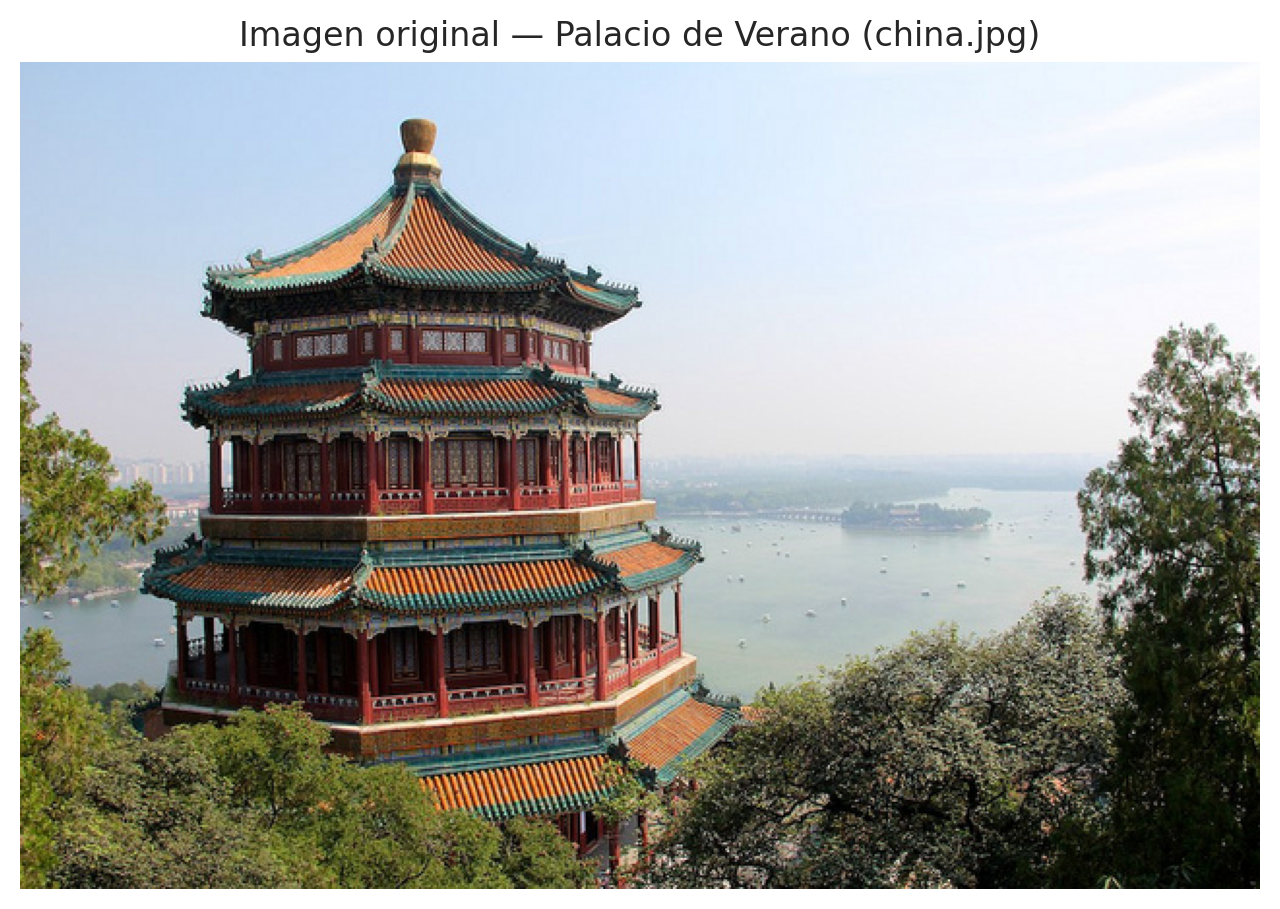

Forma original : (427, 640, 3)
Matriz de píxeles: (273280, 3)


In [ ]:
from sklearn.datasets import load_sample_image

# Cargar la imagen del Palacio de Verano
china = load_sample_image("china.jpg")

print(f"Tipo de objeto : {type(china)}")
print(f"Forma (shape)  : {china.shape}")
print(f"Tipo de dato   : {china.dtype}")
print(f"Valor mín/máx  : {china.min()} / {china.max()}")
print(f"Nº de píxeles  : {china.shape[0] * china.shape[1]:,}")

plt.figure(figsize=(8, 6))
plt.imshow(china)
plt.title('Imagen original — Palacio de Verano (china.jpg)')
plt.axis('off')
plt.show()

# Convertir a float en rango [0, 1]
china = np.array(china, dtype=np.float64) / 255

# Guardar la forma original y aplanar a una matriz de píxeles
w, h, d = original_shape = tuple(china.shape)
assert d == 3
image_array = np.reshape(china, (w * h, d))

print(f"Forma original : {original_shape}")
print(f"Matriz de píxeles: {image_array.shape}")

# ⭐ Google Reviews — Valoraciones de atracciones turísticas

## 1. Introducción

Este conjunto de datos recoge las **valoraciones de usuarios reales de Google** sobre atracciones turísticas de **toda Europa**, agrupadas en **24 categorías** (iglesias, playas, museos, restaurantes, hoteles, etc.). Las puntuaciones de Google van de **1 a 5**, y para cada usuario se ha calculado su **valoración media por categoría**. El resultado es una "huella" o perfil de preferencias de cada turista.

A diferencia de los problemas de clasificación, aquí **no hay variable respuesta ni etiquetas**: se trata de un problema de **aprendizaje no supervisado (agrupación / clustering)**. El objetivo es **agrupar a los usuarios** según la similitud de sus perfiles de valoración, para descubrir **segmentos de turistas** con intereses parecidos (por ejemplo, amantes de la cultura, del ocio nocturno, de la playa, etc.). Este tipo de análisis es muy útil en el dominio turístico para **recomendación personalizada** y **segmentación de mercado**.

El conjunto procede del **UCI Machine Learning Repository** (*Travel Review Ratings*), recopilado por Renjith, Sreekumar y Jathavedan (2018).

## 2. Estructura de los datos

El conjunto tiene **5.456 registros** (usuarios) y **24 variables** de valoración (más la columna identificadora `User`). **Sin valores perdidos** (en la versión del curso). Todas las valoraciones son numéricas continuas en el rango **[0, 5]**.

### 🆔 Identificador

| Columna | Tipo | Descripción |
|---|---|---|
| `User` | Texto | Identificador único del usuario (p. ej. `"User 1"`). **Debe eliminarse antes de agrupar.** |

### 🗺️ Variables de valoración (correspondencia de categorías)

| Columna CSV | Categoría | Columna CSV | Categoría |
|---|---|---|---|
| `Category 1` | Iglesias | `Category 13` | Hoteles / alojamientos |
| `Category 2` | Complejos turísticos | `Category 14` | Zumerías |
| `Category 3` | Playas | `Category 15` | Galerías de arte |
| `Category 4` | Parques | `Category 16` | Discotecas |
| `Category 5` | Teatros | `Category 17` | Piscinas |
| `Category 6` | Museos | `Category 18` | Gimnasios |
| `Category 7` | Centros comerciales | `Category 19` | Panaderías |
| `Category 8` | Zoológicos | `Category 20` | Belleza y spas |
| `Category 9` | Restaurantes | `Category 21` | Cafeterías |
| `Category 10` | Bares | `Category 22` | Miradores |
| `Category 11` | Servicios locales | `Category 23` | Monumentos |
| `Category 12` | Hamburgueserías / pizzerías | `Category 24` | Jardines |

> Todas son **valoraciones medias en [0, 5]**: un valor alto indica que el usuario tiende a valorar bien (o frecuenta) esa categoría; un **0** indica ausencia de valoraciones en ella.

### 🎯 Planteamiento del problema

| Aspecto | Valor |
|---|---|
| Tipo de aprendizaje | No supervisado |
| Tipo de problema | Agrupación (*clustering*) |
| Variable respuesta | **Ninguna** (no hay etiquetas) |
| Algoritmo de referencia | K-Means (y otros de particionamiento) |
| Aplicación típica | Segmentación de perfiles de turistas / recomendación |

## Referencias

- **Artículo original del dataset:**
  Renjith, S., Sreekumar, A., & Jathavedan, M. (2018). Evaluation of Partitioning Clustering Algorithms for Processing Social Media Data in Tourism Domain. *2018 IEEE Recent Advances in Intelligent Computational Systems (RAICS)*, 127–131. IEEE.
  [https://doi.org/10.1109/RAICS.2018.8635080](https://doi.org/10.1109/RAICS.2018.8635080)

- **Repositorio UCI Machine Learning (CC BY 4.0):**
  Renjith, S. (2018). *Travel Review Ratings* [Dataset]. UCI Machine Learning Repository.
  [https://archive.ics.uci.edu/dataset/485/travel+review+ratings](https://archive.ics.uci.edu/dataset/485/travel+review+ratings)

- **Conjunto de datos en Kaggle:**
  Travel Review Ratings.
  [https://www.kaggle.com/datasets/wirachleelakiatiwong/travel-review-rating-dataset](https://www.kaggle.com/datasets/wirachleelakiatiwong/travel-review-rating-dataset)

## Carga de datos


In [ ]:
url = "https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/google_review_ratings.csv"
reviews = pd.read_csv(url)

# 🛒 Sales — Ventas semanales de productos

## 1. Introducción

Este conjunto de datos recoge las **cantidades compradas semanalmente** de un catálogo de productos a lo largo de **un año completo (52 semanas)**. Cada producto está identificado por un código y, para cada una de las 52 semanas, se registra cuántas unidades se compraron. Las semanas se nombran como **`W0`, `W1`, …, `W51`** (de *week*).

La particularidad de este dataset es que **cada producto es, en realidad, una serie temporal**: su secuencia de ventas a lo largo de las 52 semanas describe un patrón (estacional, plano, creciente, decreciente, con picos puntuales…). El objetivo es de **aprendizaje no supervisado (agrupación / clustering)**: **agrupar los productos según la forma de su patrón de ventas semanal**. Por eso se habla de **clustering de series temporales**, una alternativa al *market basket analysis* clásico propuesta por Tan y Lau (2014): en lugar de analizar qué productos se compran juntos, se agrupan productos cuya **evolución temporal de demanda** es parecida, lo que es muy útil para gestión de inventario, previsión y planificación de promociones.

## 2. Estructura de los datos

El conjunto tiene **811 registros** (productos) y **52 variables** semanales (más la columna identificadora `Product_Code`). Todos los atributos son **numéricos enteros** (unidades compradas) y **no hay valores perdidos**.

### 🆔 Identificador

| Columna | Tipo | Descripción |
|---|---|---|
| `Product_Code` | Texto | Código único del producto (p. ej. `"P1"`). **Debe eliminarse antes de agrupar.** |

### 📈 Variables de ventas semanales

| Columnas | Tipo | Descripción |
|---|---|---|
| `W0`, `W1`, …, `W51` | Numérico entero (≥ 0) | Cantidad de unidades del producto compradas en cada una de las 52 semanas del año. En conjunto forman la **serie temporal de demanda** de cada producto. |

### 🎯 Planteamiento del problema

| Aspecto | Valor |
|---|---|
| Tipo de aprendizaje | No supervisado |
| Tipo de problema | Agrupación de series temporales (*time series clustering*) |
| Variable respuesta | **Ninguna** (no hay etiquetas) |
| Algoritmo de referencia | K-Means (sobre series normalizadas) |
| Aplicación típica | Segmentación de productos por patrón de demanda / gestión de inventario |

## Referencias

- **Artículo original (clustering de series temporales para *market basket analysis*):**
  Tan, S. C., & Lau, J. P. S. (2014). Time series clustering: A superior alternative for market basket analysis. *Proceedings of the First International Conference on Advanced Data and Information Engineering (DaEng-2013)*, 241–248. Springer.
  [https://doi.org/10.1007/978-981-4585-18-7_28](https://doi.org/10.1007/978-981-4585-18-7_28)

- **Repositorio UCI Machine Learning:**
  Sales_Transactions_Dataset_Weekly. UCI Machine Learning Repository.
  [https://archive.ics.uci.edu/dataset/396/sales+transactions+dataset+weekly](https://archive.ics.uci.edu/dataset/396/sales+transactions+dataset+weekly)

- **Conjunto de datos en Kaggle:**
  Sales Transactions Weekly.
  [https://www.kaggle.com/datasets/crawford/weekly-sales-transactions](https://www.kaggle.com/datasets/crawford/weekly-sales-transactions)

- **Librería para clustering de series temporales:**
  Tavenard, R. et al. *tslearn: A Machine Learning Toolkit for Time Series Data*.
  [https://tslearn.readthedocs.io](https://tslearn.readthedocs.io)

## Carga de datos


In [ ]:
url = "https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/Sales_Transactions_Weekly.csv"
sales = pd.read_csv(url)

# 💧 Water Potability

## Introducción

El acceso a **agua potable** es uno de los derechos humanos más básicos y un factor determinante para la salud pública. Este conjunto de datos tiene por objetivo **estudiar la potabilidad del agua** a partir de varias de sus **propiedades físico-químicas** (pH, dureza, sulfatos, cloraminas, etc.). El interés es claro: en muchas regiones, invertir en abastecimiento y saneamiento produce un beneficio económico neto, porque la reducción de los efectos adversos para la salud y de los costes sanitarios supera el coste de las intervenciones.

El problema es de **clasificación binaria**: predecir si una muestra de agua es **potable (1)** o **no potable (0)** a partir de sus 9 propiedades químicas medidas.

## 2. Características registradas

El conjunto tiene **3.276 registros** y **10 variables**: 9 propiedades físico-químicas (predictoras, numéricas continuas) y la variable objetivo. Con **valores perdidos** en tres columnas.

### 🎯 Variable objetivo

| Variable | Tipo | Descripción |
|---|---|---|
| `Potability` | Categórica binaria | Indica si el agua es segura para el consumo humano: **1** = potable · **0** = no potable. **Variable respuesta.** |

### 🧪 Variables predictoras (propiedades físico-químicas)

| Característica | Unidad | Descripción | Nulos |
|---|---|---|---|
| `ph` | 0–14 | Valor del pH (acidez/alcalinidad). La OMS recomienda un rango de **6,5–8,5** para agua de consumo | **491** |
| `Hardness` | mg/L | Dureza: capacidad del agua de precipitar el jabón, causada por calcio y magnesio | 0 |
| `Solids` | ppm | Sólidos disueltos totales (*Total Dissolved Solids*) | 0 |
| `Chloramines` | ppm | Cantidad de cloraminas (desinfectante habitual del agua tratada) | 0 |
| `Sulfate` | mg/L | Cantidad de sulfatos disueltos | **781** |
| `Conductivity` | μS/cm | Conductividad eléctrica del agua (relacionada con los iones disueltos) | 0 |
| `Organic_carbon` | ppm | Cantidad de carbono orgánico total | 0 |
| `Trihalomethanes` | μg/L | Trihalometanos: subproductos de la cloración (la OMS sitúa el límite en torno a **80 μg/L**) | **162** |
| `Turbidity` | NTU | Turbidez: medida de la cantidad de materia en suspensión (emisión/dispersión de luz) | 0 |

## Referencias

- **Conjunto de datos en Kaggle:**
  Kadiwal, A. *Water Quality / Water Potability*. Kaggle.
  [https://www.kaggle.com/datasets/adityakadiwal/water-potability](https://www.kaggle.com/datasets/adityakadiwal/water-potability)

- **Guías de calidad del agua para consumo humano:**
  World Health Organization (2022). *Guidelines for Drinking-water Quality* (4ª ed., con la primera adenda).
  [https://www.who.int/publications/i/item/9789240045064](https://www.who.int/publications/i/item/9789240045064)

- **Documentación de imputación de valores perdidos en scikit-learn:**
  *Imputation of missing values*.
  [https://scikit-learn.org/stable/modules/impute.html](https://scikit-learn.org/stable/modules/impute.html)

## Carga de datos


In [ ]:
url = "https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/water_potability.csv"
water = pd.read_csv(url)

# 🛍️ Amazon Beauty — Reseñas de productos

## 1. Introducción

Este conjunto de datos recoge las **valoraciones de productos de belleza de Amazon**: más de **2 millones de reseñas** que abarcan desde **mayo de 1996 hasta julio de 2014**. Cada registro indica qué **usuario** valoró qué **producto**, con qué **puntuación** (de 1 a 5) y **cuándo**. Es la versión *"ratings only"* (solo valoraciones, sin texto de reseña) de la categoría *Beauty* del conocido corpus de reseñas de Amazon recopilado por J. McAuley.

El problema que se plantea es de **sistema de recomendación**: aprovechar el histórico de valoraciones para **predecir cómo valoraría un usuario un producto que aún no ha probado** y, a partir de ahí, **recomendarle los productos que más le podrían gustar**. Es un tipo de problema distinto a la clasificación o la agrupación: aunque la variable `Rating` es numérica, el objetivo no es una regresión clásica, sino modelar las **interacciones usuario–producto**.

## Características registradas

El conjunto tiene **2.023.070 registros** y solo **4 variables**, **sin valores perdidos**.

### 🎯 Variable objetivo

| Variable | Tipo | Descripción |
|---|---|---|
| `Rating` | Numérica entera (1–5) | Calificación que el usuario dio al producto: entero del **1** (mínima satisfacción) al **5** (máxima). **Variable a predecir.** |

### 🔑 Variables de interacción

| Variable | Tipo | Descripción |
|---|---|---|
| `UserId` | Texto | Identificador único del usuario/cliente (p. ej. `A3CIUOJXQ5VDQ2`) |
| `ProductId` | Texto | Identificador único del producto en Amazon (ASIN, p. ej. `B00LRFFY6Q`) |
| `Timestamp` | Entero (Unix) | Momento de la valoración, en segundos desde 1970. Se convierte a fecha con `pd.to_datetime(..., unit='s')` |

### 🎯 Planteamiento del problema

| Aspecto | Valor |
|---|---|
| Tipo de problema | Sistema de recomendación |
| Paradigma habitual | Filtrado colaborativo (basado en las valoraciones) |
| Tipo de *feedback* | Explícito (valoraciones 1–5) |
| Formulaciones | (a) **Predicción de la valoración** → métricas RMSE/MAE · (b) **Recomendación top-N** → precisión@k, recall@k, MAP, NDCG |

## Referencias

- **Conjunto de datos en Kaggle:**
  *Amazon - Ratings (Beauty Products)*. Kaggle.
  [https://www.kaggle.com/datasets/skillsmuggler/amazon-ratings](https://www.kaggle.com/datasets/skillsmuggler/amazon-ratings)

- **Artículos originales del corpus de reseñas de Amazon (citas recomendadas por los autores):**
  McAuley, J., Targett, C., Shi, Q., & van den Hengel, A. (2015). Image-based recommendations on styles and substitutes. *Proceedings of the 38th International ACM SIGIR Conference (SIGIR '15)*, 43–52.

  He, R., & McAuley, J. (2016). Ups and Downs: Modeling the Visual Evolution of Fashion Trends with One-Class Collaborative Filtering. *Proceedings of the 25th International Conference on World Wide Web (WWW '16)*, 507–517.

- **Página del corpus original (J. McAuley, UCSD):**
  *Amazon review data*.
  [https://jmcauley.ucsd.edu/data/amazon/](https://jmcauley.ucsd.edu/data/amazon/)

- **Librería para sistemas de recomendación:**
  Hug, N. (2020). *Surprise: A Python library for recommender systems*.
  [https://surpriselib.com](https://surpriselib.com)


## Carga de datos

In [ ]:
# Paso 1: descargar el dataset
path = kagglehub.dataset_download("skillsmuggler/amazon-ratings")
print("Ruta al dataset:", path)

# Paso 2: Listar los archivos descargados
archivos = os.listdir(path)
print("Archivos disponibles:", archivos)

# Paso 3: Cargar el CSV principal (ajusta el nombre si difiere)
ratings = pd.read_csv(os.path.join(path, archivos[0]))
ratings.head()

100%|██████████| 28.8M/28.8M [00:02<00:00, 12.3MB/s]

Extracting files...


Ruta al dataset: /root/.cache/kagglehub/datasets/skillsmuggler/amazon-ratings/versions/1
Archivos disponibles: ['ratings_Beauty.csv']


,UserId,ProductId,Rating,Timestamp
0,A39HTATAQ9V7YF,0205616461,5.0,1369699200
1,A3JM6GV9MNOF9X,0558925278,3.0,1355443200
2,A1Z513UWSAAO0F,0558925278,5.0,1404691200
3,A1WMRR494NWEWV,0733001998,4.0,1382572800
4,A3IAAVS479H7M7,0737104473,1.0,1274227200


# 🏥 Healthcare Fraud Detection Dataset


## 1. Introducción

El fraude en el sector sanitario supone uno de los mayores desafíos financieros para las aseguradoras y los sistemas de salud a nivel mundial, con pérdidas estimadas que oscilan entre el **3% y el 10% del gasto sanitario total**. La detección de reclamaciones fraudulentas es especialmente compleja porque el comportamiento fraudulento imita con frecuencia la actividad médica legítima, aprovechando ineficiencias sutiles en los sistemas de facturación.

Este conjunto de datos contiene **10.000 reclamaciones de seguros médicos** diseñadas para replicar patrones reales de facturación y fraude. Incluye una combinación de características relativas al paciente, al proveedor sanitario y a la información financiera, adecuadas para **tareas de clasificación**.

Entre las principales motivaciones para trabajar con este tipo de datos destacan:

- Mejorar los sistemas de detección de fraude mediante enfoques basados en datos
- Reducir las pérdidas económicas y las fugas en las reclamaciones
- Optimizar los procesos de auditoría y cumplimiento normativo
- Asignar los recursos de investigación de manera más eficiente
- Fortalecer la confianza en los sistemas sanitarios

> **Nota sobre el desequilibrio de clases:** la tasa de fraude en el dataset es aproximadamente del **8%**, lo que refleja el desequilibrio real del problema.

## 2. Características registradas

El dataset está organizado en seis bloques temáticos:

### 📋 Información sobre la reclamación y datos financieros

| Característica | Tipo | Descripción |
|---|---|---|
| `claim_amount` | Numérico | Importe total reclamado por el proveedor |
| `approved_amount` | Numérico | Importe aprobado por la aseguradora |
| `claim_status` | Categórico | Estado de la reclamación: `approved`, `rejected`, `pending` |
| `insurance_type` | Categórico | Tipo de seguro: `private`, `Medicare`, `Medicaid`, `self-pay` |

### 👤 Información del paciente

| Característica | Tipo | Descripción |
|---|---|---|
| `patient_age` | Numérico | Edad del paciente en años |
| `patient_gender` | Categórico | Género del paciente |
| `state` | Categórico | Estado geográfico del paciente (nivel de estado en EE.UU.) |
| `chronic_condition` | Binario | Indicador de enfermedad crónica (1 = sí, 0 = no) |
| `prior_visits_12m` | Numérico | Número de visitas previas en los últimos 12 meses |

### 🏢 Información del proveedor sanitario

| Característica | Tipo | Descripción |
|---|---|---|
| `provider_id` | Identificador | Identificador único del proveedor sanitario |
| `provider_specialty` | Categórico | Especialidad médica: `cardiology`, `orthopedics`, `general practice`, entre otras |
| `monthly_claim_volume` | Numérico | Volumen mensual de reclamaciones del proveedor |

### 🩺 Codificación médica

| Característica | Tipo | Descripción |
|---|---|---|
| `diagnosis_code` | Categórico | Código de diagnóstico según el estándar **ICD-10** |
| `procedure_code` | Categórico | Código de procedimiento según el estándar **CPT** |

### 📅 Características temporales

| Característica | Tipo | Descripción |
|---|---|---|
| `claim_submission_date` | Fecha | Fecha de presentación de la reclamación |
| `days_to_submission` | Numérico | Días transcurridos entre la prestación del servicio y la presentación de la reclamación |

### 🏨 Características adicionales

| Característica | Tipo | Descripción |
|---|---|---|
| `length_of_stay` | Numérico | Duración de la estancia hospitalaria (solo para casos de hospitalización) |
| `visit_type` | Categórico | Tipo de visita: `outpatient`, `inpatient`, `emergency` |

### 🎯 Variable objetivo

| Característica | Tipo | Descripción |
|---|---|---|
| `Is_Fraud` | Binario | **0** = reclamación legítima · **1** = reclamación fraudulenta |

## 4. Referencias

- **Dataset en Kaggle:**
  Abbás, N. (2024). *Healthcare Fraud Detection Dataset*. Kaggle.
  [https://www.kaggle.com/datasets/nudratabbas/healthcare-fraud-detection-dataset](https://www.kaggle.com/datasets/nudratabbas/healthcare-fraud-detection-dataset)

- **Artículo de referencia sobre fraude sanitario con ML:**
  Hamid, Z., Khalique, F., Mahmood, S., Daud, A., Bukhari, A., & Alshemaimri, B. (2024). Healthcare insurance fraud detection using data mining. *BMC Medical Informatics and Decision Making*, 24, 113.
  [https://doi.org/10.1186/s12911-024-02512-4](https://doi.org/10.1186/s12911-024-02512-4)

- **Clasificación de fraude con aprendizaje automático (IEEE):**
  Classification of Health Insurance Fraud Risk with Machine Learning. *IEEE Xplore*, 2024.
  [https://ieeexplore.ieee.org/document/10699052/](https://ieeexplore.ieee.org/document/10699052/)

- **Estudio con deep learning sobre Medicare fraud:**
  Improving Medicare Fraud Detection Accuracy in Deep Learning by Exploring Feature Selection and Data Sampling Techniques. *medRxiv*, 2026.
  [https://doi.org/10.64898/2026.03.18.26348763v1](https://doi.org/10.64898/2026.03.18.26348763v1)

- **Codificación ICD-10 (diagnósticos):**
  World Health Organization. *International Classification of Diseases, 10th Revision (ICD-10)*.
  [https://www.who.int/standards/classifications/classification-of-diseases](https://www.who.int/standards/classifications/classification-of-diseases)

- **Codificación CPT (procedimientos):**
  American Medical Association. *Current Procedural Terminology (CPT)*.
  [https://www.ama-assn.org/practice-management/cpt](https://www.ama-assn.org/practice-management/cpt)

## 4. Carga de los datos en Google Colab


In [ ]:
# Paso 1: descargar el dataset
path = kagglehub.dataset_download("nudratabbas/healthcare-fraud-detection-dataset")
print("Ruta al dataset:", path)

# Paso 2: Listar los archivos descargados
archivos = os.listdir(path)
print("Archivos disponibles:", archivos)

# Paso 3: Cargar el CSV principal (ajusta el nombre si difiere)
df = pd.read_csv(os.path.join(path, archivos[0]))
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head()

100%|██████████| 281k/281k [00:00<00:00, 432kB/s]

Extracting files...
Ruta al dataset: /root/.cache/kagglehub/datasets/nudratabbas/healthcare-fraud-detection-dataset/versions/1
Archivos disponibles: ['healthcare_fraud_detection.csv']
Dimensiones: 10,000 filas × 20 columnas


,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0


# 🩺 Diabetes Health Indicators Dataset (BRFSS 2015)

## 1. Introducción

La diabetes es una de las enfermedades crónicas más prevalentes en los Estados Unidos. Las personas afectadas pierden la capacidad de regular eficazmente los niveles de glucosa en sangre, lo que puede derivar en una reducción significativa de la calidad y la esperanza de vida. Complicaciones como enfermedades cardíacas, pérdida de visión, amputación de extremidades inferiores y enfermedad renal están asociadas con niveles crónicamente elevados de glucosa en sangre.

El impacto de esta enfermedad es de gran escala. Según los datos del **Centers for Disease Control and Prevention (CDC)**, a fecha de 2018:

- **34,2 millones** de estadounidenses tienen diabetes diagnosticada
- **88 millones** presentan prediabetes
- 1 de cada 5 diabéticos y 8 de cada 10 prediabéticos desconocen su situación de riesgo
- El coste económico de la diabetes diagnosticada asciende a aproximadamente **327.000 millones de dólares** anuales, superando los 400.000 millones si se incluyen los casos no diagnosticados y la prediabetes

La detección temprana permite realizar cambios en el estilo de vida y aplicar tratamientos más efectivos, lo que convierte a los modelos predictivos de riesgo de diabetes en herramientas valiosas para la salud pública.

### Fuente de los datos: BRFSS

Los datos proceden del **Behavioral Risk Factor Surveillance System (BRFSS)**, una encuesta telefónica sobre salud que el CDC realiza anualmente desde 1984. Cada año recoge respuestas de más de **400.000 estadounidenses** sobre comportamientos de riesgo para la salud, enfermedades crónicas y uso de servicios preventivos.

Este dataset es una versión limpia de las respuestas al BRFSS del año **2015**, publicada en Kaggle por Alex Teboul. Contiene **253.680 registros** y **21 variables predictoras** más la variable objetivo.

## 2. Características registradas

El dataset contiene **22 variables** en total: 21 características predictoras y 1 variable objetivo.

### 🎯 Variable objetivo

| Característica | Tipo | Descripción |
|---|---|---|
| `Diabetes_012` | Ordinal (0, 1, 2) | **0** = sin diabetes (ni durante el embarazo) · **1** = prediabetes · **2** = diabetes |

### 🫀 Condiciones de salud cardiovascular y metabólica

| Característica | Tipo | Descripción |
|---|---|---|
| `HighBP` | Binario (0/1) | Presión arterial elevada: **0** = no · **1** = sí |
| `HighChol` | Binario (0/1) | Colesterol elevado: **0** = no · **1** = sí |
| `CholCheck` | Binario (0/1) | Control de colesterol en los últimos 5 años: **0** = no · **1** = sí |
| `BMI` | Numérico continuo | Índice de masa corporal (*Body Mass Index*) |
| `Stroke` | Binario (0/1) | Diagnóstico previo de ictus: **0** = no · **1** = sí |
| `HeartDiseaseorAttack` | Binario (0/1) | Cardiopatía coronaria (CHD) o infarto de miocardio (MI): **0** = no · **1** = sí |

### 🏃 Hábitos de vida y comportamientos de salud

| Característica | Tipo | Descripción |
|---|---|---|
| `Smoker` | Binario (0/1) | ¿Ha fumado al menos 100 cigarrillos a lo largo de su vida? [5 paquetes = 100 cigarrillos] **0** = no · **1** = sí |
| `PhysActivity` | Binario (0/1) | Actividad física en los últimos 30 días (sin incluir el trabajo): **0** = no · **1** = sí |
| `Fruits` | Binario (0/1) | Consumo de fruta 1 o más veces al día: **0** = no · **1** = sí |
| `Veggies` | Binario (0/1) | Consumo de verduras 1 o más veces al día: **0** = no · **1** = sí |
| `HvyAlcoholConsump` | Binario (0/1) | Consumo elevado de alcohol (hombres: más de 14 bebidas/semana; mujeres: más de 7 bebidas/semana): **0** = no · **1** = sí |

### 🏥 Acceso al sistema sanitario

| Característica | Tipo | Descripción |
|---|---|---|
| `AnyHealthcare` | Binario (0/1) | Dispone de algún tipo de cobertura sanitaria (seguro, HMO, etc.): **0** = no · **1** = sí |
| `NoDocbcCost` | Binario (0/1) | En los últimos 12 meses, ¿hubo algún momento en que necesitara ver a un médico pero no pudo por el coste?: **0** = no · **1** = sí |

### 🧠 Estado de salud general y funcional

| Característica | Tipo | Descripción |
|---|---|---|
| `GenHlth` | Ordinal (1–5) | Valoración del estado de salud general: **1** = excelente · **2** = muy buena · **3** = buena · **4** = regular · **5** = mala |
| `MentHlth` | Numérico (1–30) | Número de días en los últimos 30 en que la salud mental no fue buena (incluye estrés, depresión y problemas emocionales) |
| `PhysHlth` | Numérico (1–30) | Número de días en los últimos 30 en que la salud física no fue buena (incluye enfermedad e lesión) |
| `DiffWalk` | Binario (0/1) | Dificultad seria para caminar o subir escaleras: **0** = no · **1** = sí |

### 👤 Variables sociodemográficas

| Característica | Tipo | Descripción |
|---|---|---|
| `Sex` | Binario (0/1) | **0** = mujer · **1** = hombre |
| `Education` | Ordinal (1–6) | Nivel educativo: **1** = sin estudios o solo educación infantil · **2** = educación primaria (cursos 1–8) · **3** = secundaria incompleta (cursos 9–11) · **4** = bachillerato o equivalente (GED) · **5** = universidad sin título (1–3 años) · **6** = titulado universitario (4 años o más) |
| `Income` | Ordinal (1–8) | Nivel de ingresos: **1** = menos de 10.000 $ · **5** = menos de 35.000 $ · **8** = 75.000 $ o más |


## 3. Referencias

- **Dataset en Kaggle:**
  Teboul, A. (2022). *Diabetes Health Indicators Dataset*. Kaggle.
  [https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset](https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset)

- **Dataset en UCI Machine Learning Repository:**
  CDC. *CDC Diabetes Health Indicators*. UCI Machine Learning Repository, 2023.
  [https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators](https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators)

- **Fuente original de los datos — BRFSS:**
  Centers for Disease Control and Prevention (CDC). *Behavioral Risk Factor Surveillance System (BRFSS) 2015*.
  [https://www.cdc.gov/brfss/index.html](https://www.cdc.gov/brfss/index.html)

- **Artículo de referencia con ML sobre este dataset:**
  Predictions of diabetes through machine learning models based on the health indicators dataset. *ResearchGate*, 2024.
  [https://www.researchgate.net/publication/377829779](https://www.researchgate.net/publication/377829779)

- **Detección temprana de diabetes con ML — PubMed Central:**
  Detecting High-Risk Factors and Early Diagnosis of Diabetes Using Machine Learning Methods. *PMC*, 2022.
  [https://pmc.ncbi.nlm.nih.gov/articles/PMC9536939/](https://pmc.ncbi.nlm.nih.gov/articles/PMC9536939/)

- **Análisis con IA de los determinantes de riesgo de diabetes — PubMed Central:**
  AI-driven analysis of diabetes risk determinants in U.S. adults. *PMC*, 2025.
  [https://www.ncbi.nlm.nih.gov/pmc/articles/PMC12407459/](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC12407459/)

- **Predicción con modelos ensemble y selección de características:**
  An Improved Ensemble-Based Machine Learning Model with Feature Optimization for Early Diabetes Prediction. *arXiv*, 2024.
  [https://arxiv.org/pdf/2512.02023](https://arxiv.org/pdf/2512.02023)

- **Predicción con XAI (SHAP y LIME) sobre BRFSS:**
  Interactive Diabetes Risk Prediction Using Explainable Machine Learning: A Dash-Based Approach with SHAP, LIME, and Comorbidity Insights. *arXiv*, 2025.
  [https://arxiv.org/pdf/2505.05683](https://arxiv.org/pdf/2505.05683)


## 4. Carga de los datos en Google Colab

El dataset está disponible en Kaggle en tres versiones:

| Archivo | Descripción |
|---|---|
| `diabetes_012_health_indicators_BRFSS2015.csv` | Dataset completo con 3 clases en `Diabetes_012` (253.680 registros) |
| `diabetes_binary_health_indicators_BRFSS2015.csv` | Variable objetivo recodificada como binaria (253.680 registros, desequilibrado) |
| `diabetes_binary_5050split_health_indicators_BRFSS2015.csv` | Subconjunto equilibrado al 50/50 para clasificación binaria (70.692 registros) |

Descarga directa desde Kaggle con `kagglehub` para el fichero con tes clases:

In [ ]:
# Paso 1: descargar el dataset
path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")
print("Ruta al dataset:", path)

# Paso 2: listar los archivos disponibles
archivos = os.listdir(path)
print("Archivos disponibles:")
for f in archivos:
    print(f"  · {f}")

# Paso 3: Cargar el dataset completo con 3 clases (multiclase)
df = pd.read_csv(os.path.join(path, "diabetes_012_health_indicators_BRFSS2015.csv"))
print(f"Dataset multiclase: {df.shape[0]:,} filas × {df.shape[1]} columnas")

100%|██████████| 6.03M/6.03M [00:01<00:00, 4.28MB/s]

Extracting files...


Ruta al dataset: /root/.cache/kagglehub/datasets/alexteboul/diabetes-health-indicators-dataset/versions/1
Archivos disponibles:
  · diabetes_binary_5050split_health_indicators_BRFSS2015.csv
  · diabetes_binary_health_indicators_BRFSS2015.csv
  · diabetes_012_health_indicators_BRFSS2015.csv
Dataset multiclase: 253,680 filas × 22 columnas


# 🦠 COVID-19 Dataset — México (Gobierno Federal Mexicano)

## 1. Introducción

La COVID-19 es una enfermedad infecciosa causada por el coronavirus SARS-CoV-2. La mayoría de las personas infectadas experimenta un cuadro clínico leve o moderado y se recuperan sin necesidad de atención especializada. Sin embargo, las personas mayores y aquellas con enfermedades subyacentes como cardiopatías, diabetes, enfermedades respiratorias crónicas o cáncer presentan un riesgo significativamente mayor de desarrollar un cuadro grave.

Uno de los principales retos durante la pandemia fue la **escasez de recursos médicos** y la necesidad de distribuirlos de forma eficiente. Poder predecir qué tipo de atención requerirá un paciente en el momento de dar positivo —o incluso antes— permite a las autoridades sanitarias planificar y asignar recursos de manera más efectiva, mejorando la capacidad de respuesta del sistema.

El objetivo central del uso de este dataset es construir un modelo de aprendizaje automático que, a partir del estado clínico actual, los síntomas y el historial médico de un paciente con COVID-19, prediga si se encuentra en situación de **alto riesgo** (incluida la probabilidad de fallecimiento o necesidad de UCI e intubación).

### Fuente de los datos

El dataset fue proporcionado por el **Gobierno Federal de México** a través de la plataforma de datos abiertos [datos.gob.mx](https://datos.gob.mx/busca/dataset/informacion-referente-a-casos-covid-19-en-mexico), que publica periódicamente información anónima sobre casos COVID-19 en el país. La versión disponible en Kaggle fue preparada por Meir Nizri a partir de esa fuente oficial.

El dataset contiene información de **1.048.576 pacientes** con **21 características** distintas. Se trata de uno de los conjuntos de datos públicos más completos sobre COVID-19 a nivel nacional, con información clínica, demográfica y de resultado de cada caso.

> **Nota sobre valores faltantes:** los valores **97** y **99** indican datos ausentes en las variables codificadas. La fecha **9999-99-99** en `date_died` indica que el paciente no falleció. Es necesario tratar estos valores antes de entrenar cualquier modelo.

## 2. Características registradas

El dataset contiene **21 variables** organizadas en cuatro bloques: información demográfica, resultado clínico, condiciones médicas preexistentes y gestión hospitalaria.

### 👤 Información demográfica y clínica básica

| Característica | Tipo | Descripción |
|---|---|---|
| `sex` | Binario (1/2) | Sexo del paciente: **1** = mujer · **2** = hombre |
| `age` | Numérico | Edad del paciente en años |
| `classification` | Ordinal (1–7+) | Resultado de la prueba COVID-19: **1–3** = diagnóstico positivo con diferente grado de severidad · **4 o más** = no portador o resultado inconcluso |
| `patient_type` | Binario (1/2) | Tipo de atención recibida: **1** = alta domiciliaria · **2** = hospitalización |

### 🏥 Gestión hospitalaria y resultado clínico

| Característica | Tipo | Descripción |
|---|---|---|
| `intubed` | Binario (1/2) | El paciente fue conectado a ventilación mecánica: **1** = sí · **2** = no |
| `icu` | Binario (1/2) | El paciente ingresó en una Unidad de Cuidados Intensivos (UCI): **1** = sí · **2** = no |
| `date_died` | Fecha / texto | Fecha de fallecimiento del paciente · **9999-99-99** si el paciente no falleció |
| `usmr` | Categórico | Indica si el paciente fue atendido en una unidad médica de primer, segundo o tercer nivel |
| `medical_unit` | Categórico | Tipo de institución del Sistema Nacional de Salud que proporcionó la atención |

### 🫁 Condición clínica al ingreso

| Característica | Tipo | Descripción |
|---|---|---|
| `pneumonia` | Binario (1/2) | Inflamación de los sacos aéreos (neumonía) al momento del ingreso: **1** = sí · **2** = no |
| `pregnancy` | Binario (1/2) | La paciente está embarazada: **1** = sí · **2** = no |

### 🩺 Enfermedades preexistentes (comorbilidades)

| Característica | Tipo | Descripción |
|---|---|---|
| `diabetes` | Binario (1/2) | Diagnóstico previo de diabetes: **1** = sí · **2** = no |
| `copd` | Binario (1/2) | Enfermedad Pulmonar Obstructiva Crónica (EPOC): **1** = sí · **2** = no |
| `asthma` | Binario (1/2) | Diagnóstico previo de asma: **1** = sí · **2** = no |
| `inmsupr` | Binario (1/2) | El paciente está inmunosuprimido: **1** = sí · **2** = no |
| `hypertension` | Binario (1/2) | Diagnóstico previo de hipertensión arterial: **1** = sí · **2** = no |
| `cardiovascular` | Binario (1/2) | Enfermedad cardiovascular o de los vasos sanguíneos: **1** = sí · **2** = no |
| `renal_chronic` | Binario (1/2) | Enfermedad renal crónica: **1** = sí · **2** = no |
| `other_disease` | Binario (1/2) | Otras enfermedades no especificadas en las variables anteriores: **1** = sí · **2** = no |
| `obesity` | Binario (1/2) | El paciente presenta obesidad: **1** = sí · **2** = no |
| `tobacco` | Binario (1/2) | El paciente es consumidor habitual de tabaco: **1** = sí · **2** = no |

## 3. Referencias

- **Dataset en Kaggle:**
  Nizri, M. (2021). *COVID-19 Dataset*. Kaggle.
  [https://www.kaggle.com/datasets/meirnizri/covid19-dataset](https://www.kaggle.com/datasets/meirnizri/covid19-dataset)

- **Fuente oficial de los datos:**
  Gobierno Federal de México — Dirección General de Epidemiología. *Información referente a casos COVID-19 en México*.
  [https://datos.gob.mx/busca/dataset/informacion-referente-a-casos-covid-19-en-mexico](https://datos.gob.mx/busca/dataset/informacion-referente-a-casos-covid-19-en-mexico)

- **Identificación de pacientes de alto riesgo con ML (PMC):**
  Identification of high-risk COVID-19 patients using machine learning. *PMC*, 2021.
  [https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8452016/](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8452016/)

- **Análisis de mortalidad en México con ML — KNN, regresión logística, Random Forest y RNA:**
  Mortality Analysis of Patients with COVID-19 in Mexico Based on Risk Factors Applying Machine Learning Techniques. *PMC*, 2022.
  [https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9222115/](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9222115/)

- **Factores de riesgo de letalidad por sexo y grupo de edad con XGBoost:**
  Rojas-García, M. et al. (2023). Lethality risk markers by sex and age-group for COVID-19 in Mexico: a cross-sectional study based on machine learning approach. *BMC Infectious Diseases*.
  [https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9832420/](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9832420/)

- **Estudio de cohorte con 1,4 millones de pacientes y super learner (PMC):**
  Who is most at risk of dying if infected with SARS-CoV-2? A mortality risk factor analysis using machine learning of patients with COVID-19 over time. *PMC*, 2023.
  [https://www.ncbi.nlm.nih.gov/pmc/articles/PMC10533798/](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC10533798/)

- **Análisis comparativo México–Brasil con ML y AWS:**
  COVID-19 health analysis and prediction using machine learning algorithms for Mexico and Brazil patients. *ResearchGate*, 2022.
  [https://www.researchgate.net/publication/359747294](https://www.researchgate.net/publication/359747294)


## 4. Carga de los datos en Google Colab

In [ ]:
# Paso 1: descargar el dataset
path = kagglehub.dataset_download("meirnizri/covid19-dataset")
print("Ruta al dataset:", path)

# Paso 2: listar los archivos disponibles
archivos = os.listdir(path)
print("Archivos disponibles:")
for f in archivos:
    print(f"  · {f}")

# Paso 3: Cargar el dataset
df = pd.read_csv(os.path.join(path, archivos[0]))
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head()

100%|██████████| 4.66M/4.66M [00:01<00:00, 3.49MB/s]

Extracting files...


Ruta al dataset: /root/.cache/kagglehub/datasets/meirnizri/covid19-dataset/versions/1
Archivos disponibles:
  · Covid Data.csv
Dimensiones: 1,048,575 filas × 21 columnas


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,1,1,03/05/2020,97,1,65,2,2,...,2,2,1,2,2,2,2,2,3,97
1,2,1,2,1,03/06/2020,97,1,72,97,2,...,2,2,1,2,2,1,1,2,5,97
2,2,1,2,2,09/06/2020,1,2,55,97,1,...,2,2,2,2,2,2,2,2,3,2
3,2,1,1,1,12/06/2020,97,2,53,2,2,...,2,2,2,2,2,2,2,2,7,97
4,2,1,2,1,21/06/2020,97,2,68,97,1,...,2,2,1,2,2,2,2,2,3,97


# 🫘 Chronic Kidney Disease Dataset — UCI Machine Learning Repository

## 1. Introducción

La enfermedad renal crónica (ERC) es una afección médica progresiva que deteriora gradualmente la función de los riñones hasta comprometer su capacidad de filtrar los productos de desecho del organismo. Según la Organización Mundial de la Salud (OMS), en 2016 la ERC causó la muerte de **753 millones de personas** en todo el mundo. Si se diagnostica y trata en sus fases iniciales, la progresión hacia la insuficiencia renal puede prevenirse o ralentizarse significativamente, lo que convierte la detección temprana en un objetivo prioritario de salud pública.

Este dataset fue recogido durante un periodo de aproximadamente **dos meses** en un hospital de la India, y contiene información clínica y analítica de pacientes con y sin enfermedad renal crónica. Incluye **400 registros** y **24 características** de naturaleza mixta (11 numéricas y 14 nominales), junto con una variable objetivo binaria.

El objetivo principal del uso de este dataset es entrenar modelos de clasificación que, a partir de los valores clínicos y analíticos de un paciente, sean capaces de predecir si padece o no enfermedad renal crónica.

## 2. Características registradas

El dataset contiene **24 variables predictoras** y **1 variable objetivo**, organizadas en cuatro bloques: medidas demográficas, análisis de orina, análisis de sangre y estado clínico.

### 👤 Datos demográficos

| Característica | Tipo | Unidades | Descripción |
|---|---|---|---|
| `age` | Entero | años | Edad del paciente |
| `bp` | Entero | mm/Hg | Presión arterial (*blood pressure*) |

### 🔬 Análisis de orina

| Característica | Tipo | Unidades | Descripción |
|---|---|---|---|
| `sg` | Categórico | — | Gravedad específica de la orina (*specific gravity*): valores posibles 1.005, 1.010, 1.015, 1.020, 1.025 |
| `al` | Categórico | — | Albúmina en orina (*albumin*): escala 0–5 |
| `su` | Categórico | — | Azúcar en orina (*sugar*): escala 0–5 |
| `rbc` | Binario | — | Glóbulos rojos en orina (*red blood cells*): normal / anormal |
| `pc` | Binario | — | Células de pus en orina (*pus cell*): normal / anormal |
| `pcc` | Binario | — | Acúmulos de células de pus (*pus cell clumps*): presente / no presente |
| `ba` | Binario | — | Presencia de bacterias en orina (*bacteria*): presente / no presente |

### 🩸 Análisis de sangre

| Característica | Tipo | Unidades | Descripción |
|---|---|---|---|
| `bgr` | Entero | mgs/dl | Glucosa aleatoria en sangre (*blood glucose random*) |
| `bu` | Entero | mgs/dl | Urea en sangre (*blood urea*) |
| `sc` | Continuo | mgs/dl | Creatinina sérica (*serum creatinine*) — marcador principal de función renal |
| `sod` | Entero | mEq/L | Sodio en sangre (*sodium*) |
| `pot` | Continuo | mEq/L | Potasio en sangre (*potassium*) |
| `hemo` | Continuo | gms | Hemoglobina (*hemoglobin*) |
| `pcv` | Entero | — | Volumen celular compacto (*packed cell volume*) |
| `wbcc` | Entero | cells/cmm | Recuento de glóbulos blancos (*white blood cell count*) |
| `rbcc` | Continuo | millones/cmm | Recuento de glóbulos rojos (*red blood cell count*) |

### 🩺 Estado clínico y comorbilidades

| Característica | Tipo | Descripción |
|---|---|---|
| `htn` | Binario | Hipertensión arterial (*hypertension*): sí / no |
| `dm` | Binario | Diabetes mellitus (*diabetes mellitus*): sí / no |
| `cad` | Binario | Enfermedad arterial coronaria (*coronary artery disease*): sí / no |
| `appet` | Binario | Apetito del paciente (*appetite*): bueno / deficiente |
| `pe` | Binario | Edema en los pies (*pedal edema*): sí / no |
| `ane` | Binario | Anemia (*anemia*): sí / no |

### 🎯 Variable objetivo

| Característica | Tipo | Descripción |
|---|---|---|
| `class` | Binario | **ckd** = paciente con enfermedad renal crónica · **notckd** = paciente sin enfermedad renal crónica |

## 3. Referencias

- **Dataset en UCI Machine Learning Repository:**
  Rubini, L., Soundarapandian, P., & Eswaran, P. (2015). *Chronic Kidney Disease* [Dataset]. UCI Machine Learning Repository.
  [https://doi.org/10.24432/C5G020](https://doi.org/10.24432/C5G020)

- **Predicción de ERC con ML y Apache Spark (PMC):**
  Predicting Chronic Kidney Disease Using Hybrid Machine Learning Based on Apache Spark. *PMC*, 2022.
  [https://pmc.ncbi.nlm.nih.gov/articles/PMC8890824/](https://pmc.ncbi.nlm.nih.gov/articles/PMC8890824/)

- **Predicción de ERC con ML — revisión de modelos (PMC):**
  Chronic kidney disease prediction based on machine learning algorithms. *PMC*, 2023.
  [https://pmc.ncbi.nlm.nih.gov/articles/PMC9874070/](https://pmc.ncbi.nlm.nih.gov/articles/PMC9874070/)

- **ML-CKDP: aplicación web inteligente para detección de ERC (PMC):**
  ML-CKDP: Machine learning-based chronic kidney disease prediction with smart web application. *PMC*, 2024.
  [https://pmc.ncbi.nlm.nih.gov/articles/PMC10950726/](https://pmc.ncbi.nlm.nih.gov/articles/PMC10950726/)

- **Comparación de modelos de ML para CKD con selección Chi-Cuadrado (IEEE):**
  Comparison of Machine Learning Models for Chronic Kidney Disease Prediction using UCI dataset. *IEEE Xplore*, 2024.
  [https://ieeexplore.ieee.org/document/10625949/](https://ieeexplore.ieee.org/document/10625949/)

- **Detección explicable de ERC con imputación RF y ensemble (Scientific Reports):**
  Data-driven explainable chronic kidney disease detection using RF based data imputation and meta-ensemble learning. *Scientific Reports*, 2026.
  [https://www.nature.com/articles/s41598-026-41425-2](https://www.nature.com/articles/s41598-026-41425-2)

- **Contexto clínico — revisión sobre ERC:**
  Levey, A. S. & Coresh, J. (2012). Chronic kidney disease. *The Lancet*, 379, 165–180.
  [https://doi.org/10.1016/S0140-6736(09)60437-X](https://doi.org/10.1016/S0140-6736(09)60437-X)

## 4. Carga de los datos en Google Colab

In [ ]:
# Paso 1: descargar el dataset
from ucimlrepo import fetch_ucirepo
chronic_kidney_disease = fetch_ucirepo(id=336)
ckd_features = pd.DataFrame(chronic_kidney_disease.data.features)
ckd_target = pd.DataFrame(chronic_kidney_disease.data.target)
ckd = pd.concat([ckd_features, ckd_target], axis=1)
ckd.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,11.3,38.0,6000.0,NaN,no,no,no,good,no,no
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,9.6,31.0,7500.0,NaN,no,yes,no,poor,no,yes
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,11.6,35.0,7300.0,4.6,no,no,no,good,no,no


# 🤱 Maternal Health Risk Dataset — UCI Machine Learning Repository

## 1. Introducción

La mortalidad materna es uno de los grandes retos de salud pública a nivel mundial, especialmente en países de renta baja y media. Según la Organización Mundial de la Salud (OMS), aproximadamente **810 mujeres mueren cada día** por causas prevenibles relacionadas con el embarazo o el parto. La falta de monitorización continua del estado de salud de la gestante —particularmente en zonas rurales con acceso limitado a servicios sanitarios— dificulta la detección temprana de situaciones de riesgo y la intervención a tiempo.

La reducción de la mortalidad materna e infantil forma parte de los **Objetivos de Desarrollo Sostenible (ODS)** de Naciones Unidas para 2030, lo que convierte la construcción de sistemas automatizados de predicción de riesgo en una herramienta de alto impacto social.

Este dataset fue creado por **Marzia Ahmed y Mohammod Abul Kashem** (Daffodil International University y Dhaka University of Science and Technology, Bangladesh) como parte de un sistema de monitorización de riesgo materno basado en **Internet de las Cosas (IoT)**. Los datos se recogieron entre **2018 y 2020** a partir de hospitales, clínicas comunitarias y centros de atención a la salud materna de zonas rurales de Bangladesh, mediante sensores portátiles que transmitían los datos de salud de las gestantes a un servidor local y en la nube.

El dataset contiene **1.014 registros** con **6 variables fisiológicas** y una variable objetivo con tres niveles de riesgo. El objetivo es entrenar un modelo de clasificación que, a partir de los signos vitales registrados, prediga el nivel de riesgo de la gestante: bajo, medio o alto.

## 2. Características registradas

El dataset contiene **6 variables predictoras** de tipo fisiológico y **1 variable objetivo** de tipo categórico ordinal.

### 💓 Variables fisiológicas

| Característica | Tipo | Unidades | Descripción |
|---|---|---|---|
| `Age` | Entero | años | Edad de la gestante en el momento de la recogida de datos |
| `SystolicBP` | Entero | mmHg | Presión arterial sistólica — valor alto de la presión arterial (*upper value of Blood Pressure*). Valores elevados son un indicador clave de preeclampsia |
| `DiastolicBP` | Entero | mmHg | Presión arterial diastólica — valor bajo de la presión arterial (*lower value of Blood Pressure*). También significativa para el diagnóstico de hipertensión gestacional |
| `BS` | Continuo | mmol/L | Nivel de glucosa en sangre (*Blood Sugar*), expresado en concentración molar. La diabetes gestacional es uno de los principales factores de riesgo materno |
| `BodyTemp` | Entero | °F | Temperatura corporal de la gestante (*Body Temperature*). La fiebre durante el embarazo puede indicar infección u otras complicaciones |
| `HeartRate` | Entero | bpm | Frecuencia cardíaca en reposo (*resting Heart Rate*). Las taquicardias o bradicardias durante el embarazo pueden señalar complicaciones cardiovasculares |

### 🎯 Variable objetivo

| Característica | Tipo | Descripción |
|---|---|---|
| `RiskLevel` | Categórico ordinal | Nivel de riesgo materno predicho teniendo en cuenta las variables anteriores: **low risk** = riesgo bajo · **mid risk** = riesgo medio · **high risk** = riesgo alto |

> La clasificación del nivel de riesgo fue determinada por profesionales médicos siguiendo guías clínicas basadas en investigaciones previas. No se trata de una etiqueta generada automáticamente, sino de una valoración experta.


## 3. Referencias

- **Dataset en UCI Machine Learning Repository:**
  Ahmed, M., Kashem, M. A., Rahman, M., & Khatun, S. (2020). *Maternal Health Risk* [Dataset]. UCI Machine Learning Repository.
  [https://doi.org/10.24432/C5DP5D](https://doi.org/10.24432/C5DP5D)

- **Artículo original del sistema IoT (IEEE — artículo principal):**
  Ahmed, M. & Kashem, M. A. (2020). IoT Based Risk Level Prediction Model For Maternal Health Care In The Context Of Bangladesh. *2020 2nd International Conference on Sustainable Technologies for Industry 4.0 (STI)*, IEEE.
  [https://ieeexplore.ieee.org/document/9350320/](https://ieeexplore.ieee.org/document/9350320/)

- **Revisión y análisis de factores de riesgo materno con IoT (Springer):**
  Ahmed, M., Kashem, M. A., Rahman, M., & Khatun, S. (2020). Review and Analysis of Risk Factor of Maternal Health in Remote Area Using the Internet of Things (IoT). *Lecture Notes in Electrical Engineering*, vol. 632. Springer Singapore.
  [https://www.semanticscholar.org/paper/Review-and-Analysis-of-Risk-Factor-of-Maternal-in-Ahmed-Kashem/f175092a3b2217c9abca5bf5d91bab3c245c6b10](https://www.semanticscholar.org/paper/Review-and-Analysis-of-Risk-Factor-of-Maternal-in-Ahmed-Kashem/f175092a3b2217c9abca5bf5d91bab3c245c6b10)

- **Modelo híbrido ANN + Random Forest sobre este dataset (Frontiers in AI):**
  Deep hybrid model for maternal health risk classification in pregnancy: synergy of ANN and random forest. *Frontiers in Artificial Intelligence*, 2023. Accuracy: 94,88%.
  [https://www.frontiersin.org/journals/artificial-intelligence/articles/10.3389/frai.2023.1213436/full](https://www.frontiersin.org/journals/artificial-intelligence/articles/10.3389/frai.2023.1213436/full)

- **Dataset ampliado con IoT-MCPS (6.058 registros) — BMC Medical Informatics:**
  A comprehensive maternal health risk prediction dataset from IoT-enabled medical cyber-physical systems in developing countries. *BMC Medical Informatics and Decision Making*, 2026.
  [https://link.springer.com/article/10.1186/s12911-026-03343-1](https://link.springer.com/article/10.1186/s12911-026-03343-1)

- **Recomendaciones de la OMS sobre atención prenatal:**
  World Health Organization. (2016). *WHO recommendations on antenatal care for a positive pregnancy experience*.
  [https://www.who.int/publications/i/item/9789241549912](https://www.who.int/publications/i/item/9789241549912)


## 4. Carga de los datos en Google Colab

In [ ]:
# Paso 1: descargar el dataset
from ucimlrepo import fetch_ucirepo
maternal_health_risk = fetch_ucirepo(id=863)

maternal_features = pd.DataFrame(chronic_kidney_disease.data.features)
maternal_target = pd.DataFrame(chronic_kidney_disease.data.target)
maternal_health = pd.concat([maternal_features, maternal_target], axis=1)
maternal_health.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,11.3,38.0,6000.0,NaN,no,no,no,good,no,no
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,9.6,31.0,7500.0,NaN,no,yes,no,poor,no,yes
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,11.6,35.0,7300.0,4.6,no,no,no,good,no,no


# 🔬 Mammographic Mass Dataset

## 1. Introducción

El cáncer de mama es el cáncer más prevalente entre las mujeres a nivel mundial. La **mamografía** es actualmente el método más eficaz disponible para la detección precoz, pero su interpretación presenta una limitación importante: el **bajo valor predictivo positivo** de la biopsia de mama derivada de la lectura mamográfica. Esto provoca que aproximadamente el **70% de las biopsias realizadas resulten benignas**, con el coste clínico, económico y psicológico que ello supone para las pacientes.

Para reducir el número de biopsias innecesarias, en los últimos años se han propuesto múltiples sistemas de **diagnóstico asistido por computador** (*Computer-Aided Diagnosis*, CAD). Estos sistemas ayudan a los médicos a decidir si una lesión sospechosa observada en una mamografía requiere biopsia o puede seguirse mediante un control a corto plazo.

Este dataset fue creado por **M. Elter, R. Schulz-Wendtland y T. Wittenberg** en el **Institut für Radiologie de la Universidad Erlangen-Nuremberg** (Alemania) a partir de mamografías digitales de campo completo recogidas entre **2003 y 2006**. Los datos incluyen atributos del sistema **BI-RADS** (*Breast Imaging Reporting and Data System*) y la edad de la paciente, junto con el diagnóstico histológico confirmado como referencia.

El objetivo es entrenar un modelo de clasificación binaria que, a partir de los atributos BI-RADS y la edad de la paciente, prediga si una masa mamográfica es **benigna o maligna**, sin necesidad de realizar una biopsia.

### El sistema BI-RADS

El BI-RADS es un sistema estandarizado de notificación desarrollado por el American College of Radiology (ACR) para facilitar la evaluación de mamografías y la comunicación entre radiólogos y médicos. Clasifica las lesiones en categorías que van del 1 al 5 según la probabilidad de malignidad, y describe morfológicamente las masas mediante su **forma**, **margen** y **densidad**.

### Características del dataset

- **961 instancias** en total (516 benignas + 445 malignas)
- **6 atributos** (1 objetivo, 1 no predictivo, 4 predictivos)
- Cada instancia tiene asociada una valoración BI-RADS asignada por dos radiólogos en revisión doble
- Origen: mamografías digitales de campo completo del Institut für Radiologie de Erlangen-Nuremberg

> **Nota sobre la variable `BI-RADS assessment`:** aunque esta variable contiene información clínica valiosa para el diagnóstico radiológico, está marcada como **no predictiva** en la descripción original del dataset, ya que su uso en el modelo reproduciría el juicio del radiólogo en lugar de aprender de los atributos morfológicos. Se recomienda excluirla de las características predictoras.

## 2. Características registradas

El dataset contiene **5 variables** (1 no predictiva y 4 predictoras) más la **variable objetivo**.

### 📋 Evaluación clínica (no predictiva)

| Característica | Tipo | Descripción |
|---|---|---|
| `BI-RADS assessment` | Ordinal (1–5) | Valoración BI-RADS asignada por el radiólogo: **1** = definitivamente benigna · **2** = benigna · **3** = probablemente benigna · **4** = sospechosa · **5** = muy sugestiva de malignidad. ⚠️ **No usar como variable predictora** |

> Esta valoración fue asignada en un proceso de doble revisión por dos radiólogos. Puede usarse como referencia de comparación del rendimiento del modelo con respecto al criterio clínico.

### 👤 Información de la paciente

| Característica | Tipo | Descripción |
|---|---|---|
| `Age` | Entero (años) | Edad de la paciente. Factor de riesgo relevante: la incidencia de cáncer de mama maligno aumenta con la edad |

### 🔬 Atributos morfológicos BI-RADS (predictivos)

| Característica | Tipo | Valores | Descripción |
|---|---|---|---|
| `Shape` | Nominal | **1** = redonda (*round*) · **2** = oval (*oval*) · **3** = lobulada (*lobular*) · **4** = irregular (*irregular*) | Forma de la masa mamográfica. Las formas irregulares son más sugestivas de malignidad |
| `Margin` | Nominal | **1** = circunscrita (*circumscribed*) · **2** = microlobulada (*microlobulated*) · **3** = obscurecida (*obscured*) · **4** = mal definida (*ill-defined*) · **5** = espiculada (*spiculated*) | Margen de la masa. Los márgenes espiculados y mal definidos tienen alta asociación con malignidad |
| `Density` | Ordinal | **1** = alta (*high*) · **2** = isodensa (*iso*) · **3** = baja (*low*) · **4** = con contenido graso (*fat-containing*) | Densidad de la masa en relación con el tejido mamario circundante |

### 🎯 Variable objetivo

| Característica | Tipo | Descripción |
|---|---|---|
| `Severity` | Binario (0/1) | Diagnóstico histológico confirmado: **0** = benigna · **1** = maligna |

## 3. Referencias

- **Dataset en UCI Machine Learning Repository:**
  Elter, M. (2007). *Mammographic Mass* [Dataset]. UCI Machine Learning Repository.
  [https://archive.ics.uci.edu/dataset/161/mammographic+mass](https://archive.ics.uci.edu/dataset/161/mammographic+mass)

- **Artículo original del dataset (referencia principal):**
  Elter, M., Schulz-Wendtland, R. & Wittenberg, T. (2007). The prediction of breast cancer biopsy outcomes using two CAD approaches that both emphasize an intelligible decision process. *Medical Physics*, 34(11), pp. 4164–4172.
  [https://doi.org/10.1118/1.2786864](https://doi.org/10.1118/1.2786864)

- **Sistema BI-RADS — American College of Radiology:**
  American College of Radiology. *ACR BI-RADS Atlas: Breast Imaging Reporting and Data System*, 5th edition.
  [https://www.acr.org/Clinical-Resources/Reporting-and-Data-Systems/Bi-Rads](https://www.acr.org/Clinical-Resources/Reporting-and-Data-Systems/Bi-Rads)

- **Clasificación con ensemble learning usando descriptores BI-RADS (Springer):**
  Using BI-RADS Descriptors and Ensemble Learning for Classifying Masses in Mammograms. *Lecture Notes in Computer Science*. Springer, 2010.
  [https://link.springer.com/chapter/10.1007/978-3-642-11769-5_7](https://link.springer.com/chapter/10.1007/978-3-642-11769-5_7)

- **Modelo Bayesiano de Deep Learning para predicción BI-RADS con incertidumbre:**
  BI-RADS prediction of mammographic masses using uncertainty information extracted from a Bayesian Deep Learning model. *arXiv*, 2025.
  [https://arxiv.org/pdf/2503.13999](https://arxiv.org/pdf/2503.13999)

- **Deep learning con módulo de atención local para clasificación BI-RADS (Medical Physics):**
  Abdelhalim et al. (2025). A deep learning framework for accurate mammographic mass classification using local context attention module. *Medical Physics*.
  [https://aapm.onlinelibrary.wiley.com/doi/abs/10.1002/mp.18119](https://aapm.onlinelibrary.wiley.com/doi/abs/10.1002/mp.18119)

- **Contexto clínico — revisión sobre cribado mamográfico:**
  World Health Organization. (2014). *WHO position paper on mammography screening*.
  [https://www.who.int/publications/i/item/9789241507936](https://www.who.int/publications/i/item/9789241507936)


## 4. Carga de los datos en Google Colab

In [ ]:
# Obtenemos la dirección de descarga de la última versión del fichero en nuestro colab
path = kagglehub.dataset_download("overratedgman/mammographic-mass-data-set")
%cd $path
# Cargamos el banco de datos
mammogr = pd.read_csv("Cleaned_data.csv")
mammogr.head(5)

100%|██████████| 2.67k/2.67k [00:00<00:00, 5.53MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/overratedgman/mammographic-mass-data-set/versions/3


,BI-RADS,Age,Shape,Margin,Density,Severity
0,5,67,3,5,3,1
1,5,58,4,5,3,1
2,4,28,1,1,3,0
3,5,57,1,5,3,1
4,5,76,1,4,3,1


# 🦋 Differentiated Thyroid Cancer Recurrence Dataset

## 1. Introducción

El cáncer de tiroides es la malignidad endocrina más frecuente, y el **cáncer de tiroides bien diferenciado** (DTC, *Differentiated Thyroid Cancer*) representa aproximadamente el **90% de todos los casos**. A pesar de que la mortalidad asociada es relativamente baja gracias a los tratamientos disponibles (cirugía, radioyodo, hormonoterapia), la **recurrencia es un problema clínico significativo**: entre el 5% y el 30% de los pacientes experimenta una recaída, que puede producirse años o décadas después del tratamiento inicial.

Identificar de forma temprana qué pacientes tienen mayor riesgo de recurrencia es crucial para personalizar el seguimiento clínico, optimizar el uso de recursos sanitarios y guiar las decisiones terapéuticas. Los sistemas de estratificación de riesgo actuales —como el sistema TNM de la AJCC o las directrices de la *American Thyroid Association* (ATA)— se basan en criterios patológicos que pueden presentar variabilidad entre observadores.

Este dataset fue creado por **Shiva Borzooei, Giovanni Briganti, Mitra Golparian, Jerome R. Lechien y Aidin Tarokhian** y publicado en el estudio "*Machine learning for risk stratification of thyroid cancer patients: a 15-year cohort study*" (*European Archives of Oto-Rhino-Laryngology*, 2024). La cohorte de 383 pacientes fue observada durante un mínimo de 10 años dentro de un periodo de 15 años, y se evaluaron 13 características clinicopatológicas para predecir el potencial de recurrencia.

El dataset está disponible tanto en **Kaggle** como en el **UCI Machine Learning Repository** (id=915).

### Características del dataset

- **383 instancias** (312 mujeres / 71 hombres, edades entre 15 y 82 años)
- **16 variables** en total (13 características clinicopatológicas + estadificación TNM + respuesta al tratamiento + variable objetivo)
- **Sin valores faltantes**
- Todas las variables son de tipo cadena de texto (*string*); requieren codificación antes del modelado

## 2. Características registradas

El dataset contiene **16 variables predictoras** y **1 variable objetivo**, organizadas en cuatro bloques: demografía y hábitos, características clínicas y anatómicas, estadificación TNM y respuesta al tratamiento.

### 👤 Demografía e historial del paciente

| Característica | Tipo | Descripción |
|---|---|---|
| `Age` | Entero (años) | Edad del paciente en el momento del diagnóstico |
| `Gender` | Categórico | Género: **F** = mujer · **M** = hombre |
| `Smoking` | Binario | Fumador activo en el momento del diagnóstico: **Yes** / **No** |
| `Hx Smoking` | Binario | Historia previa de tabaquismo (*history of smoking*): **Yes** / **No** |
| `Hx Radiotherapy` | Binario | Historia previa de radioterapia en cabeza y cuello (*history of radiotherapy*): **Yes** / **No** |

### 🔬 Características clínicas y patológicas

| Característica | Tipo | Descripción |
|---|---|---|
| `Thyroid Function` | Categórico | Estado funcional del tiroides: **Euthyroid** (eutiroidismo) · **Clinical Hyperthyroidism** (hipertiroidismo clínico) · **Subclinical Hyperthyroidism** (hipertiroidismo subclínico) · **Clinical Hypothyroidism** (hipotiroidismo clínico) · **Subclinical Hypothyroidism** (hipotiroidismo subclínico) |
| `Physical Examination` | Categórico | Hallazgos del examen físico: **Single nodular goiter-left** / **Single nodular goiter-right** / **Multinodular goiter** / **Normal** |
| `Adenopathy` | Categórico | Presencia y localización de adenopatías cervicales (*enlarged lymph nodes*): **No** / **Right** / **Left** / **Bilateral** / **Extensive** / **Posterior** |
| `Pathology` | Categórico | Subtipo histopatológico del cáncer: **Papillary** (papilar) · **Follicular** (folicular) · **Hürthle cell** (células de Hürthle) · **Micropapillary** (micropapilar) |
| `Focality` | Binario | Focalidad del tumor: **Uni-Focal** (unifocal) · **Multi-Focal** (multifocal) |
| `Risk` | Ordinal | Puntuación de riesgo de la *American Thyroid Association* (ATA): **Low** · **Intermediate** · **High** |

### 🏥 Estadificación TNM

| Característica | Tipo | Descripción |
|---|---|---|
| `T` | Ordinal | Estadio del tumor primario (*Tumor*): **T1a** · **T1b** · **T2** · **T3a** · **T3b** · **T4a** · **T4b** |
| `N` | Ordinal | Estadio ganglionar (*Node*): **N0** (sin afectación) · **N1a** (ganglios del nivel VI) · **N1b** (ganglios laterales del cuello) |
| `M` | Binario | Metástasis a distancia (*Metastasis*): **M0** (sin metástasis) · **M1** (con metástasis) |
| `Stage` | Ordinal | Estadio global del tumor: **I** · **II** · **III** · **IVA** · **IVB** |

> La estadificación TNM sigue los criterios del sistema AJCC (*American Joint Committee on Cancer*). Los estadios I y II tienen mejor pronóstico, mientras que IVA y IVB indican enfermedad localmente avanzada o metastásica.

### 💊 Respuesta al tratamiento

| Característica | Tipo | Descripción |
|---|---|---|
| `Response` | Categórico | Respuesta al tratamiento según los criterios ATA: **Excellent Response** (respuesta excelente) · **Indeterminate Response** (respuesta indeterminada) · **Biochemical Incomplete Response** (respuesta bioquímica incompleta) · **Structural Incomplete Response** (respuesta estructural incompleta) |

### 🎯 Variable objetivo

| Característica | Tipo | Descripción |
|---|---|---|
| `Recurred` | Binario | Recurrencia del cáncer de tiroides: **Yes** = el cáncer recurrió · **No** = sin recurrencia durante el seguimiento |

## 3. Referencias

- **Dataset en UCI Machine Learning Repository:**
  Borzooei, S. & Tarokhian, A. (2023). *Differentiated Thyroid Cancer Recurrence* [Dataset]. UCI Machine Learning Repository.
  [https://doi.org/10.24432/C5632J](https://doi.org/10.24432/C5632J)

- **Dataset en Kaggle:**
  [https://www.kaggle.com/datasets/joebeachcapital/differentiated-thyroid-cancer-recurrence](https://www.kaggle.com/datasets/joebeachcapital/differentiated-thyroid-cancer-recurrence)

- **Artículo original del dataset — referencia principal (European Archives):**
  Borzooei, S., Briganti, G., Golparian, M., Lechien, J. R. & Tarokhian, A. (2024). Machine learning for risk stratification of thyroid cancer patients: a 15-year cohort study. *European Archives of Oto-Rhino-Laryngology*, 281, 2095–2104.
  [https://doi.org/10.1007/s00405-023-08299-w](https://doi.org/10.1007/s00405-023-08299-w)

- **Modelo híbrido con reglas de asociación + clasificadores (Frontiers in Medicine, 2024):**
  Firat Atay, F. et al. A hybrid machine learning model combining association rule mining and classification algorithms to predict differentiated thyroid cancer recurrence. *Frontiers in Medicine*, 11, 2024.
  [https://www.ncbi.nlm.nih.gov/pmc/articles/PMC11486678/](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC11486678/)

- **XGBoost optimizado con Whale Optimization Algorithm (PMC, 2025). Accuracy: 99%:**
  Predicting the Recurrence of Differentiated Thyroid Cancer Using Whale Optimization-Based XGBoost Algorithm. *Diagnostics*, 2025.
  [https://www.ncbi.nlm.nih.gov/pmc/articles/PMC12248739/](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC12248739/)

- **Estratificación de riesgo con SHAP (Biomedicines, 2025):**
  Explaining Risk Stratification in Differentiated Thyroid Cancer Using SHAP and Machine Learning Approaches. *MDPI Biomedicines*, 2025.
  [https://www.mdpi.com/2227-9059/13/12/2964](https://www.mdpi.com/2227-9059/13/12/2964)

- **Predicción con selección de características progresiva y SHAP (Discover Oncology, 2026):**
  Machine learning prediction of thyroid cancer recurrence for early screening and clinical decision pathways. *Discover Oncology*, 2026.
  [https://link.springer.com/article/10.1007/s12672-025-04293-2](https://link.springer.com/article/10.1007/s12672-025-04293-2)

- **Modelo de IA explicable con LIME y Morris Sensitivity Analysis. Accuracy: 96% (arXiv, 2024):**
  An Explainable AI Model for Predicting the Recurrence of Differentiated Thyroid Cancer. *arXiv*, 2024.
  [https://arxiv.org/pdf/2410.10907](https://arxiv.org/pdf/2410.10907)

- **Directrices ATA para el manejo del cáncer de tiroides diferenciado:**
  Haugen, B. R. et al. (2016). 2015 American Thyroid Association Management Guidelines for Adult Patients with Thyroid Nodules and Differentiated Thyroid Cancer. *Thyroid*, 26(1), 1–133.
  [https://doi.org/10.1089/thy.2015.0020](https://doi.org/10.1089/thy.2015.0020)

## 4. Carga de datos


In [ ]:
# Obtenemos la dirección de descarga de la última versión del fichero en nuestro colab
path = kagglehub.dataset_download("joebeachcapital/differentiated-thyroid-cancer-recurrence")
%cd $path
# Cargamos el banco de datos
thyroid = pd.read_csv("Thyroid_Diff.csv")
thyroid.head(5)

100%|██████████| 3.03k/3.03k [00:00<00:00, 1.53MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/joebeachcapital/differentiated-thyroid-cancer-recurrence/versions/1


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


# 🫁 Lung Cancer Prediction Dataset

## 1. Introducción

El cáncer de pulmón es la principal causa de muerte por cáncer en el mundo. Según la Organización Mundial de la Salud (OMS), representa aproximadamente el **18% de todas las muertes por cáncer**, con más de 1,8 millones de fallecimientos anuales. Una de sus características más preocupantes es que en la mayoría de los casos se diagnostica en estadios avanzados, cuando las opciones terapéuticas son más limitadas. La detección temprana podría mejorar significativamente las tasas de supervivencia.

El cáncer de pulmón tiene una etiología multifactorial: el tabaquismo es el factor de riesgo más conocido, pero la **exposición a la contaminación atmosférica**, el riesgo genético, los factores ocupacionales y el estilo de vida también contribuyen de forma relevante. Este dataset contiene 1.001 registros con 26 campos de datos que incluyen información demográfica, exposición ambiental, hábitos de vida y parámetros clínicos, proporcionando información valiosa sobre los factores que contribuyen al cáncer de pulmón.

El objetivo del dataset es entrenar modelos de clasificación que, a partir de factores de riesgo y síntomas del paciente, predigan si padece cáncer de pulmón y, en su versión completa (con la columna `Level`), su nivel de severidad.

> **Nota sobre la escala de las variables:** la mayoría de las variables categóricas están codificadas como escalas ordinales numéricas de **1 a 7 o 1 a 9**, donde valores más altos indican mayor intensidad o exposición. No son variables de texto sino numéricas ordinales.

## 2. Características registradas

El dataset original contiene **26 columnas**, de las que el código de carga elimina 6, dejando **20 variables** para el análisis. Se organizan en cuatro bloques: datos demográficos, factores de riesgo ambiental y hábitos, comorbilidades y síntomas clínicos.

### 👤 Datos demográficos

| Característica | Tipo | Descripción |
|---|---|---|
| `Age` | Entero (años) | Edad del paciente en el momento del diagnóstico |
| `Gender` | Binario | Género del paciente: **1** = hombre · **2** = mujer |

### 🌫️ Factores de riesgo ambiental y hábitos de vida

| Característica | Tipo | Escala | Descripción |
|---|---|---|---|
| `Air Pollution` | Ordinal | 1–8 | Nivel de exposición a la contaminación atmosférica (*air pollution*). Uno de los factores estudiados como vínculo con el cáncer de pulmón |
| `Alcohol use` | Ordinal | 1–8 | Nivel de consumo de alcohol (*alcohol use*) |
| `Dust Allergy` | Ordinal | 1–8 | Nivel de alergia al polvo (*dust allergy*). La exposición crónica a partículas de polvo es un factor de riesgo ocupacional conocido |
| `OccuPational Hazards` | Ordinal | 1–8 | Nivel de exposición a riesgos laborales (*occupational hazards*): asbesto, sílice, radón, humos industriales, etc. |
| `Genetic Risk` | Ordinal | 1–7 | Nivel de riesgo genético (*genetic risk*). Historia familiar de cáncer de pulmón u otras neoplasias |
| `Balanced Diet` | Ordinal | 1–7 | Nivel de adherencia a una dieta equilibrada (*balanced diet*). Una nutrición adecuada se asocia con menor riesgo de cáncer |
| `Obesity` | Ordinal | 1–7 | Nivel de obesidad del paciente (*obesity*) |
| `Smoking` | Ordinal | 1–8 | Nivel de consumo de tabaco (*smoking*). Principal factor de riesgo modificable del cáncer de pulmón |
| `Passive Smoker` | Ordinal | 1–8 | Nivel de exposición al humo de tabaco de otras personas (*passive smoker*). La exposición pasiva al tabaco también aumenta el riesgo |

### 🩺 Síntomas y signos clínicos

| Característica | Tipo | Escala | Descripción |
|---|---|---|---|
| `chronic Lung Disease` | Ordinal | 1–7 | Nivel de enfermedad pulmonar crónica preexistente (*chronic lung disease*): EPOC, fibrosis, etc. |
| `Chest Pain` | Ordinal | 1–9 | Nivel de dolor torácico (*chest pain*). Síntoma habitual en estadios avanzados |
| `Coughing of Blood` | Ordinal | 1–9 | Nivel de hemoptisis (*coughing of blood*). Signo de alarma significativo en cáncer de pulmón |
| `Fatigue` | Ordinal | 1–9 | Nivel de fatiga crónica (*fatigue*). Síntoma sistémico común en pacientes oncológicos |
| `Weight Loss` | Ordinal | 1–8 | Nivel de pérdida de peso involuntaria (*weight loss*). Síntoma constitucional asociado a neoplasias |
| `Shortness of Breath` | Ordinal | 1–9 | Nivel de disnea o dificultad para respirar (*shortness of breath*) |
| `Wheezing` | Ordinal | 1–8 | Nivel de sibilancias (*wheezing*): sonido al respirar causado por obstrucción de las vías aéreas |
| `Swallowing Difficulty` | Ordinal | 1–8 | Nivel de dificultad para tragar (*swallowing difficulty*). Puede indicar afectación mediastínica |
| `Clubbing of Finger Nails` | Ordinal | 1–9 | Nivel de acropaquias (*clubbing of finger nails*): deformidad de las uñas asociada a enfermedades pulmonares crónicas e hipoxia |

### 🎯 Variable objetivo

En el código de carga se elimina la columna `Level` (severidad original) y se trabaja con la clasificación binaria de presencia de cáncer. Si se quiere usar el dataset completo con tres niveles de severidad, **no eliminar la columna `Level`** del CSV:

| Variable | Tipo | Descripción |
|---|---|---|
| `Level` *(columna original, eliminada en el código)* | Categórico ordinal | Nivel de severidad del cáncer de pulmón: **Low** · **Medium** · **High** |

> Si se trabaja con clasificación binaria (cáncer / no cáncer), debe construirse una variable objetivo a partir del contexto clínico del dataset o usar `Level` como variable multiclase.

## 3. Referencias

- **Dataset en Kaggle:**
  The Devastator. (2022). *Cancer Patients and Air Pollution: A New Link*. Kaggle.
  [https://www.kaggle.com/datasets/thedevastator/cancer-patients-and-air-pollution-a-new-link](https://www.kaggle.com/datasets/thedevastator/cancer-patients-and-air-pollution-a-new-link)

- **Detección temprana con Random Forest y análisis en profundidad (Discover AI, 2024):**
  ML-based early detection of lung cancer: an integrated and in-depth analytical framework. *Discover Artificial Intelligence*, Springer, 2024.
  [https://link.springer.com/article/10.1007/s44163-024-00204-6](https://link.springer.com/article/10.1007/s44163-024-00204-6)

- **Comparativa de 12 algoritmos de ML para predicción de cáncer de pulmón (Scientific Reports, 2024):**
  Performance of machine learning algorithms for lung cancer prediction: a comparative approach. *Scientific Reports*, 2024.
  [https://www.nature.com/articles/s41598-024-58345-8](https://www.nature.com/articles/s41598-024-58345-8)

- **Modelos de predicción de riesgo de cáncer de pulmón (MDPI Big Data and Cognitive Computing, 2022):**
  Lung Cancer Risk Prediction with Machine Learning Models. *MDPI Big Data and Cognitive Computing*, 6(4), 139, 2022.
  [https://www.mdpi.com/2504-2289/6/4/139](https://www.mdpi.com/2504-2289/6/4/139)

- **Contaminación del aire y riesgo de cáncer de pulmón — estudio caso-control (PMC, 2023):**
  Lung cancer risk and exposure to air pollution: a multicenter North China case-control study involving 14,604 subjects. *PMC*, 2023.
  [https://www.ncbi.nlm.nih.gov/pmc/articles/PMC10210434/](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC10210434/)

- **Relación entre contaminación (ICA) y mortalidad por cáncer de pulmón en India (PMC, 2023):**
  Exploring the relationship between air quality index and lung cancer mortality in India. *PMC*, 2023.
  [https://www.ncbi.nlm.nih.gov/pmc/articles/PMC10662209/](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC10662209/)

- **Estadísticas globales de cáncer — OMS:**
  World Health Organization. (2024). *Cancer: Key Facts*.
  [https://www.who.int/news-room/fact-sheets/detail/cancer](https://www.who.int/news-room/fact-sheets/detail/cancer)

## 4. Carga de datos


In [ ]:
# Obtenemos la dirección de descarga de la última versión del fichero en nuestro colab
path = kagglehub.dataset_download("thedevastator/cancer-patients-and-air-pollution-a-new-link")
%cd $path
# Cargamos el banco de datos
lungcancer = pd.read_csv("cancer patient data sets.csv")
lungcancer = lungcancer.drop(columns=['index','Patient Id','Frequent Cold', 'Dry Cough', 'Snoring', 'Level'])
lungcancer.head(5)

100%|██████████| 7.36k/7.36k [00:00<00:00, 12.4MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/thedevastator/cancer-patients-and-air-pollution-a-new-link/versions/2


,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,Smoking,Passive Smoker,Chest Pain,Coughing of Blood,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails
0,33,1,2,4,5,4,3,2,2,4,3,2,2,4,3,4,2,2,3,1
1,17,1,3,1,5,3,4,2,2,2,2,4,2,3,1,3,7,8,6,2
2,35,1,4,5,6,5,5,4,6,7,2,3,4,8,8,7,9,2,1,4
3,37,1,7,7,7,7,6,7,7,7,7,7,7,8,4,2,3,1,4,5
4,46,1,6,8,7,7,7,6,7,7,8,7,7,9,3,2,4,1,4,2


# 🤰 Cardiotocography Dataset

## 1. Introducción

La cardiotocografía (CTG) es la técnica estándar para la monitorización del bienestar fetal durante el embarazo y el parto. Registra simultáneamente la **frecuencia cardíaca fetal** (*Fetal Heart Rate*, FHR) mediante ultrasonido y la **presión intrauterina** a través de la actividad contráctil uterina. Los trazados CTG proporcionan información esencial sobre el estado del feto: un patrón normal indica bienestar, mientras que patrones sospechosos o patológicos pueden indicar hipoxia u otras complicaciones que requieren intervención inmediata.

La interpretación manual de los CTG es compleja y subjetiva, con una variabilidad inter e intraobservador significativa incluso entre obstetras expertos. Los sistemas de análisis automático por computador, como el **SisPorto** —desarrollado en la Universidad de Porto (Portugal)— surgieron precisamente para reducir esta variabilidad y mejorar la detección de patrones patológicos.

Este dataset fue creado como parte del **proyecto SisPorto** y fue aportado al UCI Machine Learning Repository por **Diogo Ayres-de-Campos y João Bernardes** de la Universidad de Porto. Contiene **2.126 cardiotocogramas** procesados automáticamente, cuyas características diagnósticas fueron extraídas y clasificadas por **tres obstetras expertos** mediante un proceso de consenso.

El dataset permite dos tipos de experimentos de clasificación:
- **Clasificación de 3 clases** según el estado fetal (`NSP`): Normal, Sospechoso (*Suspect*), Patológico (*Pathologic*)
- **Clasificación de 10 clases** según el patrón morfológico (`CLASS`): patrones A–K

## 2. Características registradas

El dataset contiene **21 variables predictoras** y **2 variables objetivo** (`CLASS` y `NSP`), todas numéricas y extraídas automáticamente por el sistema SisPorto a partir de los trazados CTG.

### ❤️ Características de la frecuencia cardíaca fetal (FHR)

| Característica | Tipo | Unidades | Descripción |
|---|---|---|---|
| `LB` | Entero | lpm | Línea de base de la frecuencia cardíaca fetal (*FHR baseline*). Valor normal: 110–160 lpm |
| `AC` | Continuo | n/s | Número de aceleraciones por segundo (*accelerations per second*). Signos de reactividad fetal normal |
| `FM` | Continuo | n/s | Número de movimientos fetales por segundo (*fetal movements per second*) |
| `DL` | Continuo | n/s | Número de deceleraciones leves por segundo (*light decelerations per second*) |
| `DS` | Continuo | n/s | Número de deceleraciones severas por segundo (*severe decelerations per second*). Signo de alarma: pueden indicar hipoxia fetal aguda |
| `DP` | Continuo | n/s | Número de deceleraciones prolongadas por segundo (*prolonged decelerations per second*) |

### 🫀 Características de la variabilidad de la FHR

| Característica | Tipo | Unidades | Descripción |
|---|---|---|---|
| `ASTV` | Entero | % | Porcentaje de tiempo con variabilidad anormal a corto plazo (*abnormal short term variability*). Valores elevados son indicativos de compromiso fetal |
| `MSTV` | Continuo | — | Valor medio de la variabilidad a corto plazo (*mean short term variability*). Refleja las oscilaciones latido a latido de la FHR |
| `ALTV` | Entero | % | Porcentaje de tiempo con variabilidad anormal a largo plazo (*abnormal long term variability*) |
| `MLTV` | Continuo | — | Valor medio de la variabilidad a largo plazo (*mean long term variability*). Refleja las oscilaciones lentas de la FHR en periodos de varios minutos |

### 📊 Características del histograma de FHR

El sistema SisPorto calcula un histograma de la distribución de los valores de FHR durante el trazado. Las siguientes variables describen la forma y estadísticas de ese histograma.

| Característica | Tipo | Unidades | Descripción |
|---|---|---|---|
| `Width` | Entero | lpm | Anchura del histograma de FHR (*width of FHR histogram*): diferencia entre el máximo y el mínimo del histograma |
| `Min` | Entero | lpm | Valor mínimo del histograma (*minimum of FHR histogram*) |
| `Max` | Entero | lpm | Valor máximo del histograma (*maximum of FHR histogram*) |
| `Nmax` | Entero | — | Número de picos en el histograma (*number of histogram peaks*) |
| `Nzeros` | Entero | — | Número de ceros en el histograma (*number of histogram zeros*) |
| `Mode` | Entero | lpm | Moda del histograma de FHR (*histogram mode*): valor de FHR más frecuente |
| `Mean` | Entero | lpm | Media del histograma de FHR (*histogram mean*) |
| `Median` | Entero | lpm | Mediana del histograma de FHR (*histogram median*) |
| `Variance` | Entero | — | Varianza del histograma de FHR (*histogram variance*) |
| `Tendency` | Entero | — | Tendencia del histograma (*histogram tendency*): **-1** = izquierda · **0** = simétrico · **1** = derecha |

### 🫃 Característica de contracciones uterinas

| Característica | Tipo | Unidades | Descripción |
|---|---|---|---|
| `UC` | Continuo | n/s | Número de contracciones uterinas por segundo (*uterine contractions per second*) |

### 🎯 Variables objetivo

| Característica | Tipo | Descripción |
|---|---|---|
| `CLASS` | Ordinal (1–10) | Código del patrón morfológico de la FHR asignado por los obstetras expertos: clases 1–10 correspondientes a los patrones A–K del sistema SisPorto. Permite **experimentos de 10 clases** |
| `NSP` | Categórico (1/2/3) | Estado clínico del feto (*fetal state class code*): **1** = Normal · **2** = Sospechoso (*Suspect*) · **3** = Patológico (*Pathologic*). Permite **experimentos de 3 clases** |

## 3. Referencias

- **Dataset en UCI Machine Learning Repository:**
  Campos, D. & Bernardes, J. (2000). *Cardiotocography* [Dataset]. UCI Machine Learning Repository.
  [https://doi.org/10.24432/C51S4N](https://doi.org/10.24432/C51S4N)

- **Dataset en Kaggle:**
  [https://www.kaggle.com/datasets/akshat0007/fetalhr](https://www.kaggle.com/datasets/akshat0007/fetalhr)

- **Artículo original — SisPorto 2.0 (referencia principal):**
  Ayres-de-Campos, D., Bernardes, J., Garrido, A., Marques-de-Sá, J. & Pereira-Leite, L. (2000). SisPorto 2.0: a program for automated analysis of cardiotocograms. *Journal of Maternal-Fetal Medicine*, 9(5), 311–318.
  [https://doi.org/10.3109/14767050009053454](https://doi.org/10.3109/14767050009053454)

- **Predicción con Kolmogorov-Arnold Networks (KAN) sobre CTG (PMC, 2025):**
  Fetal Health Prediction From Cardiotocography Recordings Using Kolmogorov-Arnold Networks. *PMC*, 2025.
  [https://pmc.ncbi.nlm.nih.gov/articles/PMC12251149/](https://pmc.ncbi.nlm.nih.gov/articles/PMC12251149/)

- **Análisis con ensemble learning basado en árboles de decisión (MECS Press, 2021):**
  Cardiotocography Data Analysis to Predict Fetal Health Risks with Tree-Based Ensemble Learning. *International Journal of Information Technology and Computer Science*, 2021.
  [https://www.mecs-press.org/ijitcs/ijitcs-v13-n5/v13n5-3.html](https://www.mecs-press.org/ijitcs/ijitcs-v13-n5/v13n5-3.html)

- **Clasificación con K-Means + SVM. Accuracy: 90,64% con validación cruzada 10-fold (IEEE, 2015):**
  Fetal state classification from cardiotocography based on feature extraction using hybrid K-Means and SVM. *IEEE ICACSIS*, 2015.
  [https://ieeexplore.ieee.org/document/7415166/](https://ieeexplore.ieee.org/document/7415166/)

- **Análisis de asociación entre parámetros CTG con algoritmos evolutivos multiobjetivo (Springer, 2022):**
  Investigating association relationship between fetal heart rate parameters from cardiotocography employing multi-objective evolutionary algorithms. *International Journal of Information Technology*, Springer, 2022.
  [https://link.springer.com/article/10.1007/s41870-022-00909-w](https://link.springer.com/article/10.1007/s41870-022-00909-w)

- **Revisión Cochrane sobre cardiotocografía antenatal:**
  Grivell, R. M., Alfirevic, Z., Gyte, G. M. & Devane, D. (2015). Antenatal cardiotocography for fetal assessment. *Cochrane Database of Systematic Reviews*, (9), CD007863.
  [https://doi.org/10.1002/14651858.CD007863.pub4](https://doi.org/10.1002/14651858.CD007863.pub4)

## 4.Carga de datos

In [ ]:
# Obtenemos la dirección de descarga de la última versión del fichero en nuestro colab
path = kagglehub.dataset_download("akshat0007/fetalhr")
%cd $path
# Cargamos el banco de datos
cardiogr = pd.read_csv("CTG.csv")
cardiogr = cardiogr.drop(columns=['FileName', 'Date', 'SegFile', 'b', 'e', 'LBE', 'A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS', 'SUSP'])
cardiogr.head(5)

100%|██████████| 61.1k/61.1k [00:00<00:00, 1.14MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/akshat0007/fetalhr/versions/1


,LB,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,DL,DS,...,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,CLASS,NSP
0,120.0,0.0,0.0,0.0,73.0,0.5,43.0,2.4,0.0,0.0,...,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,9.0,2.0
1,132.0,4.0,0.0,4.0,17.0,2.1,0.0,10.4,2.0,0.0,...,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,6.0,1.0
2,133.0,2.0,0.0,5.0,16.0,2.1,0.0,13.4,2.0,0.0,...,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,6.0,1.0
3,134.0,2.0,0.0,6.0,16.0,2.4,0.0,23.0,2.0,0.0,...,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,6.0,1.0
4,132.0,4.0,0.0,5.0,16.0,2.4,0.0,19.9,0.0,0.0,...,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,2.0,1.0


# 🧬 Breast Cancer Gene Expression Dataset — CuMiDa (GSE45827)

## 1. Introducción

El cáncer de mama es el cáncer más frecuente en mujeres a nivel mundial y presenta una notable heterogeneidad molecular: tumores con el mismo aspecto histológico pueden tener comportamientos clínicos, pronósticos y respuestas terapéuticas completamente diferentes. Esta heterogeneidad se explica en gran medida por los **patrones de expresión génica** de cada tumor, que permiten clasificarlos en subtipos moleculares con características biológicas distintas.

Los microarrays de expresión génica son tecnologías de alto rendimiento que miden simultáneamente el nivel de expresión de decenas de miles de genes en una muestra biológica. Cada gen produce ARN mensajero (ARNm) en distintas cantidades según el estado celular; el microarray detecta esas cantidades mediante hibridación con sondas fluorescentes y las transforma en valores numéricos de intensidad. El resultado es un perfil transcriptómico de la muestra que actúa como una "huella molecular" del tejido analizado.

Este dataset forma parte de **CuMiDa** (*Curated Microarray Database*), una base de datos desarrollada por **Bruno César Feltes, Eduardo Bassani Chandelier, Bruno Iochins Grisci y Márcio Dorn** de la Universidad Federal de Rio Grande do Sul (Brasil), publicada en el *Journal of Computational Biology* en 2019. CuMiDa está compuesta por 78 datasets de microarrays de *Homo sapiens* seleccionados cuidadosamente a partir de más de 30.000 experimentos del Gene Expression Omnibus (GEO), con criterios rigurosos de filtrado, corrección de fondo, normalización y eliminación de sondas erróneas. Todos los datasets fueron validados con PCA y t-SNE y probados con distintos enfoques de ML para establecer una precisión de referencia.

El experimento concreto que contiene este dataset es el **GSE45827**, depositado en GEO por Gruosso et al. Consiste en perfiles de expresión génica de muestras de cáncer de mama primario invasivo y tejido mamario normal obtenidos mediante microarrays Affymetrix.

## 2. Características del dataset

El dataset contiene **151 muestras** distribuidas en **6 categorías**:

| Tipo de muestra | Subtipo | N |
|---|---|---|
| Cáncer invasivo | Triple negativo / Basal-like (TNBC) | 41 |
| Cáncer invasivo | HER2-enriquecido | 30 |
| Cáncer invasivo | Luminal A | 29 |
| Cáncer invasivo | Luminal B | 30 |
| Líneas celulares | Líneas celulares de cáncer de mama | 14 |
| Tejido sano | Tejido mamario normal | 11 |

Cada muestra está descrita por los **niveles de expresión de 54.676 sondas** (genes y variantes génicas) de la plataforma Affymetrix HG-U133 Plus 2.0. En la versión publicada en Kaggle, el número de características se ha reducido tras el procesamiento de CuMiDa.

### 📋 Estructura de las variables

| Elemento | Descripción |
|---|---|
| **Filas** | Una muestra biológica por fila (paciente o línea celular) |
| **Columnas** | Una sonda del microarray por columna, identificada por su código Affymetrix (p.ej. `1007_s_at`, `202763_at`) |
| **Valores** | Intensidad de fluorescencia normalizada (escala logarítmica), proporcional a la cantidad de ARNm del gen en la muestra. Son valores **continuos** |
| **Variable objetivo** | Columna `type`: subtipo molecular de la muestra |

> **Nota técnica:** los identificadores de sonda Affymetrix pueden mapearse al símbolo de gen humano correspondiente (p.ej. `BRCA1`, `ESR1`, `ERBB2`) mediante bases de datos de anotación como `biomaRt` (R/Bioconductor) o la librería `mygene` en Python.

### 🎯 Variable objetivo

| Valor | Descripción |
|---|---|
| `luminal_A` | Subtipo Luminal A |
| `luminal_B` | Subtipo Luminal B |
| `HER2` | Subtipo HER2-enriquecido |
| `TNBC` | Triple negativo / Basal-like |
| `cell_line` | Líneas celulares de cáncer de mama |
| `normal` | Tejido mamario no tumoral |

## 3. Los subtipos moleculares del cáncer de mama

Comprender los subtipos moleculares es fundamental para interpretar cualquier modelo entrenado sobre este dataset.

### Luminal A

Es el subtipo más frecuente y de mejor pronóstico. Los tumores luminales A son receptores de estrógeno positivos (ER+), receptores de progesterona positivos (PR+) y HER2 negativos. Presentan bajo grado histológico, baja tasa proliferativa y responden bien a la hormonoterapia (tamoxifeno, inhibidores de la aromatasa). Su perfil de expresión génica se asemeja a las células epiteliales luminales que revisten los conductos mamarios.

### Luminal B

Comparte la positividad para receptores hormonales con el luminal A, pero tiene mayor expresión de genes de proliferación celular (como *Ki-67*), mayor grado histológico y peor pronóstico. Puede ser HER2 positivo o negativo. Responde mejor a la quimioterapia que el luminal A.

### HER2-enriquecido

Se caracteriza por la amplificación y sobreexpresión del oncogén *ERBB2* (HER2). Históricamente tenía mal pronóstico, pero la aparición de terapias dirigidas anti-HER2 (trastuzumab, pertuzumab) ha transformado radicalmente su manejo clínico. El análisis del GSE45827 identificó 1.058 genes diferencialmente expresados entre este subtipo y el tejido normal.

### Triple negativo / Basal-like (TNBC)

Es el subtipo más agresivo y de peor pronóstico. Es negativo para ER, PR y HER2, lo que significa que no responde ni a la hormonoterapia ni a los tratamientos anti-HER2. Sus opciones terapéuticas se limitan principalmente a la quimioterapia. Tiene alta tasa de mutaciones en *BRCA1* y se asocia con mayor recurrencia y mortalidad. El análisis del GSE45827 identificó 1.170 genes diferencialmente expresados entre TNBC y tejido normal, la mayor cantidad entre los cuatro subtipos.

### Tejido normal

Las 11 muestras de tejido mamario no tumoral sirven como referencia biológica para identificar genes cuya expresión difiere entre tejido sano y canceroso.

### Líneas celulares

Las 14 líneas celulares son cultivos in vitro de células tumorales. Aunque son herramientas clásicas de investigación oncológica, su perfil de expresión difiere del de los tumores primarios, lo que puede introducir ruido en los modelos. Es habitual **excluirlas** cuando el objetivo es clasificar subtipos clínicos.

## 4. ¿Por qué es un dataset especialmente interesante para ML?

Este dataset presenta varios retos técnicos que lo hacen particularmente valioso desde una perspectiva de aprendizaje automático:

**Alta dimensionalidad con pocas muestras** (*curse of dimensionality*): el número de variables (genes) es órdenes de magnitud mayor que el número de muestras. Un dataset de 151 filas × 54.676 columnas es el caso paradigmático de datos de alta dimensionalidad donde las técnicas de reducción dimensional (PCA, t-SNE, UMAP) y de selección de variables (LASSO, RFE, Boruta) son esenciales antes del modelado.

**Desequilibrio de clases**: las 6 categorías no están distribuidas de forma uniforme. En particular, el tejido normal (11 muestras) y las líneas celulares (14 muestras) son muy minoritarios frente a los subtipos tumorales, lo que requiere estrategias de ponderación o remuestreo.

**Colinealidad extrema**: los genes no actúan de forma independiente sino en redes de regulación. Muchos genes coexpresados estarán fuertemente correlacionados, lo que complica la interpretación de modelos lineales y hace recomendable usar regularización (Ridge, LASSO, Elastic Net).

**Generalización limitada**: con 151 muestras totales, los modelos complejos son propensos al sobreajuste. Los más robustos para este tipo de datos suelen ser SVM con kernel RBF, Random Forest y algoritmos de regularización.

**Interpretabilidad biológica**: en este dominio no basta con obtener un buen accuracy. Identificar qué genes son los más discriminantes tiene valor clínico directo, ya que puede conducir al descubrimiento de **biomarcadores diagnósticos** o **dianas terapéuticas**.

## 5. Referencias

- **Dataset en Kaggle (CuMiDa — GSE45827):**
  Grisci, B. I. (2020). *Breast cancer gene expression — CuMiDa*. Kaggle.
  [https://www.kaggle.com/datasets/brunogrisci/breast-cancer-gene-expression-cumida](https://www.kaggle.com/datasets/brunogrisci/breast-cancer-gene-expression-cumida)

- **Artículo original de CuMiDa — referencia principal:**
  Feltes, B. C., Chandelier, E. B., Grisci, B. I. & Dorn, M. (2019). CuMiDa: An Extensively Curated Microarray Database for Benchmarking and Testing of Machine Learning Approaches in Cancer Research. *Journal of Computational Biology*, 26(4), 376–386.
  [https://doi.org/10.1089/cmb.2018.0238](https://doi.org/10.1089/cmb.2018.0238)

- **Base de datos CuMiDa (acceso a todos los datasets):**
  SBCB Lab, Universidad Federal de Rio Grande do Sul.
  [http://sbcb.inf.ufrgs.br/cumida](http://sbcb.inf.ufrgs.br/cumida)

- **Experimento original GSE45827 en GEO (NCBI):**
  Gruosso T. et al. (2016). *Gene Expression Omnibus*, accession GSE45827.
  [https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE45827](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE45827)

- **Análisis genómico del GSE45827 con identificación de DEGs por subtipo (Frontiers in Genetics, 2022):**
  A genomic and transcriptomic study toward breast cancer. *Frontiers in Genetics*, 2022.
  [https://pmc.ncbi.nlm.nih.gov/articles/PMC9596791/](https://pmc.ncbi.nlm.nih.gov/articles/PMC9596791/)

- **Evaluación de clasificadores de ML en microarrays de cáncer de mama — SVM como mejor modelo (Springer, 2024):**
  Evaluation of Machine Learning Models for Breast Cancer Detection in Microarray Gene Expression Profiles. *Springer*, 2024.
  [https://link.springer.com/chapter/10.1007/978-981-97-0293-0_40](https://link.springer.com/chapter/10.1007/978-981-97-0293-0_40)

- **Clasificación de tipos de cáncer con microarrays: enfoque híbrido (Gazi University, 2021):**
  High Performance Classification of Cancer Types with Gene Microarray Datasets: Hybrid Approach. *Gazi University Journal of Science*, 2021.
  [https://dergipark.org.tr/en/pub/gujsc/article/1000926](https://dergipark.org.tr/en/pub/gujsc/article/1000926)

- **Definición original de los subtipos moleculares de cáncer de mama — referencia conceptual:**
  Perou, C. M. et al. (2000). Molecular portraits of human breast tumours. *Nature*, 406, 747–752.
  [https://doi.org/10.1038/35021093](https://doi.org/10.1038/35021093)

- **Identificación y validación de los cinco subtipos intrínsecos:**
  Sørlie, T. et al. (2001). Gene expression patterns of breast carcinomas distinguish tumor subclasses with clinical implications. *PNAS*, 98(19), 10869–10874.
  [https://doi.org/10.1073/pnas.191367098](https://doi.org/10.1073/pnas.191367098)

## Carga de datos


In [ ]:
# Obtenemos la dirección de descarga de la última versión del fichero en nuestro colab
path = kagglehub.dataset_download("brunogrisci/breast-cancer-gene-expression-cumida")
%cd $path
# Cargamos el banco de datos
breast_cancer = pd.read_csv("Breast_GSE45827.csv")
breast_cancer = breast_cancer.drop("samples", axis=1)
breast_cancer.head(5)

100%|██████████| 61.5M/61.5M [00:03<00:00, 21.1MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/brunogrisci/breast-cancer-gene-expression-cumida/versions/2


,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,basal,9.850040,8.097927,6.424728,7.353027,3.029122,6.880079,4.963740,4.408328,8.870780,...,12.229711,11.852955,13.658701,13.477698,6.265781,5.016196,4.901594,2.966657,3.508495,3.301999
1,basal,9.861357,8.212222,7.062593,7.685578,3.149468,7.542283,5.129607,4.584418,7.767646,...,12.178531,11.809408,13.750086,13.470146,6.771853,5.291005,5.405839,2.934763,3.687666,3.064299
2,basal,10.103478,8.936137,5.735970,7.687822,3.125931,6.562369,4.813449,4.425195,9.417956,...,12.125108,11.725766,13.621732,13.295080,6.346952,5.171403,5.184286,2.847684,3.550597,3.158535
3,basal,9.756875,7.357148,6.479183,6.986624,3.181638,7.802344,5.490982,4.567956,9.022345,...,12.111235,11.719215,13.743108,13.508861,6.610284,5.193356,5.086569,3.031602,3.524981,3.272665
4,basal,9.408330,7.746404,6.693980,7.333426,3.169923,7.610457,5.372469,4.424426,9.400056,...,12.173642,11.861296,13.797774,13.542206,6.414354,5.040202,5.235318,2.956232,3.445501,3.193947


# 🏥 Healthcare Fraud Detection Dataset

## 1. Introducción

El fraude en el sector sanitario es uno de los mayores desafíos financieros para las aseguradoras y los sistemas de salud a nivel mundial. Según estudios del sector, el fraude sanitario representa entre el **3% y el 10% del gasto sanitario total**, lo que se traduce en pérdidas de cientos de miles de millones de dólares anuales solo en los Estados Unidos. Estas pérdidas no solo afectan a las aseguradoras: encarecen las primas, reducen la calidad asistencial y desvían recursos que deberían destinarse a pacientes con necesidades reales.

La detección de reclamaciones fraudulentas es especialmente compleja porque el comportamiento fraudulento imita con frecuencia la actividad médica legítima, aprovechando ineficiencias sutiles en los sistemas de facturación. Las reclamaciones fraudulentas se mezclan con enormes volúmenes de transacciones legítimas, lo que hace que los métodos de auditoría manual sean ineficientes e insuficientes.

Los sistemas de detección de fraude basados en aprendizaje automático permiten analizar automáticamente miles de reclamaciones en tiempo real, identificar patrones anómalos que escaparían a la revisión humana y priorizar los casos que merecen una investigación más detallada.

Comprender qué reclamaciones son potencialmente fraudulentas y por qué permite a las organizaciones:

- Mejorar los sistemas de detección de fraude mediante enfoques basados en datos
- Reducir las pérdidas económicas y las fugas en las reclamaciones
- Optimizar los procesos de auditoría y cumplimiento normativo
- Asignar los recursos de investigación de manera más eficiente
- Fortalecer la confianza en los sistemas sanitarios

### Fuente y naturaleza de los datos

Este dataset contiene **10.000 reclamaciones de seguros médicos** diseñadas para replicar patrones reales de facturación y fraude. Incluye una combinación de características relativas al paciente, al proveedor sanitario y a la información financiera, adecuadas para tareas de **clasificación binaria supervisada**.

Los datos fueron diseñados con las siguientes características de realismo:

- Los importes de las reclamaciones siguen una **distribución log-normal** para reflejar patrones de facturación reales
- Las reclamaciones fraudulentas tienden a presentar **importes más elevados**
- Los casos de fraude se presentan con **plazos más cortos** tras la prestación del servicio
- Ciertos proveedores muestran **concentraciones más elevadas** de actividad fraudulenta
- Se han introducido un **pequeño porcentaje de valores faltantes** en columnas seleccionadas para simular imperfecciones del mundo real.

## 2. Características registradas

El dataset está organizado en seis bloques temáticos con un total de **15 variables** más la variable objetivo.

### 📋 Información sobre la reclamación y datos financieros

| Característica | Tipo | Descripción |
|---|---|---|
| `claim_amount` | Numérico continuo | Importe total reclamado por el proveedor. Sigue una distribución log-normal. Las reclamaciones fraudulentas tienden a presentar importes más elevados |
| `approved_amount` | Numérico continuo | Importe aprobado por la aseguradora. No revela directamente el estado de fraude |
| `claim_status` | Categórico | Estado de la reclamación: `approved` (aprobada) · `rejected` (rechazada) · `pending` (pendiente) |
| `insurance_type` | Categórico | Tipo de seguro: `private` · `Medicare` · `Medicaid` · `self-pay` |

### 👤 Información del paciente

| Característica | Tipo | Descripción |
|---|---|---|
| `patient_age` | Numérico | Edad del paciente en años |
| `patient_gender` | Categórico | Género del paciente |
| `state` | Categórico | Estado geográfico del paciente (nivel de estado en EE.UU.) |
| `chronic_condition` | Binario (0/1) | Indicador de enfermedad crónica: **1** = sí · **0** = no |
| `prior_visits_12m` | Numérico | Número de visitas previas al sistema sanitario en los últimos 12 meses |

### 🏢 Información del proveedor sanitario

| Característica | Tipo | Descripción |
|---|---|---|
| `provider_id` | Identificador | Identificador único del proveedor sanitario. Ciertos proveedores muestran concentraciones elevadas de actividad fraudulenta |
| `provider_specialty` | Categórico | Especialidad médica del proveedor: `cardiology` · `orthopedics` · `general practice` · entre otras |
| `monthly_claim_volume` | Numérico | Volumen mensual de reclamaciones presentadas por el proveedor |

### 🩺 Codificación médica

| Característica | Tipo | Descripción |
|---|---|---|
| `diagnosis_code` | Categórico | Código de diagnóstico según el estándar **ICD-10** (*International Classification of Diseases*) |
| `procedure_code` | Categórico | Código de procedimiento según el estándar **CPT** (*Current Procedural Terminology*) |

### 📅 Características temporales

| Característica | Tipo | Descripción |
|---|---|---|
| `claim_submission_date` | Fecha | Fecha de presentación de la reclamación |
| `days_to_submission` | Numérico | Días transcurridos entre la prestación del servicio y la presentación de la reclamación. Los casos fraudulentos tienden a presentarse con plazos más cortos |

### 🏨 Características adicionales

| Característica | Tipo | Descripción |
|---|---|---|
| `length_of_stay` | Numérico | Duración de la estancia hospitalaria en días (solo para casos de hospitalización) |
| `visit_type` | Categórico | Tipo de visita: `outpatient` (ambulatoria) · `inpatient` (hospitalización) · `emergency` (urgencias) |

### 🎯 Variable objetivo

| Característica | Tipo | Descripción |
|---|---|---|
| `Is_Fraud` | Binario (0/1) | **0** = reclamación legítima · **1** = reclamación fraudulenta |

## 3. Referencias

- **Dataset en Kaggle:**
  Abbás, N. (2024). *Healthcare Fraud Detection Dataset*. Kaggle.
  [https://www.kaggle.com/datasets/nudratabbas/healthcare-fraud-detection-dataset](https://www.kaggle.com/datasets/nudratabbas/healthcare-fraud-detection-dataset)

- **Detección de fraude sanitario con minería de datos (BMC Medical Informatics, 2024):**
  Hamid, Z. et al. Healthcare insurance fraud detection using data mining. *BMC Medical Informatics and Decision Making*, 24, 113, 2024.
  [https://doi.org/10.1186/s12911-024-02512-4](https://doi.org/10.1186/s12911-024-02512-4)

- **Clasificación de riesgo de fraude con ML (IEEE Xplore, 2024):**
  Classification of Health Insurance Fraud Risk with Machine Learning. *IEEE Xplore*, 2024.
  [https://ieeexplore.ieee.org/document/10699052/](https://ieeexplore.ieee.org/document/10699052/)

- **Detección de fraude en Medicare con deep learning y técnicas de muestreo (medRxiv, 2026):**
  Improving Medicare Fraud Detection Accuracy in Deep Learning by Exploring Feature Selection and Data Sampling Techniques. *medRxiv*, 2026.
  [https://doi.org/10.64898/2026.03.18.26348763v1](https://doi.org/10.64898/2026.03.18.26348763v1)

- **Codificación ICD-10 (diagnósticos):**
  World Health Organization. *International Classification of Diseases, 10th Revision (ICD-10)*.
  [https://www.who.int/standards/classifications/classification-of-diseases](https://www.who.int/standards/classifications/classification-of-diseases)

- **Codificación CPT (procedimientos):**
  American Medical Association. *Current Procedural Terminology (CPT)*.
  [https://www.ama-assn.org/practice-management/cpt](https://www.ama-assn.org/practice-management/cpt)

## 4. Carga de datos

In [ ]:
# Paso 1: Descargar datos
path = kagglehub.dataset_download("nudratabbas/healthcare-fraud-detection-dataset")
print("Ruta al dataset:", path)

# Paso 2: listar los archivos disponibles
archivos = os.listdir(path)
print("Archivos disponibles:")
for f in archivos:
    print(f"  · {f}")

# Paso 3. Dataframe
# Cargar el CSV principal (ajusta el nombre si difiere)
healthcare_fraud = pd.read_csv(os.path.join(path, archivos[0]))
healthcare_fraud.head()

Using Colab cache for faster access to the 'healthcare-fraud-detection-dataset' dataset.
Ruta al dataset: /kaggle/input/healthcare-fraud-detection-dataset
Archivos disponibles:
  · healthcare_fraud_detection.csv
  · .nfs00000000a97925610000003e


,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0


# 💳 Fraud Detection Dataset — Transacciones Sintéticas de Banca y E-commerce

## 1. Introducción

El fraude en transacciones financieras digitales es uno de los problemas de mayor impacto económico en la era del comercio electrónico. En 2023, las pérdidas globales por fraude en pagos online y e-commerce se estimaron en **48.000 millones de dólares**, con el fraude con tarjeta de pago representando aproximadamente 33.800 millones de ese total. En Estados Unidos, la Comisión Federal de Comercio (FTC) reportó en 2022 pérdidas de más de **8.800 millones de dólares** debidas al fraude, un incremento del 30% respecto al año anterior.

La detección automática de transacciones fraudulentas mediante aprendizaje automático se ha convertido en una herramienta esencial para las instituciones financieras, los procesadores de pagos y las plataformas de e-commerce. El desafío principal no es técnico sino estadístico: el fraude es, por naturaleza, un **evento raro** que representa una pequeña minoría de las transacciones totales. Esto genera un problema severo de **desequilibrio de clases** que hace que la mayoría de modelos de ML tiendan a ignorar los casos fraudulentos si no se tratan adecuadamente.

### ¿Por qué este dataset es especialmente valioso para el aprendizaje?

La mayoría de los datasets de juguete usados en clase son demasiado "perfectos": sin valores faltantes, con clases equilibradas y con patrones lineales y claros. Este dataset ha sido diseñado deliberadamente para ser difícil y reproducir las condiciones del mundo real:

- **Valores faltantes intencionales:** `velocity_score` y `customer_age` tienen hasta un **15% de valores nulos**, simulando fallos de sensores o perfiles de usuario incompletos
- **Desequilibrio de clases real:** solo el **~10% de las transacciones son fraudulentas**, reflejando el problema real de "aguja en un pajar"
- **Ruido en las características:** la lógica del fraude no es una regla lineal simple, sino una mezcla probabilística de importes elevados, horarios inusuales y comportamiento de usuario nuevo

El dataset contiene **7.000 registros de transacciones sintéticas** con **12 variables** (numéricas y categóricas) que simulan señales típicas de banca y e-commerce.

## 2. Características registradas

El dataset contiene **12 variables predictoras** organizadas en cuatro bloques: información de la transacción, perfil del cliente, contexto tecnológico y métricas de comportamiento.

### 💰 Información de la transacción

| Característica | Tipo | Descripción |
|---|---|---|
| `transaction_amount` | Numérico continuo | Valor monetario de la transacción. Los importes elevados aumentan la probabilidad de fraude |
| `hour_of_day` | Ordinal (1/2/3) | Franja horaria de la transacción: **1** = mañana · **2** = tarde · **3** = noche. Las transacciones nocturnas presentan mayor asociación con fraude |
| `is_weekend` | Binario (0/1) | Indicador de fin de semana: **1** = la transacción ocurrió en fin de semana · **0** = día laborable |
| `num_items` | Entero | Número total de artículos adquiridos en la transacción |
| `store_type` | Binario (0/1) | Canal de compra: **0** = online · **1** = tienda física |

### 👤 Perfil del cliente

| Característica | Tipo | Descripción |
|---|---|---|
| `customer_age` | Entero (18–80 años) | Edad del cliente. Contiene hasta un **15% de valores nulos** simulando perfiles de usuario incompletos |
| `prev_transactions` | Entero | Número histórico de transacciones realizadas por este cliente. Los clientes nuevos con pocas transacciones previas tienen mayor riesgo asociado |
| `distance_from_home` | Numérico continuo | Distancia en kilómetros desde la dirección registrada del cliente hasta el punto de venta. Distancias elevadas son un indicador de comportamiento anómalo |
| `is_first_transaction` | Binario (0/1) | Indicador de primera compra: **1** = es la primera transacción del cliente · **0** = cliente con historial previo |

### 📱 Contexto tecnológico

| Característica | Tipo | Descripción |
|---|---|---|
| `device_type` | Categórico (0/1/2) | Dispositivo utilizado en la transacción: **0** = móvil · **1** = ordenador de escritorio · **2** = tablet |
| `network_quality` | Numérico (0–100) | Indicador de calidad de señal de red en el momento de la compra. Puede relacionarse con patrones de fraude por VPN o redes anónimas |

### 📊 Métricas de comportamiento

| Característica | Tipo | Descripción |
|---|---|---|
| `velocity_score` | Numérico continuo | Métrica calculada que representa la frecuencia y velocidad de las transacciones recientes del cliente (*transaction velocity*). Contiene hasta un **15% de valores nulos** simulando fallos del sistema de monitorización en tiempo real. Es uno de los indicadores más potentes de fraude: múltiples transacciones en poco tiempo son señal de alerta |

### 🎯 Variable objetivo

| Característica | Tipo | Descripción |
|---|---|---|
| `is_fraud` | Binario (0/1) | **0** = transacción legítima · **1** = transacción fraudulenta |

## 3. Referencias

- **Dataset en Kaggle:**
  Waddah, A. (2024). *Fraud Detection*. Kaggle.
  [https://www.kaggle.com/datasets/waddahali/fraud-detection](https://www.kaggle.com/datasets/waddahali/fraud-detection)

- **Detección de fraude bancario con SMOTE y Random Forest (arXiv, 2025):**
  Fraud Detection System for Banking Transactions. *arXiv*, 2025.
  [https://arxiv.org/pdf/2604.07952](https://arxiv.org/pdf/2604.07952)

- **ML para detección de fraude en datos desbalanceados — comparativa LR, DT, RF, XGBoost (arXiv, 2022):**
  Fraud Detection Using Optimized Machine Learning Tools Under Imbalance Classes. *arXiv*, 2022.
  [https://arxiv.org/pdf/2209.01642](https://arxiv.org/pdf/2209.01642)

- **RF y XGBoost con SMOTE — comparativa en dataset de tarjeta de crédito (IIETA, 2025):**
  Comparative Analysis of Machine Learning Models for Credit Card Fraud Detection Using SMOTE for Class Imbalance. *IIETA*, 2025.
  [https://iieta.org/journals/ijsse/paper/10.18280/ijsse.150504](https://iieta.org/journals/ijsse/paper/10.18280/ijsse.150504)

- **Detección de fraude con deep learning y focal loss para clases desbalanceadas (PMC, 2025):**
  Enhancing credit card fraud detection using traditional and deep learning models with class imbalance mitigation. *PMC*, 2025.
  [https://pmc.ncbi.nlm.nih.gov/articles/PMC12540476/](https://pmc.ncbi.nlm.nih.gov/articles/PMC12540476/)

- **Enfoque híbrido de ML y DL para detección de fraude con técnicas de remuestreo (Scientific Reports, 2026):**
  Enhancing credit card fraud detection with a hybrid approach using machine and deep learning. *Scientific Reports*, 2026.
  [https://www.nature.com/articles/s41598-026-42891-4](https://www.nature.com/articles/s41598-026-42891-4)

- **Revisión sobre datos altamente desbalanceados en detección de fraude (Journal of Big Data, 2024):**
  Enhancing credit card fraud detection: highly imbalanced data case. *Journal of Big Data*, Springer, 2024.
  [https://link.springer.com/article/10.1186/s40537-024-01059-5](https://link.springer.com/article/10.1186/s40537-024-01059-5)

- **Informe de pérdidas por fraude — Federal Trade Commission (EE.UU.):**
  Federal Trade Commission. (2023). *Consumer Sentinel Network Data Book 2022*.
  [https://www.ftc.gov/reports/consumer-sentinel-network-data-book-2022](https://www.ftc.gov/reports/consumer-sentinel-network-data-book-2022)

## 4. Carga de datos


In [ ]:
# Paso 1: Descargar datos
path = kagglehub.dataset_download("waddahali/fraud-detection")
print("Ruta al dataset:", path)

# Paso 2: listar los archivos disponibles
archivos = os.listdir(path)
print("Archivos disponibles:")
for f in archivos:
    print(f"  · {f}")

# Paso 3. Dataframe
# Cargar el CSV principal (ajusta el nombre si difiere)
fraud = pd.read_csv(os.path.join(path, archivos[0]))
fraud.head()

100%|██████████| 321k/321k [00:00<00:00, 480kB/s]

Extracting files...
Ruta al dataset: /root/.cache/kagglehub/datasets/waddahali/fraud-detection/versions/1
Archivos disponibles:
  · fraud.csv


,transaction_amount,hour_of_day,is_weekend,num_items,customer_age,prev_transactions,distance_from_home,device_type,network_quality,is_first_transaction,store_type,velocity_score,is_fraud
0,161.363691,3.0,0.0,2.0,18.000000,2.0,26.539742,1.0,48.403937,0.0,0.0,3.718296,0
1,116.202851,1.0,1.0,4.0,26.285818,2.0,50.714402,NaN,76.144979,0.0,0.0,4.951272,0
2,1.000000,2.0,0.0,5.0,18.000000,NaN,9.467935,0.0,67.600316,0.0,0.0,4.556043,0
3,48.780618,2.0,0.0,3.0,44.471190,NaN,41.077068,0.0,94.825526,0.0,0.0,6.918437,0
4,NaN,3.0,0.0,4.0,38.733609,8.0,NaN,2.0,100.000000,0.0,1.0,5.535335,1


# 🏦 Company Bankruptcy Prediction — Taiwan Economic Journal (1999–2009)

## 1. Introducción

La predicción de quiebra empresarial es uno de los problemas más estudiados en el cruce entre las finanzas corporativas y el aprendizaje automático. Predecir si una empresa está en riesgo de quiebra antes de que ocurra permite a inversores, acreedores, auditores y reguladores tomar decisiones preventivas que reducen las pérdidas financieras y el impacto sistémico sobre la economía.

Los modelos de predicción de quiebra tienen una larga historia académica. El primer modelo estadístico multivariante fue propuesto por **Altman (1968)** con su célebre **Z-score**, que combina cinco ratios financieros ponderados para generar una puntuación de riesgo. **Ohlson (1980)** introdujo la regresión logística en este dominio. A partir de los años 2000, los modelos de aprendizaje automático han superado progresivamente a los modelos estadísticos clásicos en capacidad predictiva, especialmente en conjuntos de datos de alta dimensionalidad como este.

### Fuente de los datos

Los datos fueron recogidos del **Taiwan Economic Journal (TEJ)** para los años **1999 a 2009**. La definición de quiebra empresarial se basó en las regulaciones de negocio de la **Bolsa de Valores de Taiwán (Taiwan Stock Exchange)**. El dataset está disponible en el **UCI Machine Learning Repository** (id=572) bajo licencia CC BY 4.0 y fue publicado por Federico Soriano en Kaggle.

Las empresas incluidas en el dataset son principalmente:

- **Empresas manufactureras** (industriales y electrónicas): 346 empresas
- **Sector servicios**: 39 empresas
- **Otros sectores**: 93 empresas

Para cada empresa se exige que, en caso de quiebra, hubiera al menos **tres años de información pública completa antes de la crisis**, y que existieran empresas comparables del mismo sector para el análisis.

### Características del dataset

- **6.819 instancias** (empresas)
- **96 atributos**: 95 ratios financieros más la variable objetivo
- **Sin valores faltantes ni valores negativos** (verificado en el paper de referencia)
- Período cubierto: 1999–2009

## 2. Características registradas

El dataset contiene **95 variables predictoras** organizadas en seis grandes grupos de ratios financieros, más la variable objetivo. Todos los ratios se calculan a partir de los estados financieros anuales de cada empresa (balance, cuenta de resultados, flujo de caja).

### 🎯 Variable objetivo

| Característica | Tipo | Descripción |
|---|---|---|
| `Bankrupt?` | Binario (0/1) | **1** = la empresa quebró · **0** = la empresa no quebró |

### 📈 Ratios de rentabilidad (X1–X12)

Miden la capacidad de la empresa para generar beneficios a partir de sus activos, ventas y capital. Son los ratios más utilizados en los modelos clásicos de predicción de quiebra.

| Variable | Nombre en castellano | Fórmula |
|---|---|---|
| `X1` | ROA(C) antes de intereses y amortización | Beneficio Operativo / Activo Total |
| `X2` | ROA(A) antes de intereses, después de impuestos | Beneficio antes de impuestos / Activo Total |
| `X3` | ROA(B) antes de intereses y amortización, después de impuestos | Beneficio neto + Amortización / Activo Total |
| `X4` | Margen bruto de explotación | Beneficio Bruto / Ventas Netas |
| `X5` | Margen bruto de ventas realizadas | Beneficio Bruto Realizado / Ventas Netas |
| `X6` | Tasa de beneficio operativo | Beneficio de Explotación / Ventas Netas |
| `X7` | Tasa de interés neto antes de impuestos | Beneficio antes de impuestos / Ventas Netas |
| `X8` | Tasa de interés neto después de impuestos | Beneficio Neto / Ventas Netas |
| `X9` | Ingresos y gastos no industriales / Ingresos | Ratio de Ingresos No Operativos Netos |
| `X10` | Tasa de interés continua (después de impuestos) | Beneficio Neto excluidas Ganancias por Enajenación / Ventas Netas |
| `X11` | Tasa de gastos de explotación | Gastos de Explotación / Ventas Netas |
| `X12` | Tasa de gastos en I+D | Gastos en Investigación y Desarrollo / Ventas Netas |

### 💧 Ratios de flujo de caja y estructura financiera (X13–X15, X80–X83)

Miden la generación de liquidez real de la empresa y su capacidad de servicio de la deuda.

| Variable | Nombre en castellano | Fórmula |
|---|---|---|
| `X13` | Tasa de flujo de caja | Flujo de Caja Operativo / Pasivo Corriente |
| `X14` | Tasa de interés de la deuda remunerada | Deuda Remunerada / Patrimonio Neto |
| `X15` | Tipo impositivo efectivo (A) | Tipo Impositivo Efectivo |
| `X80` | Flujo de caja / Activo Total | Cash Flow / Total Assets |
| `X81` | Flujo de caja / Pasivo | Cash Flow / Total Liabilities |
| `X82` | CFO / Activo Total | Flujo de Caja Operativo / Activo Total |
| `X83` | Flujo de caja / Patrimonio Neto | Cash Flow / Equity |

### 📊 Ratios por acción (X16–X23)

Expresan variables financieras en términos por acción, siendo relevantes para los inversores en mercados de valores.

| Variable | Nombre en castellano | Descripción |
|---|---|---|
| `X16` | Valor neto por acción (B) | Book Value Per Share (B) |
| `X17` | Valor neto por acción (A) | Book Value Per Share (A) |
| `X18` | Valor neto por acción (C) | Book Value Per Share (C) |
| `X19` | BPA persistente en los últimos cuatro trimestres | EPS — Beneficio Neto |
| `X20` | Flujo de caja por acción | Cash Flow Per Share |
| `X21` | Ingresos por acción (¥) | Ventas por Acción |
| `X22` | Beneficio operativo por acción (¥) | Operating Income Per Share |
| `X23` | Beneficio neto antes de impuestos por acción (¥) | Pretax Income Per Share |

### 📉 Ratios de crecimiento (X24–X31)

Miden la tasa de variación interanual de las principales magnitudes financieras.

| Variable | Nombre en castellano |
|---|---|
| `X24` | Tasa de crecimiento del beneficio bruto de ventas realizadas |
| `X25` | Tasa de crecimiento del beneficio operativo |
| `X26` | Tasa de crecimiento del beneficio neto después de impuestos |
| `X27` | Tasa de crecimiento del beneficio neto regular |
| `X28` | Tasa de crecimiento del beneficio neto continuo |
| `X29` | Tasa de crecimiento del activo total |
| `X30` | Tasa de crecimiento del patrimonio neto |
| `X31` | Tasa de crecimiento de la rentabilidad sobre activos |

### 🏗️ Ratios de liquidez y estructura del balance (X32–X68, X84–X95)

Este es el grupo más numeroso e incluye los ratios clásicos de liquidez, solvencia y estructura de capital. Son los más correlacionados con el riesgo de quiebra a corto plazo.

| Variable | Nombre en castellano | Descripción clave |
|---|---|---|
| `X33` | Ratio de liquidez corriente | Activo Corriente / Pasivo Corriente. Valor < 1 es señal de alarma |
| `X34` | Ratio de liquidez ácida (Quick Ratio) | (Activo Corriente − Existencias) / Pasivo Corriente |
| `X36` | Deuda total / Patrimonio neto | Ratio de Apalancamiento Total |
| `X37` | Ratio de endeudamiento (%) | Pasivo Total / Activo Total. Valores cercanos a 1 indican alto riesgo |
| `X38` | Patrimonio neto / Activo Total | Complemento del ratio de endeudamiento |
| `X54` | Fondo de maniobra / Activo Total | Working Capital / Total Assets |
| `X57` | Caja / Activo Total | Cash / Total Assets |
| `X68` | Reservas / Activo Total | Retained Earnings / Total Assets (similar al componente de Altman) |
| `X85` | Flag pasivo > activo | **1** si el Pasivo Total supera al Activo Total (quiebra técnica) · **0** en caso contrario |
| `X86` | Beneficio neto / Activo Total | Net Income / Total Assets |
| `X92` | Grado de apalancamiento financiero (DFL) | Degree of Financial Leverage |
| `X93` | Ratio de cobertura de intereses | Interest Expenses / EBIT |
| `X94` | Flag beneficio neto negativo | **1** si el beneficio neto fue negativo los últimos dos años · **0** en caso contrario |
| `X95` | Patrimonio neto / Pasivo | Equity / Liability |

### 🔄 Ratios de eficiencia y rotación (X45–X53, X69–X79)

Miden la eficiencia con la que la empresa utiliza sus activos para generar ingresos.

| Variable | Nombre en castellano | Descripción |
|---|---|---|
| `X45` | Rotación del activo total | Total Asset Turnover |
| `X46` | Rotación de cuentas por cobrar | Accounts Receivable Turnover |
| `X47` | Días de cobro pendiente | Days Receivable Outstanding |
| `X48` | Rotación de existencias | Inventory Turnover Rate |
| `X49` | Frecuencia de rotación del activo fijo | Fixed Assets Turnover Frequency |
| `X50` | Rotación del patrimonio neto | Net Worth Turnover Rate |
| `X51` | Ingresos por empleado | Sales Per Employee |
| `X52` | Beneficio operativo por empleado | Operating Income Per Employee |
| `X53` | Asignación de activo fijo por empleado | Fixed Assets Per Employee |

## 3. El modelo Z-score de Altman y la conexión con este dataset

El Z-score de Altman (1968) es el modelo de referencia histórico para la predicción de quiebra. Usa cinco ratios financieros, cuatro de los cuales tienen equivalentes directos en este dataset:

$$Z = 1.2 \cdot X_1 + 1.4 \cdot X_2 + 3.3 \cdot X_3 + 0.6 \cdot X_4 + 1.0 \cdot X_5$$

donde:
- $X_1$ = Fondo de maniobra / Activo Total → `X54` en el dataset
- $X_2$ = Beneficios retenidos / Activo Total → `X68` en el dataset
- $X_3$ = EBIT / Activo Total → relacionado con `X6` y `X1`
- $X_4$ = Capitalización bursátil / Pasivo Total → relacionado con `X38`
- $X_5$ = Ventas / Activo Total → `X45` en el dataset

**Zonas de clasificación:** Z > 2,99 = zona segura · 1,81 < Z < 2,99 = zona gris · Z < 1,81 = zona de peligro (probable quiebra)


## 4. Referencias

- **Dataset en Kaggle:**
  Soriano, F. (2021). *Company Bankruptcy Prediction*. Kaggle.
  [https://www.kaggle.com/datasets/fedesoriano/company-bankruptcy-prediction](https://www.kaggle.com/datasets/fedesoriano/company-bankruptcy-prediction)

- **Dataset en UCI Machine Learning Repository:**
  *Taiwanese Bankruptcy Prediction* [Dataset]. UCI Machine Learning Repository, 2020.
  [https://doi.org/10.24432/C5004D](https://doi.org/10.24432/C5004D)

- **Predicción de quiebra con undersampling en datos de Taiwán (PLOS ONE, 2021):**
  Undersampling bankruptcy prediction: Taiwan bankruptcy data. *PLOS ONE*, 2021.
  [https://pmc.ncbi.nlm.nih.gov/articles/PMC8248686/](https://pmc.ncbi.nlm.nih.gov/articles/PMC8248686/)

- **Evaluación comprehensiva con SVM, RF y ANN + SMOTE-Tomek (IJTECH, 2024):**
  Comprehensive Evaluation of Bankruptcy Prediction in Taiwanese Firms Using Multiple Machine Learning Models. *International Journal of Technology*, 2024.
  [https://ijtech.eng.ui.ac.id/article/view/7227](https://ijtech.eng.ui.ac.id/article/view/7227)

- **Predicción de quiebra con ensemble de autoencoders optimizados por algoritmo genético (PMC, 2023):**
  Bankruptcy prediction using ensemble of autoencoders optimized by genetic algorithm. *PMC*, 2023.
  [https://pmc.ncbi.nlm.nih.gov/articles/PMC10280414/](https://pmc.ncbi.nlm.nih.gov/articles/PMC10280414/)

- **Artículo seminal del modelo Z-score — referencia histórica:**
  Altman, E. I. (1968). Financial Ratios, Discriminant Analysis and the Prediction of Corporate Bankruptcy. *The Journal of Finance*, 23(4), 589–609.
  [https://doi.org/10.1111/j.1540-6261.1968.tb00843.x](https://doi.org/10.1111/j.1540-6261.1968.tb00843.x)

- **Primer modelo logístico de predicción de quiebra:**
  Ohlson, J. A. (1980). Financial Ratios and the Probabilistic Prediction of Bankruptcy. *Journal of Accounting Research*, 18(1), 109–131.
  [https://doi.org/10.2307/2490395](https://doi.org/10.2307/2490395)

## 5. Carga de datos


In [ ]:
path = kagglehub.dataset_download("fedesoriano/company-bankruptcy-prediction")
print("Ruta al dataset:", path)
archivos = os.listdir(path)
print("Archivos disponibles:", archivos)
company_bankruptcy = pd.read_csv(os.path.join(path, archivos[0]))
company_bankruptcy.head()

100%|██████████| 4.63M/4.63M [00:01<00:00, 3.43MB/s]

Extracting files...


Ruta al dataset: /root/.cache/kagglehub/datasets/fedesoriano/company-bankruptcy-prediction/versions/2
Archivos disponibles: ['data.csv']


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


# ✈️ Airline Passenger Satisfaction Dataset

## 1. Introducción

La satisfacción del pasajero es uno de los indicadores clave en la industria de la aviación comercial. En un mercado cada vez más competitivo —con la proliferación de aerolíneas de bajo coste y la comparabilidad instantánea de precios y servicios online— la capacidad de retener clientes y fomentar su lealtad depende en gran medida de la experiencia de vuelo percibida. Comprender qué factores determinan si un pasajero queda satisfecho o insatisfecho permite a las aerolíneas priorizar inversiones en mejoras de servicio de forma basada en datos.

Este dataset contiene los resultados de una encuesta de satisfacción de pasajeros de una aerolínea. Incluye información demográfica del pasajero, datos del vuelo y valoraciones numéricas de 14 aspectos distintos del servicio, junto con los datos de retrasos en salida y llegada. La variable objetivo es la satisfacción global del pasajero, que puede tomar dos valores: **satisfecho** o **neutral/insatisfecho**.

El dataset está pre-dividido en un conjunto de **entrenamiento** (~103.904 registros) y uno de **test** (~25.976 registros), siguiendo una proporción 80/20.

> **Nota sobre limitaciones del dataset:** la aerolínea, el tipo de aeronave, el aeropuerto de origen y destino, el precio del billete y la fecha del vuelo no están disponibles por razones de privacidad o anonimización. Estas variables podrían tener influencia sobre la satisfacción y su ausencia es una limitación a tener en cuenta en la interpretación de los resultados.

## 2. Características registradas

El dataset contiene **22 variables predictoras** y **1 variable objetivo**, organizadas en tres bloques: perfil del pasajero, información del vuelo y valoraciones del servicio.

### 👤 Perfil del pasajero

| Característica | Tipo | Descripción |
|---|---|---|
| `Gender` | Categórico | Género del pasajero: **Female** (mujer) · **Male** (hombre) |
| `Customer Type` | Categórico | Tipo de cliente: **Loyal Customer** (cliente fiel) · **disloyal Customer** (cliente no fiel) |
| `Age` | Entero (años) | Edad real del pasajero |
| `Type of Travel` | Categórico | Propósito del vuelo: **Personal Travel** (viaje personal) · **Business travel** (viaje de negocios). Los viajeros de negocios suelen presentar mayor exigencia en el servicio |

### 🛫 Información del vuelo

| Característica | Tipo | Descripción |
|---|---|---|
| `Class` | Categórico ordinal | Clase de viaje: **Business** · **Eco Plus** · **Eco**. La clase es uno de los predictores más fuertes de satisfacción |
| `Flight Distance` | Numérico (km) | Distancia del vuelo en kilómetros |
| `Departure Delay in Minutes` | Numérico (min) | Minutos de retraso en la salida |
| `Arrival Delay in Minutes` | Numérico (min) | Minutos de retraso en la llegada. Altamente correlacionado con `Departure Delay` |

### ⭐ Valoraciones del servicio

Cada una de las siguientes 14 características recoge la valoración del pasajero sobre un aspecto específico del servicio en una escala de **0 a 5**, donde **0 significa "No aplicable"** y **1–5** indica el nivel de satisfacción (de muy insatisfecho a muy satisfecho).

| Característica | Descripción |
|---|---|
| `Inflight wifi service` | Calidad y disponibilidad del servicio wifi durante el vuelo. Identificado en múltiples estudios como uno de los predictores más fuertes de satisfacción |
| `Departure/Arrival time convenient` | Comodidad del horario de salida y llegada |
| `Ease of Online booking` | Facilidad del proceso de reserva online |
| `Gate location` | Satisfacción con la ubicación de la puerta de embarque |
| `Food and drink` | Calidad de la alimentación y bebidas a bordo |
| `Online boarding` | Facilidad y eficiencia del proceso de embarque online. Junto con el wifi, es uno de los factores con mayor impacto en la satisfacción global según los análisis de importancia de variables |
| `Seat comfort` | Comodidad del asiento |
| `Inflight entertainment` | Calidad del sistema de entretenimiento a bordo |
| `On-board service` | Calidad del servicio prestado por el personal a bordo |
| `Leg room service` | Espacio para las piernas |
| `Baggage handling` | Gestión y manejo del equipaje |
| `Check-in service` | Calidad del servicio de facturación |
| `Inflight service` | Calidad del servicio general durante el vuelo |
| `Cleanliness` | Limpieza del avión y del entorno a bordo |

### 🎯 Variable objetivo

| Característica | Tipo | Descripción |
|---|---|---|
| `satisfaction` | Binario | **satisfied** = pasajero satisfecho · **neutral or dissatisfied** = pasajero neutral o insatisfecho |

## 3. Referencias

- **Dataset en Kaggle:**
  Mahal, T. J. (2020). *Airline Passenger Satisfaction*. Kaggle.
  [https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction](https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction)

- **Análisis causal y ML para mejorar la satisfacción del cliente (arXiv, 2024). Online boarding e Inflight wifi como principales predictores:**
  Enhancing Airline Customer Satisfaction: A Machine Learning and Causal Analysis Approach. *arXiv*, 2024.
  [https://arxiv.org/html/2405.09076v1](https://arxiv.org/html/2405.09076v1)

- **Modelos predictivos con XAI (SHAP, LIME) comparando Glassbox y Blackbox (ACM, 2023):**
  Predictive Models with XAI: A Comparative Study of Enhancing Airline Customer Satisfaction. *ACM Digital Library*, 2023.
  [https://dl.acm.org/doi/fullHtml/10.1145/3633083.3633189](https://dl.acm.org/doi/fullHtml/10.1145/3633083.3633189)

- **Comparativa de 8 algoritmos de ML sobre este dataset — HistGBDT como mejor modelo (ACM, 2025):**
  Analysis of Passenger Satisfaction Evaluation Metrics Based on Machine Learning. *ACM CNML 2025*.
  [https://dl.acm.org/doi/10.1145/3728199.3728288](https://dl.acm.org/doi/10.1145/3728199.3728288)

- **Estudio comparativo con RF, DT, KNN, XGBoost, AdaBoost y redes neuronales (Springer, 2025):**
  A Comparative Study for Predicting Airline Passenger Satisfaction. *Springer*, 2025.
  [https://link.springer.com/chapter/10.1007/978-3-031-84517-8_37](https://link.springer.com/chapter/10.1007/978-3-031-84517-8_37)

- **Investigación de satisfacción con minería de datos — Random Forest >90% de accuracy (ScienceDirect, 2021):**
  Investigating airline passenger satisfaction: Data mining method. *Transportation Research Part E*, Elsevier, 2021.
  [https://www.sciencedirect.com/science/article/abs/pii/S2210539521001097](https://www.sciencedirect.com/science/article/abs/pii/S2210539521001097)

- **Predicción de satisfacción con sentimientos y ratings — análisis sobre 64.440 reseñas de 81 aerolíneas (ScienceDirect, 2024):**
  Forecasting airline passengers' satisfaction based on sentiments and ratings. *Journal of Air Transport Management*, 2024.
  [https://www.sciencedirect.com/science/article/abs/pii/S0969699724001339](https://www.sciencedirect.com/science/article/abs/pii/S0969699724001339)

## Carga de datos


In [ ]:
# El dataset viene pre-dividido en train y test
path = kagglehub.dataset_download("teejmahal20/airline-passenger-satisfaction")
print("Ruta al dataset:", path)

archivos = os.listdir(path)
print("Archivos disponibles:", archivos)

# Cargar train y test por separado
df_train = pd.read_csv(os.path.join(path, 'train.csv'))
df_test  = pd.read_csv(os.path.join(path, 'test.csv'))

print(f"Train: {df_train.shape[0]:,} filas × {df_train.shape[1]} columnas")
print(f"Test:  {df_test.shape[0]:,} filas × {df_test.shape[1]} columnas")

airline_passenger = pd.concat([df_train, df_test])
airline_passenger.head()

100%|██████████| 2.71M/2.71M [00:01<00:00, 2.25MB/s]

Extracting files...


Ruta al dataset: /root/.cache/kagglehub/datasets/teejmahal20/airline-passenger-satisfaction/versions/1
Archivos disponibles: ['train.csv', 'test.csv']
Train: 103,904 filas × 25 columnas
Test:  25,976 filas × 25 columnas


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


# ⚡ Southern California Energy Consumption Dataset (2018–2024)

## 1. Introducción

El sector edificatorio representa aproximadamente el **40% del consumo total de energía** en Estados Unidos y la Unión Europea, y los edificios residenciales y comerciales son responsables de una parte sustancial de las emisiones de CO₂ asociadas al sistema eléctrico. La previsión precisa del consumo de energía eléctrica en edificios es fundamental para la planificación de la red eléctrica, la gestión de la demanda, la implementación de programas de respuesta a la demanda (*Demand Response*) y la reducción de emisiones de carbono.

El sur de California es un caso de estudio especialmente valioso porque combina microclimas muy variados, una población socioeconómicamente diversa y una infraestructura eléctrica con alta penetración solar (que genera la conocida **duck curve**: bajada pronunciada de la demanda neta durante el día por la generación solar fotovoltaica y subida abrupta al atardecer). Estudios con datos reales de contadores inteligentes de **Southern California Edison** (58.000 hogares) han demostrado que los modelos de ML pueden predecir la demanda horaria con alta precisión, especialmente cuando se combinan datos climáticos, características del edificio y variables socioeconómicas.

Este dataset contiene **datos sintéticos horarios** recogidos de más de 100 instalaciones en el sur de California entre **enero de 2018 y enero de 2024**, integrando información de contadores inteligentes, sensores IoT, sistemas de gestión de edificios (BMS) y compañías de servicios públicos regionales. Cubre distintas estaciones, eventos significativos (festivos, condiciones meteorológicas extremas) y patrones de consumo variables, lo que lo hace adecuado para:

- **Predicción de series temporales** del consumo energético (LSTM, CNN-LSTM, Transformer)
- **Regresión** del consumo total en kWh a partir de variables ambientales y operacionales
- **Clasificación** del indicador de demanda punta y la categoría de reducción de emisiones
- **Análisis de sostenibilidad** y optimización energética basada en IA

> **Nota sobre la naturaleza del dataset:** los datos son **sintéticos**, generados para replicar patrones reales de consumo energético en edificios del sur de California. Incorporan estacionalidad, efectos de festivos, condiciones meteorológicas extremas y variabilidad entre tipos de edificio, lo que los hace representativos de escenarios reales sin comprometer la privacidad de los datos.

> **Nota sobre los tipos de tareas:** este dataset admite múltiples formulaciones del problema. La más habitual es **regresión** del consumo total (`Energy Consumption (kWh)`) como variable continua. También pueden formularse tareas de **clasificación binaria** (`Peak Demand Indicator`) y **clasificación multiclase** (`Carbon Emission Reduction Category`).

## 2. Características registradas

El dataset contiene **18 variables** organizadas en cuatro bloques: identificación temporal y del edificio, variables ambientales, variables operacionales y variables de sostenibilidad.

### 🕐 Identificación temporal y del edificio

| Característica | Tipo | Descripción |
|---|---|---|
| `Timestamp` | DateTime | Fecha y hora del registro, con frecuencia horaria desde enero de 2018 hasta enero de 2024. Es la variable clave para el análisis de series temporales |
| `Building Type` | Categórico (3 clases) | Tipo de edificio: **Residential** (residencial) · **Commercial** (comercial) · **Industrial** (industrial). Cada tipo tiene patrones de consumo, horas punta y sensibilidad a la temperatura distintos |

### 🌡️ Variables ambientales

| Característica | Tipo | Unidades | Descripción |
|---|---|---|---|
| `Temperature (°C)` | Numérico continuo | °C | Temperatura exterior en el momento del registro. Es el predictor ambiental más importante del consumo energético: el HVAC representa el 60% del consumo en edificios comerciales |
| `Humidity (%)` | Numérico continuo | % | Humedad relativa. Interactúa con la temperatura para determinar el confort térmico percibido y la carga del sistema de climatización |
| `Wind Speed (m/s)` | Numérico continuo | m/s | Velocidad del viento en el momento del registro. Influye en las pérdidas de calor por convección y en la generación solar fotovoltaica del entorno |
| `Solar Radiation (W/m²)` | Numérico continuo | W/m² | Radiación solar incidente en la ubicación del edificio. Afecta tanto a la demanda de refrigeración como a la generación solar distribuida |
| `Rainfall (mm)` | Numérico continuo | mm | Precipitación registrada durante la hora. Las lluvias suelen asociarse a reducciones de temperatura y cambios en el comportamiento de ocupación |

### ⚙️ Variables operacionales del edificio

| Característica | Tipo | Unidades | Descripción |
|---|---|---|---|
| `Energy Consumption (kWh)` | Numérico continuo | kWh | **Variable objetivo principal en tareas de regresión.** Consumo eléctrico total registrado en el edificio durante la hora |
| `Occupancy Rate (%)` | Numérico continuo | % | Porcentaje estimado de espacios ocupados en el edificio. La ocupación es uno de los predictores más importantes del consumo en edificios comerciales: puede mejorar la eficiencia predictiva en hasta un 20% |
| `Lighting Consumption (kWh)` | Numérico continuo | kWh | Consumo eléctrico destinado específicamente a iluminación |
| `HVAC Consumption (kWh)` | Numérico continuo | kWh | Energía consumida por los sistemas de calefacción, ventilación y aire acondicionado. Suele representar el mayor componente del consumo total |
| `Energy Price ($/kWh)` | Numérico continuo | $/kWh | Coste del kWh en el momento del registro. Variable relevante para análisis de respuesta a la demanda y optimización económica |
| `Power Factor` | Numérico continuo | — | Cociente entre la potencia activa (real) y la potencia aparente. Valores < 0,9 indican ineficiencia en el uso de la red eléctrica |
| `Reactive Power (kVAR)` | Numérico continuo | kVAR | Componente reactiva de la potencia eléctrica consumida. Indica la presencia de cargas inductivas (motores, transformadores) |
| `Thermal Comfort Index` | Numérico continuo | — | Índice que representa el confort térmico interior percibido, calculado a partir de temperatura y humedad. Relacionado con el estándar ASHRAE 55 |

### 🌱 Variables de sostenibilidad

| Característica | Tipo | Unidades | Descripción |
|---|---|---|---|
| `Carbon Emission Rate (g CO2/kWh)` | Numérico continuo | g CO₂/kWh | Emisiones de carbono asociadas por unidad de energía consumida. Varía en función de la mezcla de generación eléctrica en la red en cada momento |
| `Peak Demand Indicator` | Binario (0/1) | — | **Variable objetivo en tareas de clasificación binaria.** **1** = la demanda se produjo en horas punta · **0** = horas valle |
| `Energy Savings Potential (%)` | Numérico continuo | % | Ahorro potencial estimado en el consumo energético basado en los patrones de uso actuales. Útil para análisis de eficiencia energética |
| `Carbon Emission Reduction Category` | Categórico (4 clases) | — | **Variable objetivo en tareas de clasificación multiclase.** Nivel de reducción de emisiones de carbono: **Low** · **Medium** · **High** · **Very High** |

## 3. Referencias

- **Dataset (descarga desde Google Drive):**
  Archivo `electricity_consumption_optimization_dataset.csv` disponible mediante Google Drive ID: `1SFfvOpJubSc6r_RcAHioU_DobsUTCWlz`

- **Framework de ML para predicción de demanda residencial con datos de Southern California Edison (ScienceDirect, 2024). 58.000 hogares, resolución horaria, clima + edificio + socioeconomía:**
  A machine learning framework to estimate residential electricity demand based on smart meter electricity, climate, building characteristics, and socioeconomic datasets. *Applied Energy*, 2024.
  [https://www.sciencedirect.com/science/article/abs/pii/S0306261923017774](https://www.sciencedirect.com/article/abs/pii/S0306261923017774)

- **Revisión de técnicas de deep learning para predicción de consumo en edificios inteligentes (Springer AI Review, 2024):**
  Intelligent deep learning techniques for energy consumption forecasting in smart buildings: a review. *Artificial Intelligence Review*, Springer, 2024.
  [https://link.springer.com/article/10.1007/s10462-023-10660-8](https://link.springer.com/article/10.1007/s10462-023-10660-8)

- **DECODE: predicción de consumo con LSTM e historial + variables ambientales. MAE=0.039, R²=0.96 a 1 día (arXiv, 2023):**
  DECODE: Data-driven Energy Consumption Prediction leveraging Historical Data and Environmental Factors in Buildings. *arXiv*, 2023.
  [https://arxiv.org/pdf/2309.02908](https://arxiv.org/pdf/2309.02908)

- **Predicción consciente de la ocupación con LSTM sobre datos horarios de edificio de oficinas (MDPI Energies, 2024):**
  Occupant-Aware Energy Consumption Prediction in Smart Buildings Using a LSTM Model and Time Series Data. *Energies*, MDPI, 2024.
  [https://doi.org/10.3390/en17246451](https://doi.org/10.3390/en17246451)

- **CNN-LSTM con R²≈0.95 para predicción de demanda de HVAC con 20 años de datos horarios (Energy Science & Engineering, 2025):**
  Predicting Parameters Affecting Building Energy Consumption Using Machine Learning Models. *Energy Science & Engineering*, Wiley, 2025.
  [https://scijournals.onlinelibrary.wiley.com/doi/10.1002/ese3.70432](https://scijournals.onlinelibrary.wiley.com/doi/10.1002/ese3.70432)

- **A-LSTM para consumo de HVAC: RMSE 18,5 kW mejor que baselines en periodo de refrigeración (Frontiers in Energy Research, 2021):**
  Potential Analysis of the Attention-Based LSTM Model in Ultra-Short-Term Forecasting of Building HVAC Energy Consumption. *Frontiers in Energy Research*, 2021.
  [https://www.frontiersin.org/journals/energy-research/articles/10.3389/fenrg.2021.730640/full](https://www.frontiersin.org/journals/energy-research/articles/10.3389/fenrg.2021.730640/full)

- **Análisis de tendencias energéticas y ambientales con LightGBM, XGBoost, LSTM y SHAP (ScienceDirect, 2025):**
  Analyzing energy consumption trends and environmental influences: A time-series study on temperature, renewables, and demand correlations. *Energy Nexus*, Elsevier, 2025.
  [https://www.sciencedirect.com/science/article/pii/S2772783125000408](https://www.sciencedirect.com/science/article/pii/S2772783125000408)

## Carga de datos

In [ ]:
# Descarganos fichero comprimido
id = "1SFfvOpJubSc6r_RcAHioU_DobsUTCWlz"
output_path = '/content/electricity_consumption_optimization_dataset.zip'
gdown.download(id=id, output=output_path)
# Descomprimimos
local_zip = output_path
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/content')
zip_ref.close()

# Cargamos
electricity_consumption = pd.read_csv('/content/electricity_consumption_optimization_dataset.csv')
# Vemos las primeras cinco muestras
electricity_consumption.head(5)

Downloading...
From: https://drive.google.com/uc?id=1SFfvOpJubSc6r_RcAHioU_DobsUTCWlz
To: /content/electricity_consumption_optimization_dataset.zip
100%|██████████| 15.0M/15.0M [00:01<00:00, 11.0MB/s]


,Timestamp,Building Type,Energy Consumption (kWh),Temperature (°C),Humidity (%),Occupancy Rate (%),Lighting Consumption (kWh),HVAC Consumption (kWh),Energy Price ($/kWh),Carbon Emission Rate (g CO2/kWh),...,Energy Savings Target (%),Room-Level Energy Consumption (kWh),Zonal Heating/Cooling Data (kWh),Electric Vehicle Charging Status,Building Orientation,IoT Sensor Count,Thermal Comfort Index,Energy Savings Potential (%),Peak Demand Reduction Indicator,Carbon Emission Reduction Category
0,2018-01-01 00:00:00,Residential,74.679912,31.357437,62.472886,49.293544,9.892054,9.073339,0.053297,341.764320,...,16.208574,13.341547,6.719547,0,South,21.425365,80.807871,14.115263,0,Moderate Reduction
1,2018-01-01 01:00:00,Industrial,46.592761,30.229121,63.067770,65.039117,11.063696,26.487881,0.019031,427.270057,...,16.081108,11.750894,7.041203,1,South,34.385339,79.679998,4.107683,0,Moderate Reduction
2,2018-01-01 02:00:00,Commercial,58.836657,19.182581,65.030972,-16.599946,0.582297,10.385565,0.060282,278.064969,...,17.463861,24.297381,12.874189,0,North,67.588352,84.571954,4.130955,0,Moderate Reduction
3,2018-01-01 03:00:00,Residential,53.586516,16.700048,67.405643,27.398152,3.580005,8.199913,0.209318,691.906306,...,14.132527,24.586379,9.526672,0,South,37.714465,95.953736,8.681566,0,No Reduction
4,2018-01-01 04:00:00,Residential,37.800448,29.620051,55.069770,74.220380,17.823608,12.268133,0.225335,620.526286,...,20.960512,24.482306,10.039815,0,North,36.321629,68.227000,19.631869,0,Moderate Reduction


# 🌴 Date Fruit Datasets — Clasificación de Variedades de Dátil por Visión Artificial

## 1. Introducción

El dátil (*Phoenix dactylifera* L.) es uno de los frutos más antiguos cultivados por el ser humano y una fuente nutricional fundamental en las regiones áridas de Oriente Medio, el Norte de África y el Sur de Asia. Se trata de un fruto con alto contenido en azúcares naturales, fibra, vitaminas y minerales, con gran importancia económica y cultural en países productores como Arabia Saudí, Irán, Argelia, Palestina y Marruecos. Existen centenares de variedades de dátil en el mundo, cada una con características externas distintas en cuanto a forma, tamaño, color y textura.

La clasificación manual de las variedades por inspección visual exige formación especializada, es lenta y propensa a errores humanos. Los sistemas de visión artificial (*Computer Vision Systems*, CVS) permiten automatizar esta tarea: capturan imágenes de los frutos en condiciones controladas y extraen características numéricas que describen su apariencia exterior. Estas características pueden entonces servir como entrada a modelos de aprendizaje automático para clasificar la variedad de forma rápida, objetiva y escalable.

Este dataset fue creado por **Murat Koklu, Ramazan Kursun, Yavuz Selim Taspinar e Ilkay Cinar** de la Universidad de Selçuk (Konya, Turquía) y publicado en 2021 en la revista *Mathematical Problems in Engineering* (Hindawi). Se trata del primer trabajo que aplica ML para clasificar automáticamente siete variedades de dátil a partir de características extraídas por procesamiento de imagen.

### Proceso de obtención de los datos

Las imágenes se capturaron mediante un sistema de visión artificial (CVS) compuesto por una cámara, iluminación controlada y un fondo uniforme. Cada dátil fue fotografiado individualmente y procesado mediante técnicas de procesamiento de imagen para:

1. Segmentar el fruto del fondo
2. Extraer características morfológicas (forma y tamaño)
3. Extraer características de forma (descriptores geométricos)
4. Extraer características de color en el espacio RGB

El resultado es un dataset tabular donde cada fila representa un dátil y cada columna una de las 34 características numéricas extraídas automáticamente.

> **Nota:** este dataset es un ejemplo paradigmático del flujo de trabajo de visión artificial aplicada a la agricultura. El modelo de ML trabaja sobre características (*features*) extraídas de imágenes, no directamente sobre los píxeles. Este enfoque es más interpretable y computacionalmente eficiente que las redes convolucionales (CNN), aunque menos potente para capturar patrones complejos de textura.

## 2. Características del dataset

El dataset contiene **898 instancias** (una por dátil fotografiado) y **35 columnas**: 34 características numéricas continuas extraídas por procesamiento de imagen más la variable objetivo.

La distribución de muestras por variedad es la siguiente:

| Variedad | Región de origen | N |
|---|---|---|
| Barhee | Palestina | 65 |
| Deglet Nour | Argelia | 98 |
| Sukkary | Arabia Saudí (Riad) | 204 |
| Rotab Mozafati | Irán | 147 |
| Ruthana | Arabia Saudí (Medina) | 115 |
| Safawi | Arabia Saudí (Medina) | 118 |
| Sagai | Arabia Saudí (Riad) | 151 |
| **Total** | | **898** |

### 📐 Características morfológicas

Describen el tamaño del fruto a partir de su área proyectada en la imagen.

| Característica | Tipo | Descripción |
|---|---|---|
| `AREA` | Numérico | Número de píxeles del interior del contorno del fruto. Mide el área proyectada |
| `PERIMETER` | Numérico | Longitud del contorno exterior del fruto en píxeles |
| `MAJOR_AXIS_LENGTH` | Numérico | Longitud del eje mayor de la elipse equivalente al fruto. Corresponde aproximadamente a la longitud máxima del dátil |
| `MINOR_AXIS_LENGTH` | Numérico | Longitud del eje menor de la elipse equivalente. Corresponde aproximadamente al diámetro máximo transversal |
| `EQUIVALENT_DIAMETER` | Numérico | Diámetro de un círculo con la misma área que el fruto: $\sqrt{4 \cdot AREA / \pi}$ |
| `CONVEX_AREA` | Numérico | Área del menor polígono convexo que encierra al fruto (*convex hull*). Permite detectar concavidades |

### 🔷 Características de forma (descriptores geométricos)

Describen la geometría y regularidad de la forma del fruto, independientemente de su tamaño.

| Característica | Tipo | Descripción |
|---|---|---|
| `ECCENTRICITY` | Numérico [0–1] | Excentricidad de la elipse equivalente. 0 = círculo perfecto; 1 = línea recta. Mide cuánto se aleja la forma de ser circular |
| `SOLIDITY` | Numérico [0–1] | Cociente entre el área del fruto y el área del convex hull: AREA / CONVEX_AREA. Valores cercanos a 1 indican forma convexa sin irregularidades |
| `EXTENT` | Numérico [0–1] | Proporción del área del fruto respecto al área de su bounding box (rectángulo envolvente) |
| `ROUNDNESS` | Numérico [0–1] | Circularidad del fruto: $4\pi \cdot AREA / PERIMETER^2$. 1 = círculo perfecto |
| `ASPECT_RATIO` | Numérico | Cociente entre el eje mayor y el eje menor: MAJOR_AXIS / MINOR_AXIS. Valores elevados indican dátiles alargados |
| `COMPACTNESS` | Numérico [0–1] | Medida de compacidad de la forma. Similar a la raíz cuadrada de la razón entre las áreas proyectada y real |
| `SHAPEFACTOR_1` | Numérico | Factor de forma 1: MAJOR_AXIS_LENGTH / AREA |
| `SHAPEFACTOR_2` | Numérico | Factor de forma 2: MINOR_AXIS_LENGTH / AREA |
| `SHAPEFACTOR_3` | Numérico | Factor de forma 3: relacionado con la circularidad |
| `SHAPEFACTOR_4` | Numérico | Factor de forma 4: complementario a los anteriores |

### 🎨 Características de color (espacio RGB y derivados)

El color es uno de los indicadores más directos de la variedad y del estado de madurez del dátil. Las características de color se extraen calculando estadísticas (media, desviación típica) en cada canal del espacio RGB sobre los píxeles del fruto segmentado.

| Característica | Tipo | Descripción |
|---|---|---|
| `MeanR` | Numérico | Media del canal rojo (*Red*) de los píxeles del fruto |
| `MeanG` | Numérico | Media del canal verde (*Green*) |
| `MeanB` | Numérico | Media del canal azul (*Blue*) |
| `StdDevR` | Numérico | Desviación típica del canal rojo. Indica la variabilidad del color rojo dentro del fruto |
| `StdDevG` | Numérico | Desviación típica del canal verde |
| `StdDevB` | Numérico | Desviación típica del canal azul |
| `SkewR` | Numérico | Asimetría de la distribución del canal rojo |
| `SkewG` | Numérico | Asimetría de la distribución del canal verde |
| `SkewB` | Numérico | Asimetría de la distribución del canal azul |
| `KurtosisR` | Numérico | Curtosis del canal rojo. Mide la concentración de los valores de color en torno a la media |
| `KurtosisG` | Numérico | Curtosis del canal verde |
| `KurtosisB` | Numérico | Curtosis del canal azul |
| `EntropyR` | Numérico | Entropía del canal rojo. Cuantifica la heterogeneidad de la distribución de color |
| `EntropyG` | Numérico | Entropía del canal verde |
| `EntropyB` | Numérico | Entropía del canal azul |
| `ALLdaub4R` | Numérico | Coeficiente de la transformada wavelet Daubechies-4 del canal rojo |
| `ALLdaub4G` | Numérico | Coeficiente de la transformada wavelet Daubechies-4 del canal verde |
| `ALLdaub4B` | Numérico | Coeficiente de la transformada wavelet Daubechies-4 del canal azul |

> **Nota sobre las características wavelet:** las características `ALLdaub4` codifican la textura de la superficie del fruto en el dominio de la frecuencia mediante la transformada wavelet de Daubechies de orden 4. Capturan patrones de variación local de color que no son visibles con las estadísticas simples.

### 🎯 Variable objetivo

| Característica | Tipo | Descripción |
|---|---|---|
| `Class` | Categórico (7 clases) | Variedad del dátil: `Barhee` · `Deglet Nour` · `Sukkary` · `Rotab Mozafati` · `Ruthana` · `Safawi` · `Sagai` |


## 3. Referencias

- **Dataset en Kaggle:**
  Koklu, M. (2022). *Date Fruit Datasets*. Kaggle.
  [https://www.kaggle.com/datasets/muratkokludataset/date-fruit-datasets](https://www.kaggle.com/datasets/muratkokludataset/date-fruit-datasets)

- **Artículo original — referencia principal:**
  Koklu, M., Kursun, R., Taspinar, Y. S. & Cinar, I. (2021). Classification of Date Fruits into Genetic Varieties Using Image Analysis. *Mathematical Problems in Engineering*, 2021, Article ID 4793293.
  [https://doi.org/10.1155/2021/4793293](https://doi.org/10.1155/2021/4793293)

- **Clasificación de variedades de dátil en la fase Rutab con ML (Frontiers in Plant Science, 2025):**
  A machine learning approach for classifying date fruit varieties at the Rutab stage. *Frontiers in Plant Science*, 2025.
  [https://www.frontiersin.org/journals/plant-science/articles/10.3389/fpls.2025.1678757/full](https://www.frontiersin.org/journals/plant-science/articles/10.3389/fpls.2025.1678757/full)

- **Clasificación con CNN y ensemble (stacking) sobre este dataset (IJEECS, 2024):**
  Date fruit classification using CNN and stacking model. *Indonesian Journal of Electrical Engineering and Computer Science*, 2024.
  [https://ijeecs.iaescore.com/index.php/IJEECS/article/download/41212/19496](https://ijeecs.iaescore.com/index.php/IJEECS/article/download/41212/19496)

- **Clasificación con XAI (LIME y SHAP) sobre este dataset (ResearchGate, 2023):**
  Date Fruit Classification with Machine Learning and Explainable Artificial Intelligence. *ResearchGate*, 2023.
  [https://www.researchgate.net/publication/369438844](https://www.researchgate.net/publication/369438844)

- **Sistemas de visión profunda para evaluación de calidad de dátil (PMC, 2025):**
  Sustainable deep vision systems for date fruit quality assessment using attention-enhanced deep learning models. *PMC*, 2025.
  [https://pmc.ncbi.nlm.nih.gov/articles/PMC12256447/](https://pmc.ncbi.nlm.nih.gov/articles/PMC12256447/)

- **Contexto agrícola — valor nutricional y económico del dátil:**
  Siddiq, M., Aleid, S. M. & Kader, A. A. (2013). *Dates: Postharvest Science, Processing Technology and Health Benefits*. John Wiley & Sons.
  [https://doi.org/10.1002/9781118292419](https://doi.org/10.1002/9781118292419)

## Carga de datos

In [ ]:
# Paso 1: descargar el dataset
path = kagglehub.dataset_download("muratkokludataset/date-fruit-datasets")
print("Ruta al dataset:", path)

# Asumimos que el dataset descargado está dentro de una subcarpeta llamada 'Date_Fruit_Datasets'
# y actualizamos la ruta para apuntar directamente a esa subcarpeta.
# Esta es una estructura común para datasets de KaggleHub.
subfolder_name = "Date_Fruit_Datasets"
path = os.path.join(path, subfolder_name)
print(f"Nueva ruta al dataset (dentro de subcarpeta '{subfolder_name}'): {path}")

# Ahora, listar los archivos dentro de la carpeta real del dataset
archivos_en_dataset = os.listdir(path)
print("Archivos disponibles en la carpeta del dataset:", archivos_en_dataset)

# Paso 4: cargar el CSV (el dataset incluye también un archivo Excel)
# Buscar el archivo CSV o XLSX

# Cargar el archivo de datos tabular
# Puede estar en formato CSV o Excel según la versión descargada
archivo_csv  = [f for f in archivos_en_dataset if f.endswith('.csv')]
archivo_xlsx = [f for f in archivos_en_dataset if f.endswith('.xlsx')]

if archivo_csv:
    df = pd.read_csv(os.path.join(path, archivo_csv[0]))
elif archivo_xlsx:
    df = pd.read_excel(os.path.join(path, archivo_xlsx[0]))
else:
    raise FileNotFoundError("No se encontró archivo CSV ni XLSX en el dataset descargado.")

print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head()

Using Colab cache for faster access to the 'date-fruit-datasets' dataset.
Ruta al dataset: /kaggle/input/date-fruit-datasets
Nueva ruta al dataset (dentro de subcarpeta 'Date_Fruit_Datasets'): /kaggle/input/date-fruit-datasets/Date_Fruit_Datasets
Archivos disponibles en la carpeta del dataset: ['Date_Fruit_Datasets.xlsx', 'Date_Fruit_Datasets_Citation_Request.txt', 'Date_Fruit_Datasets.arff']
Dimensiones: 898 filas × 35 columnas


,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,KurtosisRR,KurtosisRG,KurtosisRB,EntropyRR,EntropyRG,EntropyRB,ALLdaub4RR,ALLdaub4RG,ALLdaub4RB,Class
0,422163,2378.908,837.8484,645.6693,0.6373,733.1539,0.9947,424428,0.7831,1.2976,...,3.2370,2.9574,4.2287,-59191263232,-50714214400,-39922372608,58.7255,54.9554,47.8400,BERHI
1,338136,2085.144,723.8198,595.2073,0.5690,656.1464,0.9974,339014,0.7795,1.2161,...,2.6228,2.6350,3.1704,-34233065472,-37462601728,-31477794816,50.0259,52.8168,47.8315,BERHI
2,526843,2647.394,940.7379,715.3638,0.6494,819.0222,0.9962,528876,0.7657,1.3150,...,3.7516,3.8611,4.7192,-93948354560,-74738221056,-60311207936,65.4772,59.2860,51.9378,BERHI
3,416063,2351.210,827.9804,645.2988,0.6266,727.8378,0.9948,418255,0.7759,1.2831,...,5.0401,8.6136,8.2618,-32074307584,-32060925952,-29575010304,43.3900,44.1259,41.1882,BERHI
4,347562,2160.354,763.9877,582.8359,0.6465,665.2291,0.9908,350797,0.7569,1.3108,...,2.7016,2.9761,4.4146,-39980974080,-35980042240,-25593278464,52.7743,50.9080,42.6666,BERHI


# Bancos de datos alternativos

## Cooperativa Agraria. Caracterización de parcelas

Una cooperativa, fundada en 1968, agrupa a unos 850 socios que cultivan en conjunto alrededor de 6.500 hectáreas de cereal, viñedo, olivar y hortícola. Además de comercializar la producción, abastece a sus socios de insumos (semilla, fertilizantes, fitosanitarios) y les ofrece asesoramiento a través de un pequeño servicio agronómico de apenas tres técnicos para todo el territorio. La cooperativa afronta una doble presión: la creciente variabilidad climática y el encarecimiento de los insumos por un lado, y las exigencias regulatorias y de sostenibilidad (reducción del uso de fitosanitarios y de agua) por otro. Hoy el asesoramiento es prácticamente uniforme para todos los socios, lo que resulta ineficiente.

**Base de datos.** La base de datos contiene 13000 registros con las características recogidas en al tabla adjunta. Se solicita una **clasificación de las parcelas en tipologías agronómicas homogéneas** para emitir recomendaciones diferenciadas de cultivo, abonado y riego, y negociar compras de insumos por grupo.

**Matrix de caraterísticas o diccionario de variables:**

| Identificador | Significado | Unidades |
|---|---|---|
| ph_suelo | pH del suelo | escala pH |
| materia_organica_pct | Materia orgánica | % |
| carbono_organico_pct | Carbono orgánico | % |
| nitrogeno_ppm | Nitrógeno disponible | ppm (mg/kg) |
| fosforo_ppm | Fósforo disponible | ppm (mg/kg) |
| potasio_ppm | Potasio disponible | ppm (mg/kg) |
| calcio_ppm | Calcio intercambiable | ppm |
| magnesio_ppm | Magnesio intercambiable | ppm |
| azufre_ppm | Azufre disponible | ppm |
| conductividad_electrica | Conductividad eléctrica | dS/m |
| cic | Capacidad de intercambio catiónico | cmol/kg |
| caliza_activa_pct | Caliza activa | % |
| arcilla_pct | Textura: arcilla | % |
| arena_pct | Textura: arena | % |
| limo_pct | Textura: limo | % |
| humedad_suelo_pct | Humedad del suelo | % |
| capacidad_campo_pct | Capacidad de campo | % |
| profundidad_suelo_cm | Profundidad útil del suelo | cm |
| pendiente_pct | Pendiente del terreno | % |
| altitud_m | Altitud | m |
| precipitacion_anual_mm | Precipitación anual | mm |
| temp_media_c | Temperatura media anual | °C |
| temp_min_invierno_c | Temperatura mínima de invierno | °C |
| temp_max_verano_c | Temperatura máxima de verano | °C |
| radiacion_anual | Radiación solar anual | kWh/m² |
| evapotranspiracion_mm | Evapotranspiración potencial | mm |
| indice_aridez | Índice de aridez (P/ETP) | adimensional |
| orientacion | Orientación dominante | categórico (N/S/E/O) |
| tipo_suelo | Tipo de suelo predominante | categórico (franco/arcilloso/arenoso/calcareo) |

**Preguntas que se desea responder.**
- ¿Cuántas tipologías de parcela existen y qué proporción representa cada una?
- ¿Qué tipología presenta mayores carencias de nitrógeno, fósforo o potasio?
- ¿Qué tipología combina baja materia orgánica y baja humedad (suelos más pobres y secos)?
- ¿Qué rangos de pH caracterizan a cada grupo y cuáles requerirían corrección (encalado o acidificación)?
- ¿Qué tipología se sitúa a mayor altitud y menor temperatura, condicionando los cultivos viables?
- ¿Qué grupo recibe menos precipitación y depende más del riego?
- ¿Hay parcelas que, por sus valores, no encajan en ninguna tipología y requieren visita técnica individual?

**Líneas abiertas (políticas, protocolos y despliegue).**
- Definir un **plan de abonado y de enmiendas** diferenciado por tipología.
- Establecer una **política de compra agrupada de insumos** por grupo de parcelas.
- Crear un **protocolo de asesoramiento al socio**: ficha por tipología con recomendaciones de cultivo, riego y abonado.
- **Herramienta de despliegue**: un formulario o app donde el técnico introduzca los datos de una parcela nueva y obtenga su tipología y recomendaciones.

**Carga de datos en el dataframe `agro01` desde repositorio GitHub**

In [ ]:
base = "https://raw.githubusercontent.com/ia4legos/MachineLearning/refs/heads/main/datacore/"
agro01 = pd.read_csv(base + "02_agricultura_parcelas.csv")
agro01.head(5)

,id_parcela,ph_suelo,materia_organica_pct,carbono_organico_pct,nitrogeno_ppm,fosforo_ppm,potasio_ppm,calcio_ppm,magnesio_ppm,azufre_ppm,...,altitud_m,precipitacion_anual_mm,temp_media_c,temp_min_invierno_c,temp_max_verano_c,radiacion_anual,evapotranspiracion_mm,indice_aridez,orientacion,tipo_suelo
0,PAR000000,8.1,1.3,0.67,14,6.0,179,1758,98.0,10.2,...,258.0,457,22.1,11.0,38.9,1919,1251.0,0.40,S,arcilloso
1,PAR000001,7.4,3.4,NaN,36,29.0,223,2496,273.0,19.2,...,357.0,478,16.0,1.7,30.7,1628,841.0,0.59,N,franco
2,PAR000002,6.8,1.1,0.65,9,10.0,115,1204,120.0,7.0,...,438.0,404,16.2,3.8,32.4,1585,NaN,0.48,N,franco
3,PAR000003,7.8,2.0,1.03,18,11.0,173,1825,212.0,7.1,...,178.0,447,18.2,5.0,34.6,1637,992.0,0.46,S,calcareo
4,PAR000004,7.9,1.4,0.69,8,7.0,116,1777,180.0,9.7,...,251.0,340,18.5,6.6,NaN,1942,1069.0,0.37,S,calcareo


## Agencia Regional de Medio Ambiente — Tipología de estaciones de calidad del aire

La Agencia Regional de Medio Ambiente (ARMA) es un organismo público autónomo responsable de vigilar la calidad ambiental de la región y de velar por el cumplimiento de las directivas europeas de aire limpio. Opera una red de unas 45 estaciones de medición que registran contaminantes de forma continua, además de coordinar las respuestas ante episodios de contaminación y de informar a la ciudadanía.

**Base de datos:** La base de datos contiene 13000 registros con las características recogidas en al tabla adjunta. El encargo es agrupar las estaciones en **tipologías diferenciadas** según los contaminantes que registran y su contexto (tráfico, población), para evitar redundancias, detectar zonas mal cubiertas y comunicar mejor a la ciudadanía.

| Identificador | Significado | Unidades |
|---|---|---|
| no2_ugm3 | NO₂ (media anual) | µg/m³ |
| no2_max_ugm3 | NO₂ (máximo horario) | µg/m³ |
| nox_ugm3 | NOx (media anual) | µg/m³ |
| pm10_ugm3 | PM10 (media anual) | µg/m³ |
| pm10_max_ugm3 | PM10 (máximo diario) | µg/m³ |
| pm25_ugm3 | PM2.5 (media anual) | µg/m³ |
| pm25_max_ugm3 | PM2.5 (máximo diario) | µg/m³ |
| o3_ugm3 | O₃ (media anual) | µg/m³ |
| o3_max_ugm3 | O₃ (máximo octohorario) | µg/m³ |
| so2_ugm3 | SO₂ (media anual) | µg/m³ |
| co_mgm3 | CO (media anual) | mg/m³ |
| benceno_ugm3 | Benceno | µg/m³ |
| nh3_ugm3 | Amoniaco (NH₃) | µg/m³ |
| ruido_db | Nivel de ruido medio | dB |
| trafico_indice | Índice de intensidad de tráfico | 0-100 |
| intensidad_trafico | Intensidad media de tráfico | veh/día |
| pct_vehiculos_pesados | Vehículos pesados | % |
| densidad_poblacion | Densidad de población del entorno | hab/km² |
| dist_industria_km | Distancia a polígono industrial | km |
| dist_via_principal_m | Distancia a vía principal | m |
| superficie_verde_pct | Zonas verdes en el entorno | % |
| temp_media_c | Temperatura media | °C |
| humedad_pct | Humedad relativa media | % |
| viento_kmh | Velocidad media del viento | km/h |
| precipitacion_mm | Precipitación anual | mm |
| radiacion_solar | Radiación solar media | W/m² |
| altitud_m | Altitud de la estación | m |
| num_dias_superacion | Días/año con superación de umbral | días |
| entorno | Entorno geográfico | categórico (costa/interior) |

**Preguntas que se desea responder.**
- ¿Cuántos tipos de estación existen y cuántas estaciones hay en cada uno?
- ¿Qué tipo está dominado por NO₂ y CO (tráfico) frente a cuál por SO₂ (industrial)?
- ¿Qué tipo registra los mayores niveles de ozono y en qué contexto (fondo rural, baja densidad)?
- ¿Qué tipo concentra las mayores PM10 y PM2.5?
- ¿Coincide la tipología por contaminantes con el contexto de tráfico y densidad de población?
- ¿Hay estaciones cuyo perfil de contaminantes no concuerde con su entorno (posible mala ubicación)?
- ¿Qué tipos están sobrerrepresentados y cuáles infrarrepresentados en la red actual?

**Líneas abiertas (políticas, protocolos y despliegue).**
- Proponer una **política de rediseño de la red**: estaciones a mantener, reubicar o añadir.
- Definir un **protocolo de actuación por tipo de estación** ante superación de umbrales (avisos, restricciones de tráfico).
- Establecer un **protocolo de comunicación pública** diferenciado por tipo de zona.
- **Herramienta de despliegue**: un cuadro de mando que asigne cada estación a su tipo y muestre el estado de la red.

**Carga de datos en el dataframe `agro02` desde repositorio GitHub**

In [ ]:
agro02 = pd.read_csv(base + "04_medioambiente_estaciones.csv")
agro02.head(5)

,id_estacion,no2_ugm3,no2_max_ugm3,nox_ugm3,pm10_ugm3,pm10_max_ugm3,pm25_ugm3,pm25_max_ugm3,o3_ugm3,o3_max_ugm3,...,dist_via_principal_m,superficie_verde_pct,temp_media_c,humedad_pct,viento_kmh,precipitacion_mm,radiacion_solar,altitud_m,num_dias_superacion,entorno
0,EST000000,NaN,107,77.0,28,72,18,49.0,43.0,78,...,75,0.0,12.3,50.0,12.7,577,451,726,21,interior
1,EST000001,39.0,118,80.0,21,60,11,20.0,45.0,69,...,255,13.5,21.8,50.0,21.5,506,460,573,13,interior
2,EST000002,2.0,10,4.0,17,10,10,36.0,75.0,168,...,575,57.6,17.0,62.0,12.8,501,440,546,4,costa
3,EST000003,9.0,37,6.0,8,33,5,16.0,64.0,131,...,485,36.7,15.1,65.0,13.2,630,357,284,0,costa
4,EST000004,31.0,101,NaN,36,86,22,52.0,NaN,70,...,51,20.4,17.1,86.0,10.8,296,246,343,43,costa


## Cooperativa Agraria — Predicción de pérdida de cosecha por plaga

Este encargo lo plantean conjuntamente la Cooperativa Agraria San Isidro y su entidad aseguradora, Agroseguro, una mutua especializada en seguros agrarios. La cooperativa quiere proteger la renta de sus socios reduciendo las pérdidas por plagas, y la aseguradora quiere tarificar con más justicia y anticipar su siniestralidad. Ambas comparten un mismo interés: pasar de una gestión reactiva —tratar cuando el daño ya es visible— a una **preventiva y basada en el riesgo**. Disponen de datos agroclimáticos y de manejo de las parcelas. Quieren **anticipar qué parcelas sufrirán una pérdida relevante por plaga** para priorizar tratamientos preventivos y para que la aseguradora ajuste sus primas con criterio. la tabla de datos disponible se puede consultar a continuación:

| Identificador | Significado | Unidades |
|---|---|---|
| temp_media_c | Temperatura media del periodo | °C |
| temp_max_c | Temperatura máxima | °C |
| temp_min_c | Temperatura mínima | °C |
| humedad_pct | Humedad relativa | % |
| humedad_suelo_pct | Humedad del suelo | % |
| precipitacion_mm | Precipitación del periodo | mm |
| precipitacion_acum_30d_mm | Precipitación acumulada 30 días | mm |
| horas_humectacion_foliar | Horas de humectación foliar | horas |
| ndvi | Índice de vegetación NDVI | 0-1 |
| ndwi | Índice de agua NDWI | -1..1 |
| indice_estres_hidrico | Índice de estrés hídrico | 0-1 |
| dias_desde_tratamiento | Días desde el último tratamiento | días |
| num_tratamientos_campana | Tratamientos en la campaña | nº |
| densidad_plantas_m2 | Densidad de plantación | plantas/m² |
| ph_suelo | pH del suelo | escala pH |
| materia_organica_pct | Materia orgánica del suelo | % |
| nitrogeno_ppm | Nitrógeno disponible | ppm |
| conductividad_suelo | Conductividad eléctrica del suelo | dS/m |
| altitud_m | Altitud | m |
| pendiente_pct | Pendiente del terreno | % |
| dist_foco_plaga_km | Distancia al foco de plaga más próximo | km |
| trampas_capturas_num | Capturas en trampas de monitoreo | nº |
| grados_dia_acumulados | Grados-día acumulados | °C·día |
| indice_presion_plaga | Índice de presión de plaga | 0-100 |
| cobertura_vegetal_pct | Cobertura vegetal | % |
| edad_cultivo_dias | Edad del cultivo | días |
| tipo_cultivo | Cultivo | categórico (trigo/maiz/vid/olivo/horticola/citricos) |
| sistema_riego | Sistema de riego | categórico (secano/goteo/aspersion) |
| uso_fitosanitario | Uso de fitosanitarios | categórico (si/no) |
| variedad_resistente | Variedad resistente | categórico (si/no) |
| manejo | Tipo de manejo | categórico (convencional/ecologico/integrado) |
| **perdida_cosecha** | **Pérdida de cosecha por plaga (objetivo)** | binario (0/1) |

**Preguntas que se desean responder.**
- ¿Se puede predecir qué parcelas sufrirán pérdida por plaga y con qué fiabilidad?
- ¿Qué condiciones (humedad, temperatura, días desde tratamiento, NDVI) elevan más el riesgo?
- ¿Difieren el riesgo y sus causas entre tipos de cultivo (vid, olivo, hortícola…)?
- ¿Qué papel juegan el sistema de riego y el uso de fitosanitarios?
- ¿A partir de cuántos días desde el último tratamiento crece de forma marcada el riesgo?
- ¿Qué umbral de riesgo identifica las parcelas a tratar capturando la mayoría de las pérdidas?
- ¿Cuántas parcelas habría que tratar preventivamente con ese umbral?

**Líneas abiertas (políticas, protocolos y despliegue).**
- Definir un **protocolo de tratamiento preventivo dirigido** por nivel de riesgo (umbral y momento de actuación).
- Establecer una **política de tarificación del seguro agrario** según el riesgo estimado de cada parcela.
- **Herramienta de despliegue**: un mapa o cuadro de mando de riesgo por parcela, actualizado por campaña para los técnicos de campo.
- Fijar un **procedimiento de aviso temprano** a los socios cuando una parcela supere el umbral de riesgo.

**Carga de datos en el dataframe `agro03` desde repositorio GitHub**

In [ ]:
agro03 = pd.read_csv(base + "SU05_agricultura_plaga.csv")
agro03.head(5)

,id_parcela,temp_media_c,temp_max_c,temp_min_c,humedad_pct,humedad_suelo_pct,precipitacion_mm,precipitacion_acum_30d_mm,horas_humectacion_foliar,ndvi,...,grados_dia_acumulados,indice_presion_plaga,cobertura_vegetal_pct,edad_cultivo_dias,tipo_cultivo,sistema_riego,uso_fitosanitario,variedad_resistente,manejo,perdida_cosecha
0,CSC000000,9.9,19.5,6.2,73,23.3,28.0,52,10.2,0.42,...,557.0,29.0,55,44,maiz,secano,no,no,convencional,0
1,CSC000001,21.3,30.9,13.4,30,5.7,0.0,0,0.0,0.51,...,959.0,40.0,48,61,trigo,secano,si,no,convencional,0
2,CSC000002,15.6,24.7,11.2,65,27.8,21.0,155,9.3,0.77,...,784.0,40.0,88,151,olivo,aspersion,si,si,ecologico,0
3,CSC000003,23.4,28.8,16.8,82,36.7,80.0,123,12.5,0.52,...,725.0,61.0,74,100,citricos,aspersion,si,no,convencional,1
4,CSC000004,18.8,30.2,10.0,65,23.4,NaN,91,8.1,0.80,...,1007.0,49.0,100,188,maiz,goteo,si,si,convencional,0


## Clasificación del tipo de estrés dominante

Una explotación que opera con agricultura de precisión (teledetección por dron, sondas de suelo y trampas de monitoreo) quiere automatizar, para cada zona de manejo, el **diagnóstico del tipo de estrés dominante**, de modo que el sistema dispare la actuación adecuada: riego, fertilización o tratamiento fitosanitario.

El conjunto de varaibles recogidas se presentan en el cuadro siguiente:

| Identificador | Significado | Unidades |
|---|---|---|
| ndvi | Índice de vegetación de diferencia normalizada | 0–1 |
| ndre | Índice de borde rojo (red-edge) | adimensional |
| ndwi | Índice de agua de diferencia normalizada | −1..1 |
| indice_clorofila_spad | Índice de clorofila (lectura SPAD) | unidades SPAD |
| temp_canopia_c | Temperatura de la cubierta vegetal | °C |
| humedad_suelo_pct | Humedad del suelo | % |
| indice_estres_hidrico | Índice de estrés hídrico | 0–1 |
| nitrogeno_foliar_pct | Nitrógeno foliar | % |
| fosforo_suelo_ppm | Fósforo en suelo | ppm |
| potasio_suelo_ppm | Potasio en suelo | ppm |
| capturas_trampa_num | Capturas en trampas de monitoreo | nº |
| dist_foco_plaga_m | Distancia al foco de plaga más próximo | m |
| horas_humectacion_foliar | Horas de humectación foliar | horas |
| tipo_cultivo | Cultivo | categórico (maiz/trigo/vid/horticola/citricos) |
| fase_fenologica | Fase fenológica | categórico (germinacion/vegetativo/floracion/maduracion) |
| sistema_riego | Sistema de riego | categórico (secano/goteo/aspersion) |
| **tipo_estres_dominante** | **Tipo de estrés dominante (objetivo)** | nominal (sin_estres/hidrico/nutricional/biotico) |

**Preguntas que se desean responder**

1. ¿Qué tipo de estrés predomina en cada zona de manejo en el momento del vuelo y qué proporción de la superficie está bajo cada tipo?
2. ¿Qué variables (índices espectrales, sondas de suelo, trampas) discriminan mejor cada tipo de estrés y cuáles aportan poco y podrían retirarse del protocolo de muestreo?
3. ¿Con qué frecuencia se confunden el estrés hídrico y el nutricional, y en qué fases fenológicas o cultivos ocurre esa confusión?
4. ¿Hay cultivos o sistemas de riego (por ejemplo, secano) con mayor incidencia de un tipo de estrés concreto?
5. ¿A partir de qué valores de humedad de suelo o de índice de estrés hídrico una zona pasa a clasificarse como estrés hídrico?
6. ¿Las zonas clasificadas como estrés biótico se concentran cerca de los focos de plaga, y a qué distancia deja de ser relevante esa cercanía?
7. ¿Qué fiabilidad tiene el diagnóstico de cada clase (cuánto se acierta en «sin estrés» frente a las clases de estrés) y dónde conviene confirmar con inspección de campo?
8. ¿Cuánta superficie quedaría «sin estrés» —y por tanto sin necesidad de actuación— y qué ahorro de insumos supondría?

**Líneas abiertas (políticas, protocolos y despliegue)**

- Protocolo de calibración y mantenimiento de sondas de suelo y trampas (frecuencia, responsables) para que las lecturas sean comparables entre campañas.
- Política de actuación asociada a cada clase: umbral de superficie afectada que dispara riego, fertilización o tratamiento, y quién lo autoriza.
- Frecuencia de los vuelos de dron y ventana horaria de captura para que los índices espectrales no se vean afectados por la hora solar o la nubosidad.
- Protocolo de verificación en campo de un porcentaje de las zonas diagnosticadas, con registro de aciertos y fallos para realimentar el sistema.
- Integración del diagnóstico en el sistema de dosis variable y en el cuaderno de campo digital, y formato de entrega a los operarios (mapa por zonas).
- Propiedad y privacidad de los datos de teledetección cuando intervienen terceros (empresa de drones, cooperativa).
- Trazabilidad de las decisiones (qué se aplicó, dónde y por qué) para cumplir la normativa de uso sostenible de fitosanitarios.

**Carga de datos desde repositorio GitHub**

In [ ]:
agro04 = pd.read_csv(base + "SU07_agricultura_estres.csv")
agro04.head(5)

,id_zona,ndvi,ndre,ndwi,indice_clorofila_spad,temp_canopia_c,humedad_suelo_pct,indice_estres_hidrico,nitrogeno_foliar_pct,fosforo_suelo_ppm,potasio_suelo_ppm,capturas_trampa_num,dist_foco_plaga_m,horas_humectacion_foliar,tipo_cultivo,fase_fenologica,sistema_riego,tipo_estres_dominante
0,EST000000,0.76,0.311,0.22,54.9,27.8,20.8,0.45,3.69,24,201,3,262,9.6,maiz,germinacion,secano,hidrico
1,EST000001,0.73,0.374,0.21,47.9,25.5,26.0,0.35,3.60,27,173,25,185,11.0,citricos,floracion,goteo,biotico
2,EST000002,0.53,0.212,-0.04,49.3,33.8,9.6,0.73,3.04,15,161,25,198,NaN,horticola,vegetativo,secano,hidrico
3,EST000003,0.69,0.266,0.33,40.4,19.8,31.6,0.40,NaN,14,120,3,362,10.6,citricos,maduracion,secano,nutricional
4,EST000004,0.64,0.250,0.20,34.6,22.8,18.2,0.50,2.04,16,119,5,252,5.9,trigo,maduracion,secano,nutricional


## Productividad

La misma explotación del ejemplo anterior quiere delimitar **zonas de manejo por nivel de productividad** para aplicar dosis variable (semilla, abonado, riego) y priorizar inversiones. necesita un modelo que clasifique cada zona en un nivel de productividad, teniendo en cuenta que **los niveles están ordenados** (no es lo mismo confundir "media" con "alta" que con "muy_baja").

El conjunto de varaibles recogidas viene descrito en la tabla siguiente:


| Identificador | Significado | Unidades |
|---|---|---|
| materia_organica_pct | Materia orgánica del suelo | % |
| nitrogeno_ppm | Nitrógeno disponible | ppm |
| fosforo_ppm | Fósforo disponible | ppm |
| potasio_ppm | Potasio disponible | ppm |
| ph_suelo | pH del suelo | escala pH |
| cic | Capacidad de intercambio catiónico | cmol/kg |
| profundidad_suelo_cm | Profundidad útil del suelo | cm |
| humedad_suelo_pct | Humedad del suelo | % |
| agua_disponible_mm | Agua disponible para el cultivo | mm |
| precipitacion_campana_mm | Precipitación de la campaña | mm |
| temp_media_campana_c | Temperatura media de la campaña | °C |
| pendiente_pct | Pendiente del terreno | % |
| ndvi_medio | NDVI medio de la campaña | 0–1 |
| ndvi_max | NDVI máximo de la campaña | 0–1 |
| tipo_suelo | Tipo de suelo | categórico (franco/arcilloso/arenoso/calcareo) |
| sistema_riego | Sistema de riego | categórico (secano/goteo/aspersion) |
| variedad | Variedad cultivada | categórico (tradicional/mejorada/hibrida) |
| **clase_productividad** | **Clase de productividad (objetivo ordinal)** | ordinal (muy_baja < baja < media < alta < muy_alta) |


**Preguntas que se desean responder**

1. ¿En cuántas clases de productividad conviene dividir la finca y qué superficie ocupa cada una?
2. ¿Qué factores limitan la productividad en las zonas de clase «muy_baja» y «baja»: agua, fertilidad, profundidad de suelo, pendiente?
3. ¿La limitación principal de cada zona es corregible (abonado, enmienda, riego) o estructural (pendiente, profundidad, tipo de suelo)?
4. ¿Qué salto de clase cabría esperar al corregir el factor limitante en las zonas bajas, y compensa la inversión?
5. ¿La variedad o el sistema de riego explican diferencias de productividad a igualdad de suelo?
6. ¿Las zonas de mayor productividad coinciden con los suelos francos y con mayor materia orgánica y agua disponible?
7. ¿Con qué fiabilidad se asigna cada zona a su clase y con qué frecuencia el error salta más de un nivel (relevante por tratarse de un objetivo ordinal)?
8. ¿Cómo de estables son las clases entre campañas; conviene fijar las zonas o recalcularlas cada año?

**Líneas abiertas (políticas, protocolos y despliegue)**

- Definición y aprobación de las zonas de manejo definitivas (cuántas y con qué cartografía) y su incorporación al sistema de dosis variable.
- Protocolo de muestreo de suelo (densidad de puntos, profundidad, momento) y de procesado de las imágenes NDVI para que las clases sean reproducibles.
- Política de prescripción agronómica asociada a cada clase (dosis de semilla, abonado y riego por nivel) y quién la valida.
- Frecuencia de recálculo de las clases y criterio para considerarlas estables entre campañas.
- Integración con la maquinaria de aplicación variable (formato de los mapas de prescripción) y formación de los operarios.
- Registro y trazabilidad de los insumos aplicados por zona para evaluar el retorno y cumplir requisitos de sostenibilidad.
- Gobernanza de los datos históricos por zona (propiedad y conservación) para los análisis plurianuales.

**Carga de datos desde repositorio GitHub**

In [ ]:
agro05 = pd.read_csv(base + "SU08_agricultura_productividad.csv")
agro05.head(5)

,id_zona,materia_organica_pct,nitrogeno_ppm,fosforo_ppm,potasio_ppm,ph_suelo,cic,profundidad_suelo_cm,humedad_suelo_pct,agua_disponible_mm,precipitacion_campana_mm,temp_media_campana_c,pendiente_pct,ndvi_medio,ndvi_max,tipo_suelo,sistema_riego,variedad,clase_productividad
0,ZON000000,2.5,26.0,24,191,NaN,19.8,74.0,32.6,229,NaN,18.9,9.7,0.58,0.77,franco,aspersion,tradicional,alta
1,ZON000001,4.5,46.0,24,214,6.4,26.2,99.0,24.8,149,403.0,21.3,4.5,0.75,0.87,franco,aspersion,mejorada,muy_alta
2,ZON000002,2.8,28.0,21,169,6.4,18.9,70.0,29.5,139,402.0,22.1,8.5,0.56,0.71,franco,secano,tradicional,alta
3,ZON000003,1.3,28.0,17,163,6.1,9.5,37.0,26.2,140,370.0,16.7,10.7,0.54,0.71,arenoso,secano,tradicional,muy_baja
4,ZON000004,2.3,20.0,18,191,6.2,12.7,57.0,21.3,123,328.0,16.2,11.1,0.59,0.74,arcilloso,secano,hibrida,media
